# Khi tăng trưởng đứt gãy: Chuyện gì đã xảy ra với doanh thu sau 2019?

Bài phân tích này tập trung vào việc đánh giá tình hình kinh doanh của doanh nghiệp trong giai đoạn 2012–2022, với mục tiêu làm rõ nguyên nhân dẫn đến sự sụt giảm mạnh về doanh thu bắt đầu từ năm 2019. Thông qua việc phân tích các chỉ số tài chính và hành vi kinh doanh, bài viết hướng đến việc xác định các yếu tố cốt lõi gây ra điểm đứt gãy trong tăng trưởng, đồng thời giải thích vì sao doanh nghiệp chưa thể phục hồi về mức doanh thu như trước giai đoạn này.

Trước khi thực hiện các phân tích chuyên sâu, chúng ta tiến hành làm sạch dữ liệu và xác định mối quan hệ giữa các bảng dữ liệu nhằm đảm bảo tính nhất quán và độ tin cậy của dữ liệu đầu vào.

### 1. Chuẩn bị dữ liệu

In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (13, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

DATA_DIR = Path(r"c:/Users/ADMIN/Documents/Datathon/datathon-2026-round-1")

In [4]:
# Load all CSVs
customers = pd.read_csv(DATA_DIR / "customers.csv")
geography = pd.read_csv(DATA_DIR / "geography.csv")
inventory = pd.read_csv(DATA_DIR / "inventory.csv")
order_items = pd.read_csv(DATA_DIR / "order_items.csv", low_memory=False)
orders = pd.read_csv(DATA_DIR / "orders.csv")
payments = pd.read_csv(DATA_DIR / "payments.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
promotions = pd.read_csv(DATA_DIR / "promotions.csv")
returns = pd.read_csv(DATA_DIR / "returns.csv")
reviews = pd.read_csv(DATA_DIR / "reviews.csv")
sales = pd.read_csv(DATA_DIR / "sales.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")
shipments = pd.read_csv(DATA_DIR / "shipments.csv")
web_traffic = pd.read_csv(DATA_DIR / "web_traffic.csv")

# Parse date columns
date_cols = {
    "orders": ["order_date"],
    "customers": ["signup_date"],
    "returns": ["return_date"],
    "reviews": ["review_date"],
    "shipments": ["ship_date", "delivery_date"],
    "promotions": ["start_date", "end_date"],
    "sales": ["Date"],
    "sample_submission": ["Date"],
    "web_traffic": ["date"],
    "inventory": ["snapshot_date"],
}

for c in date_cols["orders"]:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")
for c in date_cols["customers"]:
    customers[c] = pd.to_datetime(customers[c], errors="coerce")
for c in date_cols["returns"]:
    returns[c] = pd.to_datetime(returns[c], errors="coerce")
for c in date_cols["reviews"]:
    reviews[c] = pd.to_datetime(reviews[c], errors="coerce")
for c in date_cols["shipments"]:
    shipments[c] = pd.to_datetime(shipments[c], errors="coerce")
for c in date_cols["promotions"]:
    promotions[c] = pd.to_datetime(promotions[c], errors="coerce")
for c in date_cols["sales"]:
    sales[c] = pd.to_datetime(sales[c], errors="coerce")
for c in date_cols["sample_submission"]:
    sample_submission[c] = pd.to_datetime(sample_submission[c], errors="coerce")
for c in date_cols["web_traffic"]:
    web_traffic[c] = pd.to_datetime(web_traffic[c], errors="coerce")
for c in date_cols["inventory"]:
    inventory[c] = pd.to_datetime(inventory[c], errors="coerce")

all_data = {
    "customers": customers,
    "geography": geography,
    "inventory": inventory,
    "order_items": order_items,
    "orders": orders,
    "payments": payments,
    "products": products,
    "promotions": promotions,
    "returns": returns,
    "reviews": reviews,
    "sales": sales,
    "sample_submission": sample_submission,
    "shipments": shipments,
    "web_traffic": web_traffic,
}

pd.DataFrame({
    "dataset": list(all_data.keys()),
    "rows": [df.shape[0] for df in all_data.values()],
    "cols": [df.shape[1] for df in all_data.values()],
}).sort_values("rows", ascending=False)

,dataset,rows,cols
3,order_items,714669,7
4,orders,646945,8
5,payments,646945,4
12,shipments,566067,4
0,customers,121930,7
9,reviews,113551,7
2,inventory,60247,17
1,geography,39948,4
8,returns,39939,7
10,sales,3833,3


### 2. Thống kê Missing Data

In [25]:
print("="*80)
print("CUSTOMERS - Missing Data")
print("="*80)
missing_cust = customers.isna().sum().sort_values(ascending=False)
missing_pct_cust = (missing_cust / len(customers) * 100).round(2)
result_cust = pd.DataFrame({
    "Column": missing_cust.index,
    "Missing_Count": missing_cust.values,
    "Missing_%": missing_pct_cust.values,
})
print(result_cust.to_string(index=False))

CUSTOMERS - Missing Data
             Column  Missing_Count  Missing_%
        customer_id              0        0.0
                zip              0        0.0
               city              0        0.0
        signup_date              0        0.0
             gender              0        0.0
          age_group              0        0.0
acquisition_channel              0        0.0


In [26]:
print("="*80)
print("GEOGRAPHY - Missing Data")
print("="*80)

missing_geo = geography.isna().sum().sort_values(ascending=False)
missing_pct_geo = (missing_geo / len(geography) * 100).round(2)

result_geo = pd.DataFrame({
    "Column": missing_geo.index,
    "Missing_Count": missing_geo.values,
    "Missing_%": missing_pct_geo.values,
})

print(result_geo.to_string(index=False))

GEOGRAPHY - Missing Data
  Column  Missing_Count  Missing_%
     zip              0        0.0
    city              0        0.0
  region              0        0.0
district              0        0.0


In [27]:
print("="*80)
print("ORDERS - Missing Data")
print("="*80)

missing_orders = orders.isna().sum().sort_values(ascending=False)
missing_pct_orders = (missing_orders / len(orders) * 100).round(2)

result_orders = pd.DataFrame({
    "Column": missing_orders.index,
    "Missing_Count": missing_orders.values,
    "Missing_%": missing_pct_orders.values,
})

print(result_orders.to_string(index=False))

ORDERS - Missing Data
        Column  Missing_Count  Missing_%
      order_id              0        0.0
    order_date              0        0.0
   customer_id              0        0.0
           zip              0        0.0
  order_status              0        0.0
payment_method              0        0.0
   device_type              0        0.0
  order_source              0        0.0


In [28]:
print("="*80)
print("PRODUCTS - Missing Data")
print("="*80)

missing_products = products.isna().sum().sort_values(ascending=False)
missing_pct_products = (missing_products / len(products) * 100).round(2)

result_products = pd.DataFrame({
    "Column": missing_products.index,
    "Missing_Count": missing_products.values,
    "Missing_%": missing_pct_products.values,
})

print(result_products.to_string(index=False))

PRODUCTS - Missing Data
      Column  Missing_Count  Missing_%
  product_id              0        0.0
product_name              0        0.0
    category              0        0.0
     segment              0        0.0
        size              0        0.0
       color              0        0.0
       price              0        0.0
        cogs              0        0.0


In [29]:
print("="*80)
print("ORDER_ITEMS - Missing Data")
print("="*80)

missing_oi = order_items.isna().sum().sort_values(ascending=False)
missing_pct_oi = (missing_oi / len(order_items) * 100).round(2)

result_oi = pd.DataFrame({
    "Column": missing_oi.index,
    "Missing_Count": missing_oi.values,
    "Missing_%": missing_pct_oi.values,
})

print(result_oi.to_string(index=False))

ORDER_ITEMS - Missing Data
         Column  Missing_Count  Missing_%
     promo_id_2         714463      99.97
       promo_id         438353      61.34
       order_id              0       0.00
     product_id              0       0.00
       quantity              0       0.00
     unit_price              0       0.00
discount_amount              0       0.00


In [30]:
print("="*80)
print("PAYMENTS - Missing Data")
print("="*80)

missing_payments = payments.isna().sum().sort_values(ascending=False)
missing_pct_payments = (missing_payments / len(payments) * 100).round(2)

result_payments = pd.DataFrame({
    "Column": missing_payments.index,
    "Missing_Count": missing_payments.values,
    "Missing_%": missing_pct_payments.values,
})

print(result_payments.to_string(index=False))

PAYMENTS - Missing Data
        Column  Missing_Count  Missing_%
      order_id              0        0.0
payment_method              0        0.0
 payment_value              0        0.0
  installments              0        0.0


In [31]:
print("="*80)
print("SHIPMENTS - Missing Data")
print("="*80)

missing_shipments = shipments.isna().sum().sort_values(ascending=False)
missing_pct_shipments = (missing_shipments / len(shipments) * 100).round(2)

result_shipments = pd.DataFrame({
    "Column": missing_shipments.index,
    "Missing_Count": missing_shipments.values,
    "Missing_%": missing_pct_shipments.values,
})

print(result_shipments.to_string(index=False))

SHIPMENTS - Missing Data
       Column  Missing_Count  Missing_%
     order_id              0        0.0
    ship_date              0        0.0
delivery_date              0        0.0
 shipping_fee              0        0.0


In [32]:
print("="*80)
print("RETURNS - Missing Data")
print("="*80)

missing_returns = returns.isna().sum().sort_values(ascending=False)
missing_pct_returns = (missing_returns / len(returns) * 100).round(2)

result_returns = pd.DataFrame({
    "Column": missing_returns.index,
    "Missing_Count": missing_returns.values,
    "Missing_%": missing_pct_returns.values,
})

print(result_returns.to_string(index=False))

RETURNS - Missing Data
         Column  Missing_Count  Missing_%
      return_id              0        0.0
       order_id              0        0.0
     product_id              0        0.0
    return_date              0        0.0
  return_reason              0        0.0
return_quantity              0        0.0
  refund_amount              0        0.0


In [33]:
print("="*80)
print("REVIEWS - Missing Data")
print("="*80)
missing_reviews = reviews.isna().sum().sort_values(ascending=False)
missing_pct_reviews = (missing_reviews / len(reviews) * 100).round(2)
result_reviews = pd.DataFrame({
    "Column": missing_reviews.index,
    "Missing_Count": missing_reviews.values,
    "Missing_%": missing_pct_reviews.values,
})
print(result_reviews.to_string(index=False))


REVIEWS - Missing Data
      Column  Missing_Count  Missing_%
   review_id              0        0.0
    order_id              0        0.0
  product_id              0        0.0
 customer_id              0        0.0
 review_date              0        0.0
      rating              0        0.0
review_title              0        0.0


In [34]:
print("="*80)
print("INVENTORY - Missing Data")
print("="*80)

missing_inventory = inventory.isna().sum().sort_values(ascending=False)
missing_pct_inventory = (missing_inventory / len(inventory) * 100).round(2)

result_inventory = pd.DataFrame({
    "Column": missing_inventory.index,
    "Missing_Count": missing_inventory.values,
    "Missing_%": missing_pct_inventory.values,
})

print(result_inventory.to_string(index=False))

INVENTORY - Missing Data
           Column  Missing_Count  Missing_%
    snapshot_date              0        0.0
   overstock_flag              0        0.0
             year              0        0.0
          segment              0        0.0
         category              0        0.0
     product_name              0        0.0
sell_through_rate              0        0.0
     reorder_flag              0        0.0
    stockout_flag              0        0.0
       product_id              0        0.0
        fill_rate              0        0.0
   days_of_supply              0        0.0
    stockout_days              0        0.0
       units_sold              0        0.0
   units_received              0        0.0
    stock_on_hand              0        0.0
            month              0        0.0


In [35]:
print("="*80)
print("PROMOTIONS - Missing Data")
print("="*80)

missing_promotions = promotions.isna().sum().sort_values(ascending=False)
missing_pct_promotions = (missing_promotions / len(promotions) * 100).round(2)

result_promotions = pd.DataFrame({
    "Column": missing_promotions.index,
    "Missing_Count": missing_promotions.values,
    "Missing_%": missing_pct_promotions.values,
})

print(result_promotions.to_string(index=False))

PROMOTIONS - Missing Data
             Column  Missing_Count  Missing_%
applicable_category             40       80.0
           promo_id              0        0.0
         promo_name              0        0.0
         promo_type              0        0.0
     discount_value              0        0.0
         start_date              0        0.0
           end_date              0        0.0
      promo_channel              0        0.0
     stackable_flag              0        0.0
    min_order_value              0        0.0


In [36]:
print("="*80)
print("SALES - Missing Data")
print("="*80)

missing_sales = sales.isna().sum().sort_values(ascending=False)
missing_pct_sales = (missing_sales / len(sales) * 100).round(2)

result_sales = pd.DataFrame({
    "Column": missing_sales.index,
    "Missing_Count": missing_sales.values,
    "Missing_%": missing_pct_sales.values,
})

print(result_sales.to_string(index=False))

SALES - Missing Data
 Column  Missing_Count  Missing_%
   Date              0        0.0
Revenue              0        0.0
   COGS              0        0.0


In [37]:
print("="*80)
print("WEB_TRAFFIC - Missing Data")
print("="*80)

missing_traffic = web_traffic.isna().sum().sort_values(ascending=False)
missing_pct_traffic = (missing_traffic / len(web_traffic) * 100).round(2)

result_traffic = pd.DataFrame({
    "Column": missing_traffic.index,
    "Missing_Count": missing_traffic.values,
    "Missing_%": missing_pct_traffic.values,
})

print(result_traffic.to_string(index=False))


WEB_TRAFFIC - Missing Data
                  Column  Missing_Count  Missing_%
                    date              0        0.0
                sessions              0        0.0
         unique_visitors              0        0.0
              page_views              0        0.0
             bounce_rate              0        0.0
avg_session_duration_sec              0        0.0
          traffic_source              0        0.0


### Tóm tắt Missing Data

| Table | Column | Missing_Count | Missing_% |
|-------|--------|---------------|-----------|
| order_items | promo_id_2 | 714,463 | 99.97% |
| order_items | promo_id | 438,353 | 61.34% |
| promotions | applicable_category | 40 | 80.00% |

Trong quá trình kiểm tra dữ liệu, một số cột có tỷ lệ giá trị NULL cao. Tuy nhiên, cần phân biệt giữa missing data thực sự và NULL mang ý nghĩa nghiệp vụ hợp lệ. Kết quả phân tích chi tiết như sau:

**1. order_items.promo_id (61.34% NULL)**

Giá trị NULL trong cột này không phản ánh dữ liệu bị thiếu, mà thể hiện rằng đơn hàng không áp dụng khuyến mãi.
Do đó, việc xử lý (impute) là không cần thiết và có thể gây sai lệch thông tin.

**2. order_items.promo_id_2 (99.97% NULL)**

Cột này lưu thông tin về khuyến mãi thứ hai trong trường hợp áp dụng nhiều chương trình (stackable promotions).
Trong thực tế, chỉ một số rất nhỏ chương trình hỗ trợ cơ chế này (12/50 promotions), dẫn đến phần lớn giá trị là NULL.
Điều này phù hợp với logic nghiệp vụ, không phải dữ liệu thiếu.

**3. promotions.applicable_category (80.00% NULL)**

Theo tài liệu dữ liệu (data dictionary), giá trị NULL ở cột này mang ý nghĩa: khuyến mãi áp dụng cho tất cả danh mục sản phẩm, thay vì giới hạn trong một danh mục cụ thể.
Vì vậy, NULL ở đây là một trạng thái hợp lệ.

**Kết luận:** Các giá trị NULL trong các cột trên đều mang ý nghĩa nghiệp vụ rõ ràng và không phải là dữ liệu bị thiếu. Do đó, không cần thực hiện xử lý missing data cho các trường hợp này nhằm tránh làm sai lệch bản chất của dữ liệu.


### 3. Kiểm tra định dạng dữ liệu

In [38]:
# ===== KIỂM TRA ĐỊNH DẠNG DỮ LIỆU TRÊN TẤT CẢ BẢNG =====
from IPython.display import display

schema_rows = []
for name, df in all_data.items():
    schema_rows.append({
        "table": name,
        "rows": len(df),
        "cols": len(df.columns),
        "duplicate_rows": int(df.duplicated().sum()),
        "null_cells": int(df.isna().sum().sum()),
        "numeric_cols": int(df.select_dtypes(include="number").shape[1]),
        "datetime_cols": int(df.select_dtypes(include="datetime64[ns]").shape[1]),
        "object_cols": int(df.select_dtypes(include="object").shape[1]),
    })

schema_report = pd.DataFrame(schema_rows).sort_values(["rows", "table"], ascending=[False, True])
print("=" * 100)
print("KIỂM TRA ĐỊNH DẠNG DỮ LIỆU TRÊN TẤT CẢ BẢNG")
print("=" * 100)
display(schema_report)

print("\nChi tiết kiểu dữ liệu từng bảng:")
for name, df in all_data.items():
    print(f"\n--- {name.upper()} ---")
    dtype_report = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
    })
    display(dtype_report)


KIỂM TRA ĐỊNH DẠNG DỮ LIỆU TRÊN TẤT CẢ BẢNG


,table,rows,cols,duplicate_rows,null_cells,numeric_cols,datetime_cols,object_cols
3,order_items,714669,7,0,1152816,5,0,2
4,orders,646945,8,0,0,3,1,4
5,payments,646945,4,0,0,3,0,1
12,shipments,566067,4,0,0,2,2,0
0,customers,121930,7,0,0,2,1,4
9,reviews,113551,7,0,0,4,1,2
2,inventory,60247,17,0,0,13,1,3
1,geography,39948,4,0,0,1,0,3
8,returns,39939,7,0,0,4,1,2
10,sales,3833,3,0,0,2,1,0



Chi tiết kiểu dữ liệu từng bảng:

--- CUSTOMERS ---


,column,dtype
0,customer_id,int64
1,zip,int64
2,city,str
3,signup_date,datetime64[us]
4,gender,str
5,age_group,str
6,acquisition_channel,str



--- GEOGRAPHY ---


...

,column,dtype
0,Date,datetime64[us]
1,Revenue,float64
2,COGS,float64



--- SHIPMENTS ---


,column,dtype
0,order_id,int64
1,ship_date,datetime64[us]
2,delivery_date,datetime64[us]
3,shipping_fee,float64



--- WEB_TRAFFIC ---


,column,dtype
0,date,datetime64[us]
1,sessions,int64
2,unique_visitors,int64
3,page_views,int64
4,bounce_rate,float64
5,avg_session_duration_sec,float64
6,traffic_source,str


In [39]:
# ===== KIỂM TRA RÀNG BUỘC DỮ LIỆU (ÂM, NGOÀI MIỀN, NGÀY KHÔNG HỢP LỆ) =====
constraint_issues = []

# 1) Check negative values in all numeric columns
for table_name, df in all_data.items():
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    for col in numeric_cols:
        negative_count = int((df[col] < 0).sum())
        if negative_count > 0:
            constraint_issues.append({
                "table": table_name,
                "check": f"negative_values::{col}",
                "count": negative_count,
                "sample_values": df.loc[df[col] < 0, col].head(5).tolist(),
            })

# 2) Date consistency checks
if {"ship_date", "delivery_date"}.issubset(shipments.columns):
    invalid_ship = int((shipments["delivery_date"] < shipments["ship_date"]).sum())
    if invalid_ship > 0:
        constraint_issues.append({
            "table": "shipments",
            "check": "delivery_date_before_ship_date",
            "count": invalid_ship,
            "sample_values": shipments.loc[shipments["delivery_date"] < shipments["ship_date"], ["ship_date", "delivery_date"]].head(5).to_dict("records"),
        })

if {"start_date", "end_date"}.issubset(promotions.columns):
    invalid_promo = int((promotions["end_date"] < promotions["start_date"]).sum())
    if invalid_promo > 0:
        constraint_issues.append({
            "table": "promotions",
            "check": "end_date_before_start_date",
            "count": invalid_promo,
            "sample_values": promotions.loc[promotions["end_date"] < promotions["start_date"], ["start_date", "end_date"]].head(5).to_dict("records"),
        })

# 3) Business-rule checks on key columns
business_rules = [
    ("order_items", "quantity", lambda s: s <= 0, "quantity_must_be_positive"),
    ("order_items", "unit_price", lambda s: s < 0, "unit_price_cannot_be_negative"),
    ("payments", "payment_value", lambda s: s < 0, "payment_value_cannot_be_negative"),
    ("sales", "Revenue", lambda s: s < 0, "revenue_cannot_be_negative"),
    ("sales", "COGS", lambda s: s < 0, "cogs_cannot_be_negative"),
    ("inventory", "stock_qty", lambda s: s < 0, "stock_qty_cannot_be_negative"),
    ("shipments", "shipping_fee", lambda s: s < 0, "shipping_fee_cannot_be_negative"),
    ("returns", "return_quantity", lambda s: s <= 0, "return_quantity_must_be_positive"),
]

for table_name, column_name, rule_fn, rule_name in business_rules:
    df = all_data.get(table_name)
    if df is not None and column_name in df.columns:
        mask = rule_fn(df[column_name])
        issue_count = int(mask.sum())
        if issue_count > 0:
            constraint_issues.append({
                "table": table_name,
                "check": rule_name,
                "count": issue_count,
                "sample_values": df.loc[mask, column_name].head(5).tolist(),
            })

constraint_report = pd.DataFrame(constraint_issues)
print("=" * 100)
print("KIỂM TRA RÀNG BUỘC DỮ LIỆU")
print("=" * 100)

if constraint_report.empty:
    print("Không phát hiện vi phạm ràng buộc rõ ràng trong các kiểm tra cơ bản.")
else:
    display(constraint_report.sort_values(["table", "check"]))



KIỂM TRA RÀNG BUỘC DỮ LIỆU
Không phát hiện vi phạm ràng buộc rõ ràng trong các kiểm tra cơ bản.


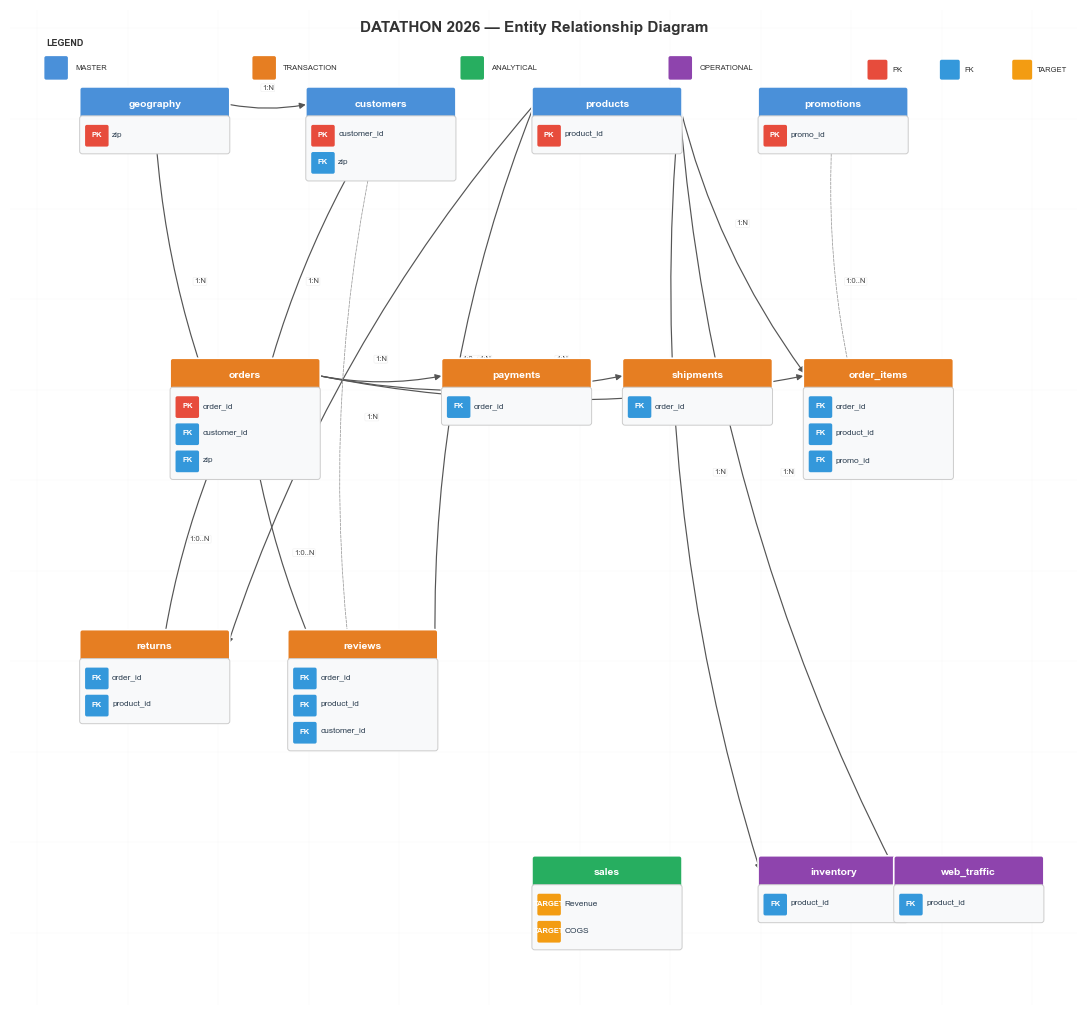

In [40]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np

# ── Cấu hình bảng (chỉ PK + FK) ────────────────────────────────────────────────
# Layout: MASTER layer trên cùng, TRANSACTION ở giữa, ANALYTICAL & OPERATIONAL dưới

TABLES = {
    # Row 1: MASTER tables (top)
    "geography": {"pos": (0.5, 9.0), "color": "#4A90D9", "cols": [("zip", "PK")]},
    "customers": {"pos": (3.0, 9.0), "color": "#4A90D9", "cols": [("customer_id", "PK"), ("zip", "FK")]},
    "products": {"pos": (5.5, 9.0), "color": "#4A90D9", "cols": [("product_id", "PK")]},
    "promotions": {"pos": (8.0, 9.0), "color": "#4A90D9", "cols": [("promo_id", "PK")]},
    
    # Row 2: TRANSACTION tables (middle)
    "orders": {"pos": (1.5, 6.0), "color": "#E67E22", "cols": [("order_id", "PK"), ("customer_id", "FK"), ("zip", "FK")]},
    "payments": {"pos": (4.5, 6.0), "color": "#E67E22", "cols": [("order_id", "FK")]},
    "shipments": {"pos": (6.5, 6.0), "color": "#E67E22", "cols": [("order_id", "FK")]},
    "order_items": {"pos": (8.5, 6.0), "color": "#E67E22", "cols": [("order_id", "FK"), ("product_id", "FK"), ("promo_id", "FK")]},
    
    # Row 3: TRANSACTION detail & dependent tables (below)
    "returns": {"pos": (0.5, 3.0), "color": "#E67E22", "cols": [("order_id", "FK"), ("product_id", "FK")]},
    "reviews": {"pos": (2.8, 3.0), "color": "#E67E22", "cols": [("order_id", "FK"), ("product_id", "FK"), ("customer_id", "FK")]},
    
    # Row 4: ANALYTICAL & OPERATIONAL (bottom)
    "sales": {"pos": (5.5, 0.5), "color": "#27AE60", "cols": [("Revenue", "TARGET"), ("COGS", "TARGET")]},
    "inventory": {"pos": (8.0, 0.5), "color": "#8E44AD", "cols": [("product_id", "FK")]},
    "web_traffic": {"pos": (9.5, 0.5), "color": "#8E44AD", "cols": [("product_id", "FK")]},
}

# ── Quan hệ (from_table, to_table, label, style) ─────────────────────────────
RELATIONSHIPS = [
    ("geography", "customers", "1:N", "solid"),
    ("geography", "orders", "1:N", "solid"),
    ("customers", "orders", "1:N", "solid"),
    ("orders", "payments", "1:1", "solid"),
    ("orders", "shipments", "1:0..1", "solid"),
    ("orders", "returns", "1:0..N", "solid"),
    ("orders", "reviews", "1:0..N", "solid"),
    ("orders", "order_items", "1:N", "solid"),
    ("products", "order_items", "1:N", "solid"),
    ("promotions", "order_items", "1:0..N", "dashed"),
    ("products", "inventory", "1:N", "solid"),
    ("products", "returns", "1:N", "solid"),
    ("products", "reviews", "1:N", "solid"),
    ("products", "web_traffic", "1:N", "solid"),
    ("customers", "reviews", "1:N", "dashed"),
]

# ── Hàm vẽ bảng ────────────────────────────────────────────────────────────────
def draw_table(ax, name, config, col_h=0.30, header_h=0.32, pad=0.06, width=1.6):
    x, y = config["pos"]
    cols = config["cols"]
    color = config["color"]
    n = len(cols)

    # Header box
    header = FancyBboxPatch(
        (x, y), width, header_h,
        boxstyle="round,pad=0.03",
        linewidth=1.2, edgecolor="white",
        facecolor=color, zorder=3
    )
    ax.add_patch(header)
    ax.text(x + width / 2, y + header_h / 2, name,
            ha="center", va="center", fontsize=7.5, fontweight="bold",
            color="white", zorder=4)

    # Body box
    body_y = y - n * col_h - pad
    body = FancyBboxPatch(
        (x, body_y), width, n * col_h + pad,
        boxstyle="round,pad=0.03",
        linewidth=0.7, edgecolor="#CCCCCC",
        facecolor="#F8F9FA", zorder=3
    )
    ax.add_patch(body)

    # Columns
    for i, (col_name, role) in enumerate(cols):
        cy = y - (i + 0.5) * col_h - pad / 2
        role_color = {"PK": "#E74C3C", "FK": "#3498DB", "TARGET": "#F39C12"}.get(role, None)
        
        if role_color:
            badge = FancyBboxPatch(
                (x + 0.05, cy - 0.11), 0.22, 0.20,
                boxstyle="round,pad=0.02",
                linewidth=0, facecolor=role_color, zorder=4
            )
            ax.add_patch(badge)
            ax.text(x + 0.16, cy, role, ha="center", va="center", fontsize=5.5,
                    fontweight="bold", color="white", zorder=5)
            ax.text(x + 0.33, cy, col_name, ha="left", va="center", fontsize=6,
                    color="#2C3E50", zorder=4)


def get_table_bounds(name):
    cfg = TABLES[name]
    x, y = cfg["pos"]
    w = 1.6
    n = len(cfg["cols"])
    col_h, header_h, pad = 0.30, 0.32, 0.06
    return (x + w / 2, y + header_h / 2, x, y, x + w, y - (n * col_h + pad))


def get_edge_points(src, dst):
    sx, sy, slx, sty, srx, sby = get_table_bounds(src)
    dx, dy, dlx, dty, drx, dby = get_table_bounds(dst)

    if srx <= dlx:
        return (srx, sy), (dlx, dy)
    elif slx >= drx:
        return (slx, sy), (drx, dy)
    elif sty >= dby:
        return (sx, sty), (dx, dby)
    else:
        return (sx, sby), (dx, dty)


# ── Main plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(-0.3, 11.5)
ax.set_ylim(-0.8, 10.2)
ax.set_aspect("equal")
ax.axis("off")

# Background
ax.add_patch(plt.Rectangle((-0.3, -0.8), 12, 11, color="#FFFFFF", zorder=0))

# Light grid
for x in np.arange(0, 12, 1):
    ax.axvline(x, color="#f5f5f5", linewidth=0.2, zorder=1)
for y in np.arange(0, 11, 1):
    ax.axhline(y, color="#f5f5f5", linewidth=0.2, zorder=1)

# Draw relationships
for src, dst, label, style in RELATIONSHIPS:
    try:
        p1, p2 = get_edge_points(src, dst)
        ls = "--" if style == "dashed" else "-"
        color_line = "#999999" if style == "dashed" else "#555555"
        ax.annotate("", xy=p2, xytext=p1,
            arrowprops=dict(
                arrowstyle="-|>",
                color=color_line,
                lw=0.85 if style == "solid" else 0.55,
                linestyle=ls,
                connectionstyle="arc3,rad=0.10",
                mutation_scale=9,
            ),
            zorder=2
        )
        mx, my = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
        ax.text(mx, my + 0.18, label, ha="center", va="center",
                fontsize=5.5, color="#444444",
                bbox=dict(boxstyle="round,pad=0.12", facecolor="#FFFFFF",
                          edgecolor="#EEEEEE", alpha=0.95, linewidth=0.4),
                zorder=2)
    except Exception:
        pass

# Draw tables
for name, config in TABLES.items():
    draw_table(ax, name, config)

# ── Legend ────────────────────────────────────────────────────────────────────
ax.text(0.1, 9.8, "LEGEND", fontsize=6.5, color="#333333", fontweight="bold")

# Layer legend
layers = [("MASTER", "#4A90D9"), ("TRANSACTION", "#E67E22"), ("ANALYTICAL", "#27AE60"), ("OPERATIONAL", "#8E44AD")]
for i, (lbl, lc) in enumerate(layers):
    px = 0.1 + i * 2.3
    ax.add_patch(FancyBboxPatch((px, 9.45), 0.22, 0.22, boxstyle="round,pad=0.02",
                                facecolor=lc, edgecolor="none", zorder=5))
    ax.text(px + 0.32, 9.56, lbl, ha="left", va="center", fontsize=5.5, color="#333333", zorder=6)

# Role legend
roles = [("PK", "#E74C3C"), ("FK", "#3498DB"), ("TARGET", "#F39C12")]
for i, (lbl, lc) in enumerate(roles):
    px = 9.2 + i * 0.8
    ax.add_patch(FancyBboxPatch((px, 9.45), 0.18, 0.18, boxstyle="round,pad=0.02",
                                facecolor=lc, edgecolor="none", zorder=5))
    ax.text(px + 0.25, 9.54, lbl, ha="left", va="center", fontsize=5.5, color="#333333", zorder=6)

# Title
ax.text(5.5, 10.0, "DATATHON 2026 — Entity Relationship Diagram", ha="center", va="center",
        fontsize=11, fontweight="bold", color="#333333")

plt.tight_layout(pad=0.1)
plt.show()



Sau khi dữ liệu đã được làm sạch và chuẩn hóa, chúng ta sẽ bắt đầu phân tích bức tranh toàn cảnh về tình hình kinh doanh của doanh nghiệp trong giai đoạn 2012–2022.

### 4. Bức tranh tổng quan

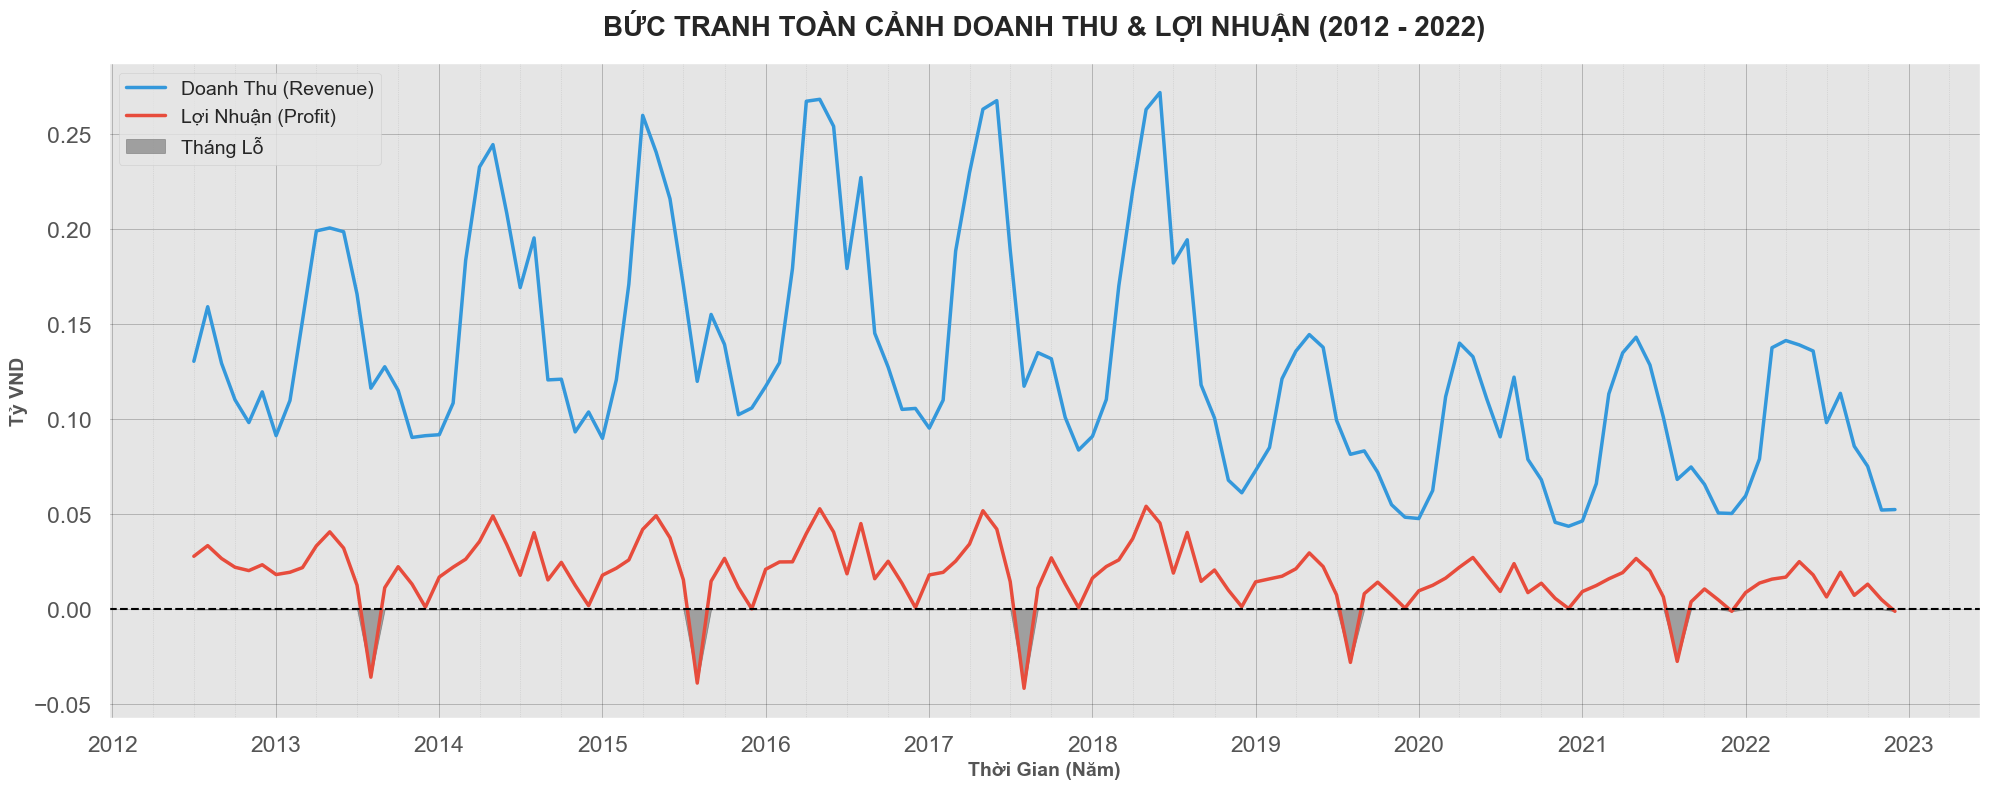


=== DOANH THU TRUNG BÌNH THEO NĂM ===
    Year       Revenue
0   2012  1.235830e+08
1   2013  1.380975e+08
2   2014  1.559872e+08
3   2015  1.574945e+08
4   2016  1.753867e+08
5   2017  1.592637e+08
6   2018  1.541769e+08
7   2019  9.473345e+07
8   2020  8.787601e+07
9   2021  8.691998e+07
10  2022  9.747907e+07

=== LỢI NHUẬN TRUNG BÌNH THEO NĂM ===
    Year        Profit
0   2012  2.567264e+07
1   2013  1.593244e+07
2   2014  2.476987e+07
3   2015  1.870767e+07
4   2016  2.700677e+07
5   2017  1.806488e+07
6   2018  2.566222e+07
7   2019  1.096655e+07
8   2020  1.403559e+07
9   2021  8.492475e+06
10  2022  1.244406e+07

BIỀU ĐỒ & BẢNG BIÊN LỢI NHUẬN THEO NĂM (PROFIT MARGIN)

Bảng Biên Lợi Nhuận Theo Năm:
 Year      Revenue       Profit  Profit_Margin_%
 2012 7.414977e+08 154035824.21            20.77
 2013 1.657169e+09 191189314.07            11.54
 2014 1.871846e+09 297238425.91            15.88
 2015 1.889934e+09 224492009.50            11.88
 2016 2.104641e+09 324081284.85       

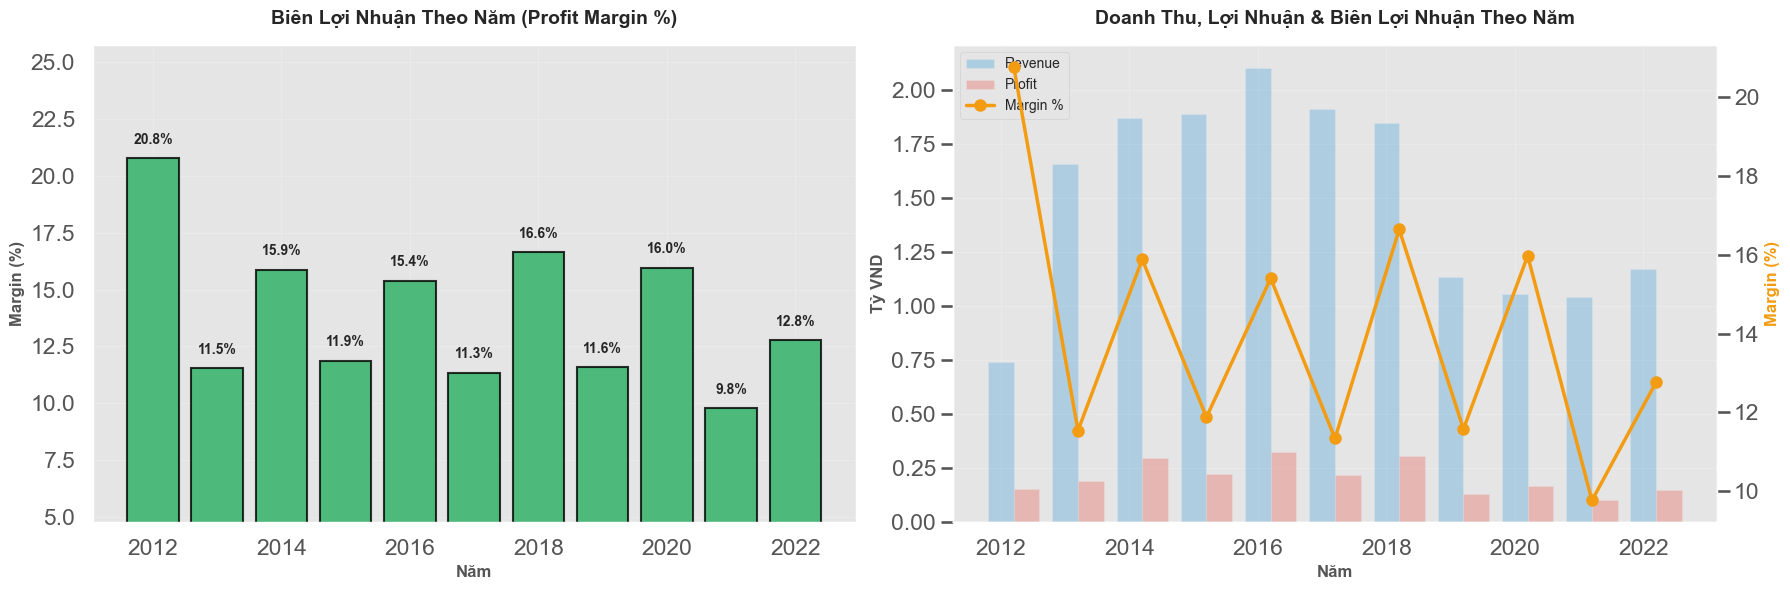


BẢNG TÓM TẮT BIÊN LỢI NHUẬN THEO NĂM (CHI TIẾT)
 Năm  Doanh Thu (Tỷ VND)  Lợi Nhuận (Tỷ VND)  Biên LN (%)
2012                0.74                0.15        20.77
2013                1.66                0.19        11.54
2014                1.87                0.30        15.88
2015                1.89                0.22        11.88
2016                2.10                0.32        15.40
2017                1.91                0.22        11.34
2018                1.85                0.31        16.64
2019                1.14                0.13        11.58
2020                1.05                0.17        15.97
2021                1.04                0.10         9.77
2022                1.17                0.15        12.77


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sales['YearMonth'] = sales['Date'].dt.to_period('M').dt.to_timestamp()
sales['Profit'] = sales['Revenue'] - sales['COGS']

monthly_sales = sales.groupby('YearMonth')[['Revenue', 'Profit']].sum().reset_index()

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(20, 8))

# Vẽ Line Doanh Thu
ax.plot(monthly_sales['YearMonth'], monthly_sales['Revenue'] / 1e9,
        color='#3498db', linewidth=2.5, label='Doanh Thu (Revenue)')

# Vẽ Line Lợi Nhuận
ax.plot(monthly_sales['YearMonth'], monthly_sales['Profit'] / 1e9,
        color='#e74c3c', linewidth=2.5, label='Lợi Nhuận (Profit)')

# ===== FIX vùng lỗ =====
profit = monthly_sales['Profit'] / 1e9
profit_negative = profit.copy()
profit_negative[profit >= 0] = 0

ax.fill_between(
    monthly_sales['YearMonth'],
    0,
    profit_negative,
    color='black',
    alpha=0.3,
    label='Tháng Lỗ'
)
# =====================

# Đường baseline 0
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

ax.set_title('BỨC TRANH TOÀN CẢNH DOANH THU & LỢI NHUẬN (2012 - 2022)', fontsize=20, fontweight='bold', pad=20)
ax.set_ylabel('Tỷ VND', fontsize=14, fontweight='bold')
ax.set_xlabel('Thời Gian (Năm)', fontsize=14, fontweight='bold')

# Format trục X hiển thị từng năm
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

# Grid
ax.grid(True, which='major', linestyle='-', linewidth='0.5', color='black', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', linewidth='0.5', color='gray', alpha=0.3)

ax.legend(fontsize=14, loc='upper left')

plt.tight_layout()
plt.show()

# ===== THÊM PHẦN NÀY =====
# Tạo cột Year
monthly_sales['Year'] = monthly_sales['YearMonth'].dt.year

# Doanh thu trung bình theo năm
avg_revenue_year = monthly_sales.groupby('Year')['Revenue'].mean().reset_index()

# Lợi nhuận trung bình theo năm
avg_profit_year = monthly_sales.groupby('Year')['Profit'].mean().reset_index()

print("\n=== DOANH THU TRUNG BÌNH THEO NĂM ===")
print(avg_revenue_year)

print("\n=== LỢI NHUẬN TRUNG BÌNH THEO NĂM ===")
print(avg_profit_year)

# ===== PHẦN MỚI: BIỂU ĐỒ MARGIN LỢI NHUẬN THEO NĂM =====
print("\n" + "="*80)
print("BIỀU ĐỒ & BẢNG BIÊN LỢI NHUẬN THEO NĂM (PROFIT MARGIN)")
print("="*80)

# Tính toàn bộ revenue & profit theo năm
yearly_data = monthly_sales.groupby('Year')[['Revenue', 'Profit']].sum().reset_index()
yearly_data['Profit_Margin_%'] = (yearly_data['Profit'] / yearly_data['Revenue'] * 100).round(2)

print("\nBảng Biên Lợi Nhuận Theo Năm:")
print(yearly_data.to_string(index=False))

# Vẽ biểu đồ Profit Margin theo năm
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1: Cột biểu đồ margin theo năm
colors_margin = ['#27ae60' if m > 0 else '#e74c3c' for m in yearly_data['Profit_Margin_%']]
ax1.bar(yearly_data['Year'], yearly_data['Profit_Margin_%'], color=colors_margin, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax1.set_title('Biên Lợi Nhuận Theo Năm (Profit Margin %)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Năm', fontsize=12, fontweight='bold')
ax1.set_ylabel('Margin (%)', fontsize=12, fontweight='bold')
ax1.grid(True, which='major', linestyle='-', linewidth='0.5', alpha=0.3)
ax1.set_ylim(min(yearly_data['Profit_Margin_%']) - 5, max(yearly_data['Profit_Margin_%']) + 5)

# Thêm số % trên cột
for i, (year, margin) in enumerate(zip(yearly_data['Year'], yearly_data['Profit_Margin_%'])):
    ax1.text(year, margin + (0.5 if margin > 0 else -1.5), f'{margin:.1f}%', 
             ha='center', va='bottom' if margin > 0 else 'top', fontweight='bold', fontsize=10)

# Chart 2: Line chart revenue vs profit vs margin (dual axis)
ax2_twin = ax2.twinx()

ax2.bar(yearly_data['Year'], yearly_data['Revenue'] / 1e9, alpha=0.3, color='#3498db', label='Revenue', width=0.4)
ax2.bar(yearly_data['Year'] + 0.4, yearly_data['Profit'] / 1e9, alpha=0.3, color='#e74c3c', label='Profit', width=0.4)
ax2_twin.plot(yearly_data['Year'] + 0.2, yearly_data['Profit_Margin_%'], color='#f39c12', marker='o', 
              linewidth=2.5, markersize=8, label='Margin %', zorder=5)

ax2.set_title('Doanh Thu, Lợi Nhuận & Biên Lợi Nhuận Theo Năm', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Năm', fontsize=12, fontweight='bold')
ax2.set_ylabel('Tỷ VND', fontsize=12, fontweight='bold', color='#555')
ax2_twin.set_ylabel('Margin (%)', fontsize=12, fontweight='bold', color='#f39c12')
ax2.grid(True, which='major', linestyle='-', linewidth='0.5', alpha=0.3)
ax2_twin.grid(False)

# Legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# Hiển thị bảng tóm tắt chi tiết
print("\n" + "="*80)
print("BẢNG TÓM TẮT BIÊN LỢI NHUẬN THEO NĂM (CHI TIẾT)")
print("="*80)
summary_table = yearly_data[['Year', 'Revenue', 'Profit', 'Profit_Margin_%']].copy()
summary_table['Revenue'] = (summary_table['Revenue'] / 1e9).round(2)
summary_table['Profit'] = (summary_table['Profit'] / 1e9).round(2)
summary_table.columns = ['Năm', 'Doanh Thu (Tỷ VND)', 'Lợi Nhuận (Tỷ VND)', 'Biên LN (%)']
print(summary_table.to_string(index=False))


TĂNG TRƯỞNG DOANH THU & LỢI NHUẬN QUA TỪNG NĂM


,Năm,Doanh Thu (Tỷ VND),COGS (Tỷ VND),Lợi Nhuận (Tỷ VND),Tăng trưởng DT (%),Tăng trưởng LN (%)
0,2012,0.74,5.874619e+08,0.15,NaN,NaN
1,2013,1.66,1.465980e+09,0.19,123.49,24.12
2,2014,1.87,1.574607e+09,0.30,12.95,55.47
3,2015,1.89,1.665442e+09,0.22,0.97,-24.47
4,2016,2.10,1.780559e+09,0.32,11.36,44.36
5,2017,1.91,1.694386e+09,0.22,-9.19,-33.11
6,2018,1.85,1.542176e+09,0.31,-3.19,42.06
7,2019,1.14,1.005203e+09,0.13,-38.56,-57.27
8,2020,1.05,8.860851e+08,0.17,-7.24,27.99
9,2021,1.04,9.411301e+08,0.10,-1.09,-39.49


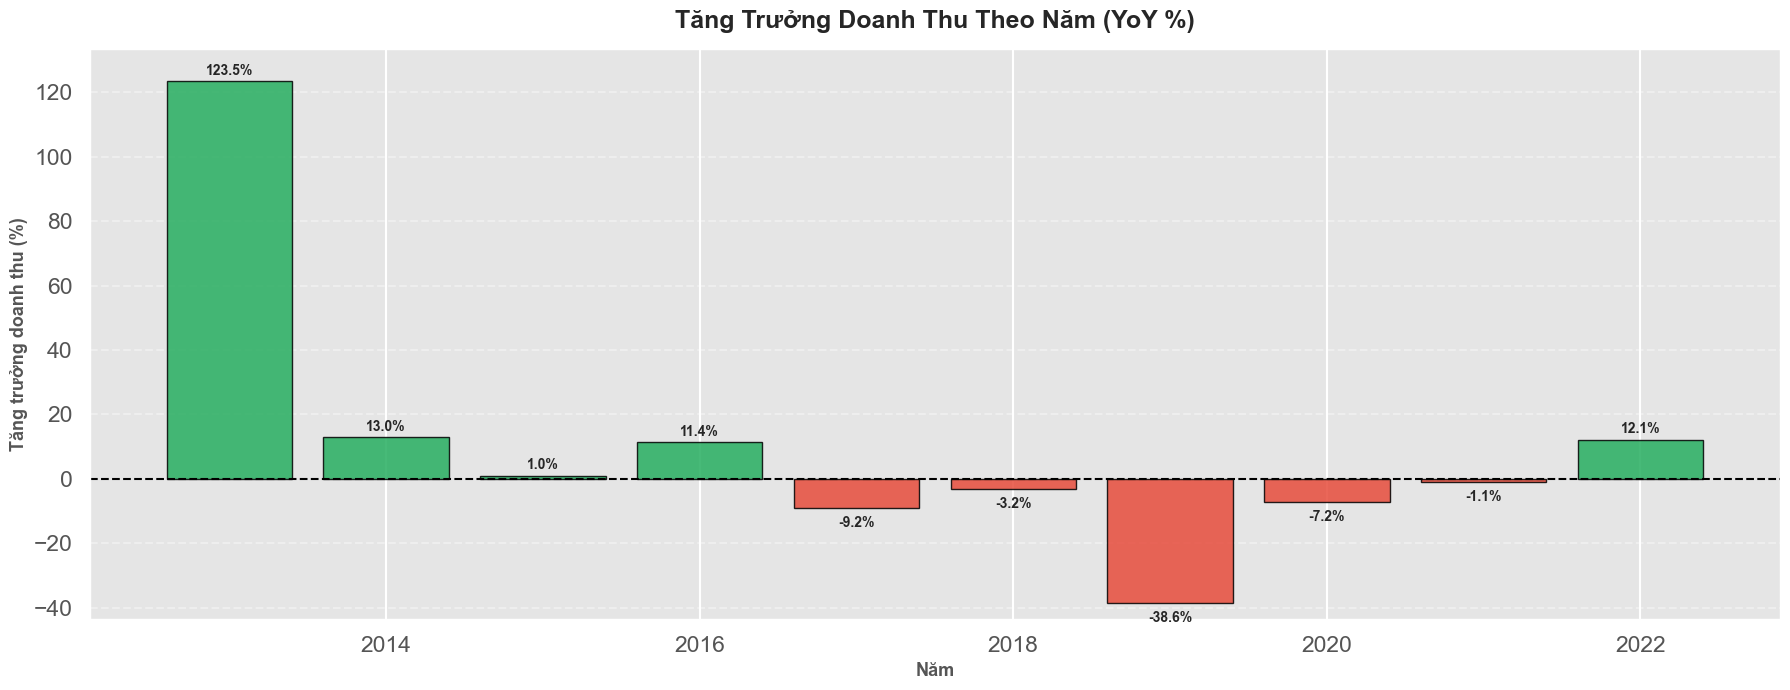

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use('ggplot')

yearly_growth = sales.copy()
yearly_growth['Year'] = yearly_growth['Date'].dt.year
growth_summary = yearly_growth.groupby('Year')[['Revenue', 'COGS']].sum().reset_index()
growth_summary['Profit'] = growth_summary['Revenue'] - growth_summary['COGS']
growth_summary['Revenue_Growth_%'] = growth_summary['Revenue'].pct_change() * 100
growth_summary['Profit_Growth_%'] = growth_summary['Profit'].pct_change() * 100

print('=' * 80)
print('TĂNG TRƯỞNG DOANH THU & LỢI NHUẬN QUA TỪNG NĂM')
print('=' * 80)

display_table = growth_summary.copy()
display_table['Revenue'] = display_table['Revenue'].div(1e9).round(2)
display_table['Profit'] = display_table['Profit'].div(1e9).round(2)
display_table['Revenue_Growth_%'] = display_table['Revenue_Growth_%'].round(2)
display_table['Profit_Growth_%'] = display_table['Profit_Growth_%'].round(2)
display_table.columns = ['Năm', 'Doanh Thu (Tỷ VND)', 'COGS (Tỷ VND)', 'Lợi Nhuận (Tỷ VND)', 'Tăng trưởng DT (%)', 'Tăng trưởng LN (%)']
display(display_table)

fig, ax = plt.subplots(figsize=(18, 7))
bar_colors = ['#95a5a6' if pd.isna(value) else ('#27ae60' if value >= 0 else '#e74c3c') for value in growth_summary['Revenue_Growth_%']]
bars = ax.bar(
    growth_summary['Year'],
    growth_summary['Revenue_Growth_%'],
    color=bar_colors,
    alpha=0.85,
    edgecolor='black',
    linewidth=1,
)
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_title('Tăng Trưởng Doanh Thu Theo Năm (YoY %)', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Năm', fontsize=13, fontweight='bold')
ax.set_ylabel('Tăng trưởng doanh thu (%)', fontsize=13, fontweight='bold')
ax.grid(True, axis='y', linestyle='--', alpha=0.35)
ax.set_ylim(
    min(-20, np.nanmin(growth_summary['Revenue_Growth_%']) - 5),
    np.nanmax(growth_summary['Revenue_Growth_%']) + 10,
)

for bar, value in zip(bars, growth_summary['Revenue_Growth_%']):
    if pd.notna(value):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + (1 if value >= 0 else -2.5),
            f'{value:.1f}%',
            ha='center',
            va='bottom' if value >= 0 else 'top',
            fontweight='bold',
            fontsize=10,
        )

plt.tight_layout()
plt.show()



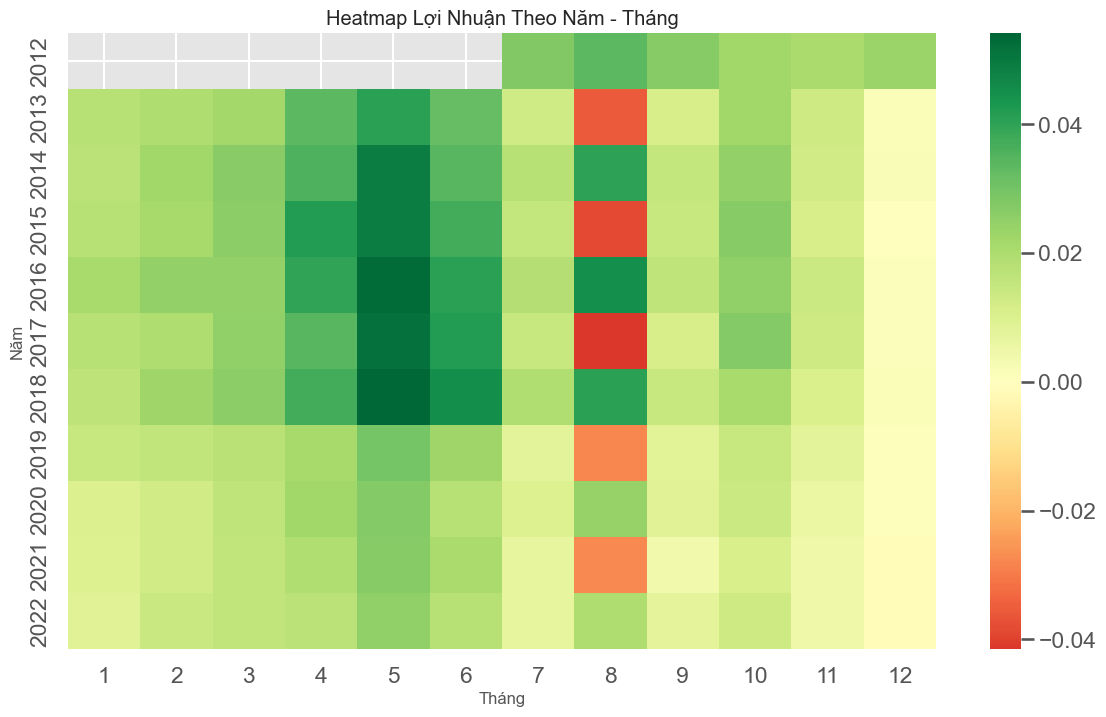

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sales['Year'] = sales['Date'].dt.year
sales['Month'] = sales['Date'].dt.month

monthly_profit = sales.groupby(['Year', 'Month'])['Profit'].sum().reset_index()

pivot_table = monthly_profit.pivot(index='Year', columns='Month', values='Profit')

plt.figure(figsize=(14,8))
sns.heatmap(pivot_table / 1e9, cmap='RdYlGn', center=0, annot=False)

plt.title('Heatmap Lợi Nhuận Theo Năm - Tháng')
plt.xlabel('Tháng')
plt.ylabel('Năm')

plt.show()

📊 1. Tổng quan xu hướng doanh thu và lợi nhuận

Trong giai đoạn 2012–2016, doanh nghiệp ghi nhận sự tăng trưởng mạnh mẽ và tương đối ổn định về quy mô. Doanh thu tăng liên tục qua các năm, với mức tăng trưởng nổi bật năm 2013 (+123.49%) và duy trì đà tăng tích cực ở các năm tiếp theo (dao động khoảng 11–13%). Lợi nhuận cũng tăng trưởng đáng kể, đặc biệt năm 2014 (+55.47%) và 2016 (+44.36%), cho thấy doanh nghiệp không chỉ mở rộng quy mô mà còn duy trì hiệu quả hoạt động tốt.

Tuy nhiên, từ năm 2017 đến 2018, tăng trưởng bắt đầu chững lại. Doanh thu ghi nhận mức tăng trưởng âm liên tiếp (-9.19% năm 2017 và -3.19% năm 2018), phản ánh dấu hiệu suy giảm về quy mô. Dù vậy, lợi nhuận lại có sự phục hồi đáng kể trong năm 2018 (+42.06%), cho thấy doanh nghiệp có thể đã thực hiện các biện pháp tối ưu chi phí hoặc điều chỉnh cơ cấu sản phẩm nhằm duy trì hiệu quả trong bối cảnh tăng trưởng doanh thu chậm lại.

Bước ngoặt quan trọng xảy ra vào năm 2019, khi doanh thu giảm mạnh -38.56% so với năm trước, đồng thời lợi nhuận cũng giảm sâu -57.27%. Đây là mức sụt giảm lớn nhất trong toàn bộ giai đoạn nghiên cứu, đánh dấu một điểm đứt gãy rõ rệt trong xu hướng tăng trưởng. Mặc dù lợi nhuận giảm mạnh hơn doanh thu, nhưng xét trong bối cảnh dài hạn, đây không phải là hệ quả của việc chi phí tăng đột biến mà nhiều khả năng phản ánh sự suy giảm nghiêm trọng về nhu cầu.

Trong giai đoạn 2020–2021, doanh nghiệp không ghi nhận sự phục hồi rõ rệt. Doanh thu tiếp tục giảm nhẹ (-7.24% năm 2020 và -1.09% năm 2021), cho thấy trạng thái đi ngang ở mức thấp. Lợi nhuận biến động không ổn định, với mức tăng tạm thời năm 2020 (+27.99%) nhưng sau đó giảm mạnh năm 2021 (-39.49%). Điều này phản ánh trạng thái “đóng băng” sau cú sốc năm 2019, khi doanh nghiệp chưa thể khôi phục lại động lực tăng trưởng.

Đến năm 2022, xuất hiện tín hiệu phục hồi khi doanh thu tăng trở lại +12.15% và lợi nhuận tăng +46.53%. Tuy nhiên, mức phục hồi này vẫn chưa đủ để đưa doanh nghiệp quay về quy mô trước năm 2019, cho thấy quá trình hồi phục còn yếu và chưa bền vững.

💰 2. Phân tích biên lợi nhuận

Xét về biên lợi nhuận, dữ liệu cho thấy chỉ số này dao động trong khoảng tương đối ổn định (khoảng 11%–16%) trong suốt giai đoạn nghiên cứu, không xuất hiện xu hướng suy giảm kéo dài. Điều này cho thấy doanh nghiệp không gặp phải vấn đề nghiêm trọng liên quan đến cấu trúc chi phí hay hiệu quả vận hành dài hạn.

Đáng chú ý, trong năm 2019 – thời điểm doanh thu giảm mạnh – biên lợi nhuận vẫn được duy trì ở mức tương đương các năm trước. Điều này củng cố nhận định rằng sự sụt giảm doanh thu không xuất phát từ việc chi phí tăng đột biến hay hoạt động kinh doanh kém hiệu quả.

Ngoài ra, biên lợi nhuận còn thể hiện một dạng biến động theo chu kỳ (cao – thấp xen kẽ giữa các năm), không phải là ngẫu nhiên mà có thể được giải thích bởi các hoạt động kinh doanh cụ thể. Phân tích chi tiết theo thời gian cho thấy, trong suốt giai đoạn nghiên cứu, doanh nghiệp duy trì một chu kỳ xả lỗ định kỳ 2 năm, tập trung vào tháng 8 của các năm lẻ (2013, 2015, 2017, 2019, 2021).

Trong các thời điểm này, lợi nhuận ghi nhận mức âm sâu, nguyên nhân được xác định từ bảng promotions là do chiến dịch “Urban Blowout” với mức giảm giá lên đến 50%. Đây là chiến lược bán hàng dưới giá vốn nhằm giải phóng tồn kho và chuẩn bị cho đợt ra mắt sản phẩm mới vào mùa thu (Fall Launch). Ngược lại, trong các năm chẵn, doanh nghiệp không triển khai chiến dịch này và duy trì bán hàng ở mức giá thông thường, dẫn đến biên lợi nhuận cao hơn.

Do đó, biến động biên lợi nhuận theo chu kỳ phản ánh một chiến lược vận hành có chủ đích, thay vì dấu hiệu của sự bất ổn trong chi phí hay hiệu quả kinh doanh.

🧠 3. Kết luận sơ bộ

Từ các phân tích về quy mô, tăng trưởng và biên lợi nhuận, có thể rút ra một nhận định quan trọng:

Mặc dù doanh thu sụt giảm mạnh từ năm 2019, biên lợi nhuận của doanh nghiệp không suy giảm tương ứng mà vẫn duy trì ổn định. Đồng thời, xu hướng tăng trưởng doanh thu đã có dấu hiệu suy yếu từ trước đó (2017–2018). Điều này cho thấy nguyên nhân cốt lõi của sự đứt gãy không nằm ở chi phí, mà nhiều khả năng đến từ sự suy giảm nhu cầu tích tụ trong thời gian dài và bùng phát vào năm 2019.

Nói cách khác, vấn đề không phải là “bán không có lời”, mà là “không còn bán được như trước”.

🔍 4. Định hướng phân tích tiếp theo

Dựa trên các dấu hiệu về sự suy giảm tăng trưởng và đứt gãy nhu cầu, các phân tích tiếp theo sẽ tập trung kiểm tra các giả thuyết sau:

- Sự suy giảm về chất lượng dịch vụ
- Sự thay đổi trong số lượng khách hàng (mất khách cũ hoặc suy giảm khách hàng mới)
- Sự suy giảm về sản lượng bán ra (giảm số lượng đơn hàng hoặc số lượng sản phẩm trên mỗi đơn)
- Biến động trong danh mục sản phẩm, đặc biệt là sự suy giảm của các sản phẩm chủ lực mà không có sản phẩm thay thế tương ứng
- Thay đổi trong chiến lược giá, bao gồm mức giá trung bình và tần suất khuyến mãi
- Sự suy giảm hiệu quả chuyển đổi (conversion rate), khi lưu lượng truy cập không chuyển hóa thành doanh thu

Bên cạnh đó, một số yếu tố bổ sung cũng cần được xem xét nhằm có cái nhìn toàn diện hơn:

- Hiệu quả của phễu bán hàng (sales funnel), đặc biệt là các điểm rơi giữa các bước như từ xem sản phẩm đến thanh toán
- Tỷ lệ khách hàng quay lại (retention rate), nhằm đánh giá mức độ gắn kết và trung thành của khách hàng
- Giá trị đơn hàng trung bình (Average Order Value - AOV), để xác định liệu khách hàng có xu hướng chi tiêu ít hơn
- Tình trạng tồn kho và vòng quay hàng hóa, có thể ảnh hưởng đến khả năng cung ứng và chiến lược bán hàng
- Tác động từ các chiến dịch marketing và khuyến mãi, bao gồm cả hiệu quả ngắn hạn và ảnh hưởng dài hạn đến hành vi mua hàng

Các giả thuyết trên sẽ được kiểm chứng thông qua phân tích dữ liệu chi tiết trong các phần tiếp theo, nhằm xác định nguyên nhân cốt lõi dẫn đến sự sụt giảm doanh thu từ năm 2019.

Các giả thuyết này sẽ được kiểm chứng bằng dữ liệu chi tiết nhằm xác định nguyên nhân chính gây ra sự sụt giảm doanh thu từ năm 2019.

### 5. Phân tích nguyên nhân

Từ các định hướng phân tích đã đề ra, có thể thấy sự sụt giảm doanh thu từ năm 2019 nhiều khả năng không đến từ một yếu tố đơn lẻ, mà là kết quả của nhiều biến động xảy ra đồng thời trong hành vi khách hàng, hiệu quả chuyển đổi và cơ cấu sản phẩm.

Để xác định nguyên nhân cốt lõi, phần này sẽ tiến hành kiểm chứng lần lượt các giả thuyết đã nêu thông qua phân tích dữ liệu chi tiết. Cụ thể, phân tích sẽ tập trung vào các nhóm yếu tố:

- Chất lượng dịch vụ (Service): đánh giá sự ổn định của trải nghiệm khách hàng thông qua thời gian giao hàng, đánh giá (rating) và tỷ lệ hủy đơn
- Khách hàng (Customer): đánh giá sự thay đổi về số lượng khách hàng, tỷ lệ quay lại và mức độ gắn kết
- Hiệu quả bán hàng (Conversion & Demand): phân tích sự chuyển đổi từ nhu cầu sang doanh thu, bao gồm lưu lượng truy cập, tỷ lệ chuyển đổi và sản lượng bán
- Danh mục sản phẩm (Product Mix): xác định vai trò của các sản phẩm chủ lực và sự thay đổi trong cơ cấu doanh thu

Thông qua việc kiểm tra từng nhóm yếu tố này, mục tiêu là làm rõ liệu sự sụt giảm doanh thu có xuất phát từ việc mất khách hàng, giảm hiệu quả chuyển đổi, hay sự suy yếu của danh mục sản phẩm — hoặc là sự kết hợp của nhiều yếu tố cùng lúc.

#### 5.1 Phân tích chất lượng dịch vụ (Service)


Đầu tiên, chúng ta tiến hành đánh giá chất lượng dịch vụ nhằm xác định liệu các yếu tố vận hành và trải nghiệm khách hàng có phải là nguyên nhân dẫn đến sự sụt giảm doanh thu hay không.

THỜI GIAN GIAO HÀNG TRUNG BÌNH (NGÀY) - ĐƯỜNG LIÊN TỤC THEO THỜI GIAN
    year  month month_name  shipping_days
0   2012      7        Jul       4.464761
1   2012      8        Aug       4.504463
2   2012      9        Sep       4.491126
3   2012     10        Oct       4.511738
4   2012     11        Nov       4.488307
5   2012     12        Dec       4.575166
6   2013      1        Jan       4.543160
7   2013      2        Feb       4.542506
8   2013      3        Mar       4.485447
9   2013      4        Apr       4.501355
10  2013      5        May       4.502050
11  2013      6        Jun       4.518834
12  2013      7        Jul       4.488046
13  2013      8        Aug       4.477355
14  2013      9        Sep       4.479567
15  2013     10        Oct       4.498181
16  2013     11        Nov       4.527155
17  2013     12        Dec       4.529482
18  2014      1        Jan       4.486191
19  2014      2        Feb       4.432659

Tổng số điểm dữ liệu: 126



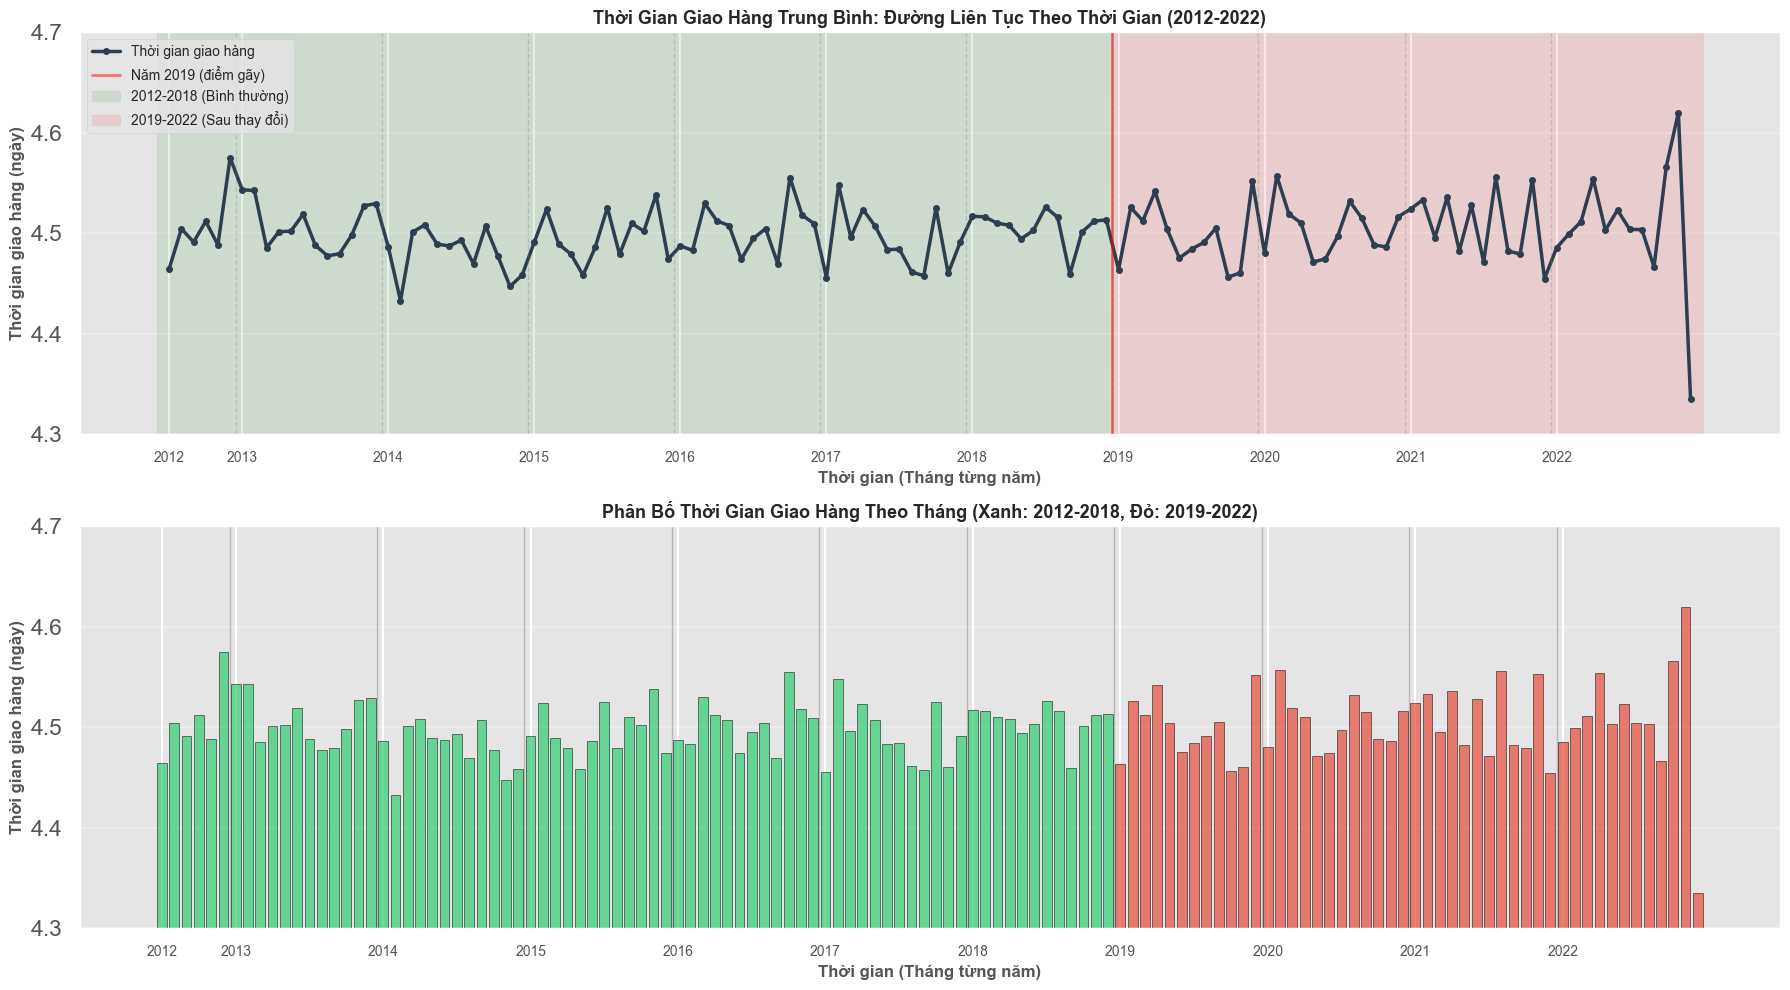

In [36]:
# Phân tích thời gian giao hàng: một đường liên tục theo thời gian (12 tháng × 10 năm)
ship_merged = shipments.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
ship_merged['year'] = ship_merged['order_date'].dt.year
ship_merged['month'] = ship_merged['order_date'].dt.month
ship_merged['month_name'] = ship_merged['order_date'].dt.strftime('%b')
ship_merged['shipping_days'] = (ship_merged['delivery_date'] - ship_merged['ship_date']).dt.days

# Calculate average shipping days by month and year
shipping_by_month_year = ship_merged.groupby(['year', 'month', 'month_name'])['shipping_days'].agg('mean').reset_index()
shipping_by_month_year = shipping_by_month_year.sort_values(['year', 'month'])

# Create a continuous time sequence label for each month
shipping_by_month_year['time_index'] = range(len(shipping_by_month_year))
shipping_by_month_year['time_label'] = shipping_by_month_year['month_name'] + '\n' + shipping_by_month_year['year'].astype(str)

print("THỜI GIAN GIAO HÀNG TRUNG BÌNH (NGÀY) - ĐƯỜNG LIÊN TỤC THEO THỜI GIAN")
print(shipping_by_month_year[['year', 'month', 'month_name', 'shipping_days']].head(20))
print(f"\nTổng số điểm dữ liệu: {len(shipping_by_month_year)}")
print()

# Create visualization: Single continuous line over time
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Plot 1: Main line chart - continuous timeline with monthly granularity
ax1 = axes[0]
ax1.plot(shipping_by_month_year['time_index'], shipping_by_month_year['shipping_days'], 
         color='#2c3e50', linewidth=2.5, marker='o', markersize=4, label='Thời gian giao hàng')

# Add vertical lines to mark year boundaries
years_unique = shipping_by_month_year['year'].unique()
for year in years_unique[1:]:  # Skip first year
    year_start_idx = shipping_by_month_year[shipping_by_month_year['year'] == year]['time_index'].iloc[0]
    ax1.axvline(x=year_start_idx - 0.5, color='gray', linestyle='--', alpha=0.3, linewidth=1)

# Add 2019 breakpoint line in red
year_2019_start = shipping_by_month_year[shipping_by_month_year['year'] == 2019]['time_index'].iloc[0]
ax1.axvline(x=year_2019_start - 0.5, color='red', linestyle='-', alpha=0.5, linewidth=2, label='Năm 2019 (điểm gãy)')

# Shade pre-2019 and post-2019 regions
ax1.axvspan(-1, year_2019_start - 0.5, alpha=0.1, color='green', label='2012-2018 (Bình thường)')
ax1.axvspan(year_2019_start - 0.5, len(shipping_by_month_year), alpha=0.1, color='red', label='2019-2022 (Sau thay đổi)')

ax1.set_xlabel('Thời gian (Tháng từng năm)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Thời gian giao hàng (ngày)', fontsize=12, fontweight='bold')
ax1.set_title('Thời Gian Giao Hàng Trung Bình: Đường Liên Tục Theo Thời Gian (2012-2022)', 
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend(loc='upper left', fontsize=10)
ax1.set_ylim(4.3, 4.7)

# Set x-axis ticks to show year starts only
year_starts = []
year_labels = []
for year in years_unique:
    idx = shipping_by_month_year[shipping_by_month_year['year'] == year]['time_index'].iloc[0]
    year_starts.append(idx)
    year_labels.append(str(year))
ax1.set_xticks(year_starts)
ax1.set_xticklabels(year_labels, fontsize=10)

# Plot 2: Bar chart showing distribution with color gradient
ax2 = axes[1]
colors_gradient = ['#2ecc71' if year < 2019 else '#e74c3c' for year in shipping_by_month_year['year']]
bars = ax2.bar(shipping_by_month_year['time_index'], shipping_by_month_year['shipping_days'],
               color=colors_gradient, alpha=0.7, edgecolor='black', linewidth=0.5)

# Add year boundaries in bar chart
for year in years_unique[1:]:
    year_start_idx = shipping_by_month_year[shipping_by_month_year['year'] == year]['time_index'].iloc[0]
    ax2.axvline(x=year_start_idx - 0.5, color='black', linestyle='-', alpha=0.2, linewidth=1)

ax2.set_xlabel('Thời gian (Tháng từng năm)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Thời gian giao hàng (ngày)', fontsize=12, fontweight='bold')
ax2.set_title('Phân Bố Thời Gian Giao Hàng Theo Tháng (Xanh: 2012-2018, Đỏ: 2019-2022)', 
              fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(year_starts)
ax2.set_xticklabels(year_labels, fontsize=10)
ax2.set_ylim(4.3, 4.7)

plt.tight_layout()
plt.show()



PHÂN BỐ ĐIỂM RATING 1-5 THEO NĂM
rating_int    1     2     3     4     5
year                                   
2012        239   411   678  1595  1956
2013        720  1139  2059  4440  5584
2014        763  1211  2174  4585  5762
2015        748  1153  2246  4789  5898
2016        764  1164  2220  4690  5815
2017        693  1043  2060  4457  5426
2018        634   995  1809  3943  4858
2019        371   577  1109  2283  2851
2020        266   475   906  1937  2522
2021        283   492   878  1842  2240
2022        291   435   877  1851  2344


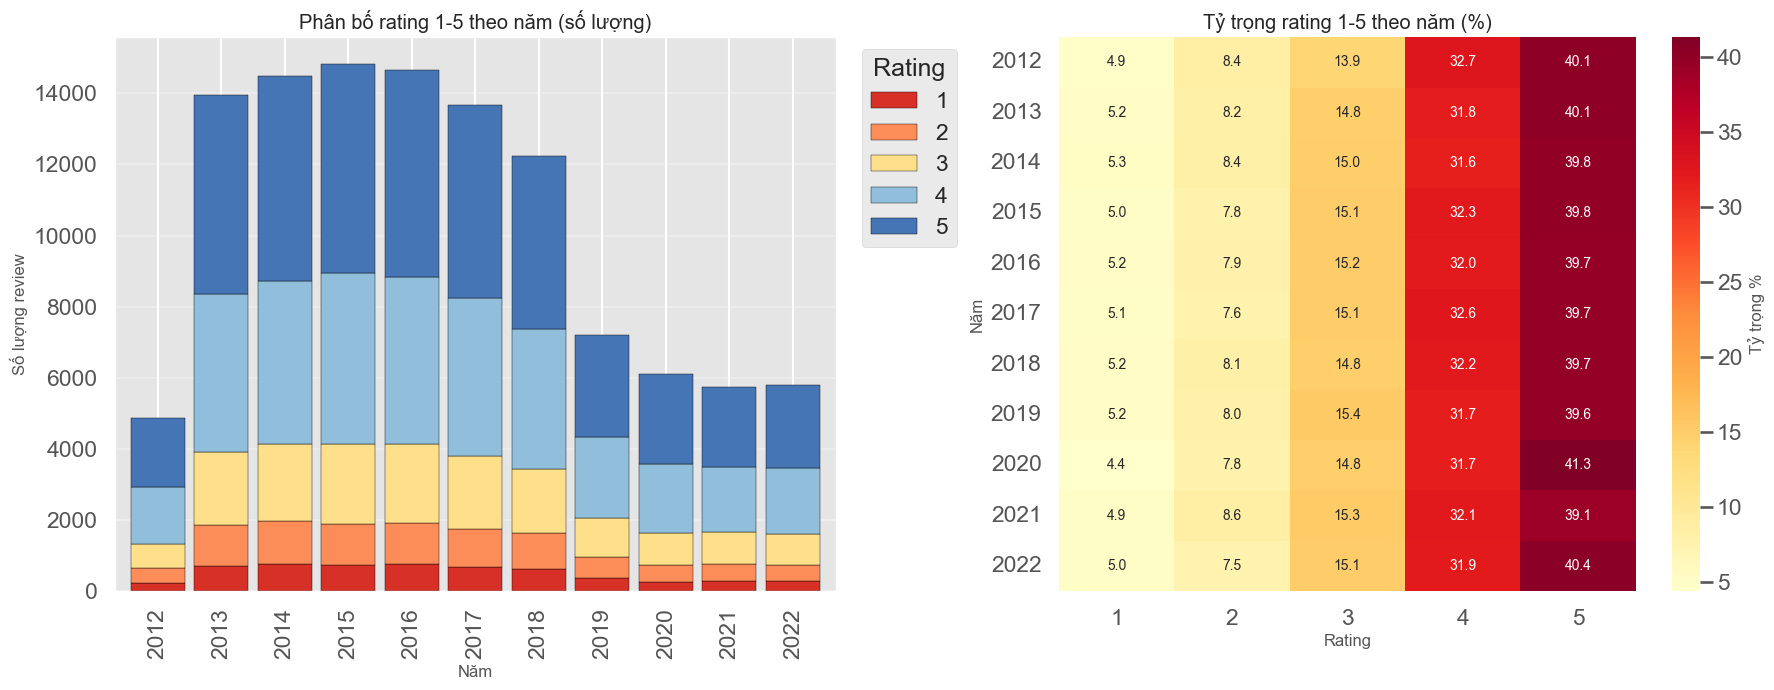

In [34]:
# ======================================================================
# PHÂN BỐ ĐIỂM RATING 1-5 THEO TỪNG NĂM
# ======================================================================

rating_year = reviews.copy()
rating_year['year'] = rating_year['review_date'].dt.year
rating_year['rating_int'] = rating_year['rating'].round().astype('Int64')
rating_year = rating_year[rating_year['rating_int'].between(1, 5)].copy()

rating_year_summary = (
    rating_year.groupby(['year', 'rating_int'])
    .size()
    .reset_index(name='count')
)

rating_pivot = (
    rating_year_summary.pivot(index='year', columns='rating_int', values='count')
    .reindex(columns=[1, 2, 3, 4, 5])
    .fillna(0)
    .astype(int)
)

rating_share = rating_pivot.div(rating_pivot.sum(axis=1), axis=0) * 100

print('\n' + '=' * 100)
print('PHÂN BỐ ĐIỂM RATING 1-5 THEO NĂM')
print('=' * 100)
print(rating_pivot.to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Stacked bar chart by year
ax = axes[0]
colors = ['#d73027', '#fc8d59', '#fee08b', '#91bfdb', '#4575b4']
rating_pivot.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.85, edgecolor='black', linewidth=0.3)
ax.set_title('Phân bố rating 1-5 theo năm (số lượng)')
ax.set_xlabel('Năm')
ax.set_ylabel('Số lượng review')
ax.legend(title='Rating', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Heatmap of shares
ax = axes[1]
sns.heatmap(
    rating_share,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Tỷ trọng %'},
    ax=ax
)
ax.set_title('Tỷ trọng rating 1-5 theo năm (%)')
ax.set_xlabel('Rating')
ax.set_ylabel('Năm')

plt.tight_layout()
plt.show()

rating_year_distribution = rating_pivot.copy()
rating_year_share = rating_share.copy()


TỈ LỆ TRẢ HÀNG THEO NĂM
 year  total_orders  return_count  return_rate_pct
 2012         32051          1790             5.58
 2013         76849          4933             6.42
 2014         80645          5073             6.29
 2015         82622          5200             6.29
 2016         82247          5176             6.29
 2017         76010          4782             6.29
 2018         69510          4226             6.08
 2019         41601          2495             6.00
 2020         34881          2084             5.97
 2021         34525          2030             5.88
 2022         36004          2150             5.97


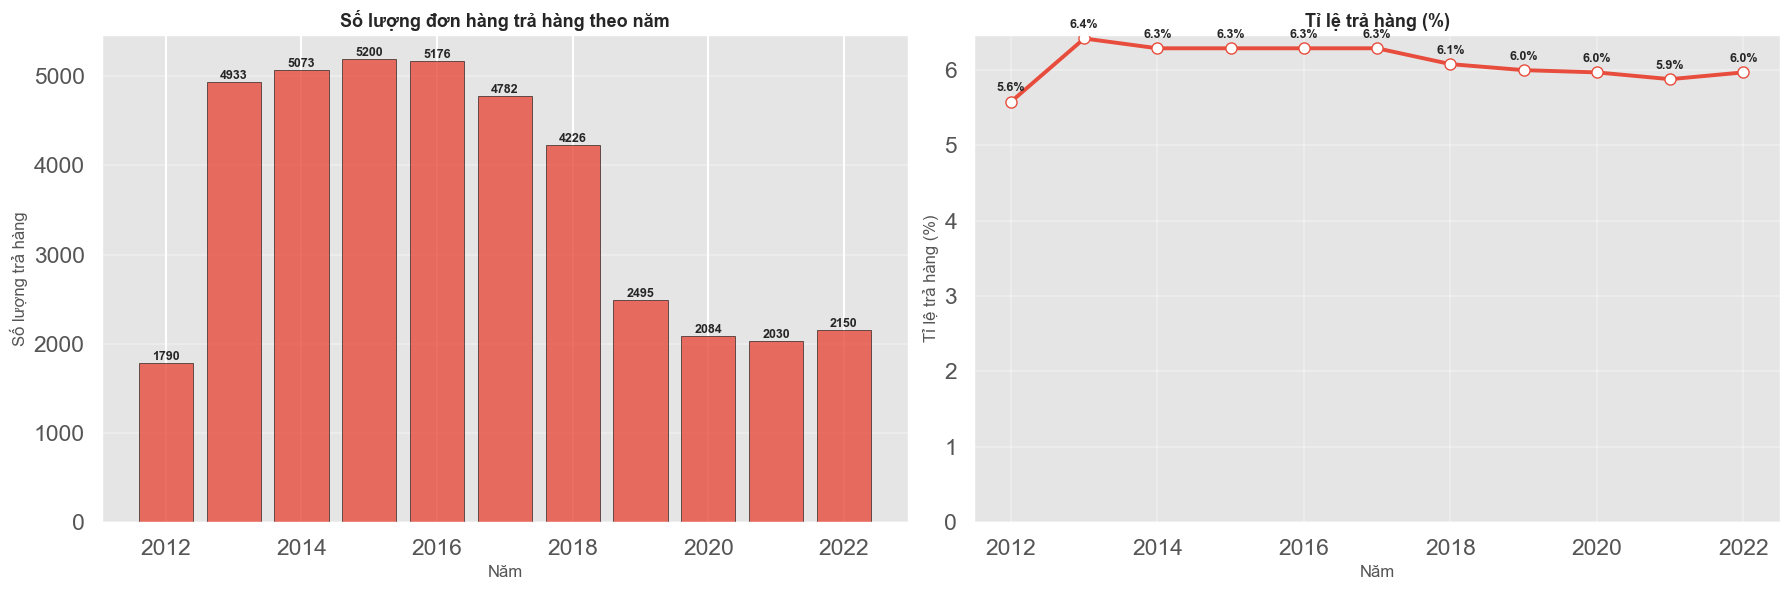

In [38]:
# ======================================================================
# TỈ LỆ TRẢ HÀNG THEO TỪNG NĂM
# ======================================================================

# Chuẩn bị dữ liệu trả hàng
returns_year = returns.copy()
returns_year['year'] = returns_year['return_date'].dt.year

# Tính số lượng đơn hàng trả hàng theo năm
returns_count = returns_year.groupby('year').size().reset_index(name='return_count')

# Tính số lượng tất cả đơn hàng theo năm
all_orders = orders.copy()
all_orders['year'] = all_orders['order_date'].dt.year
orders_count = all_orders.groupby('year').size().reset_index(name='total_orders')

# Merge để tính tỉ lệ
return_rate = orders_count.merge(returns_count, on='year', how='left')
return_rate['return_count'] = return_rate['return_count'].fillna(0).astype(int)
return_rate['return_rate_pct'] = (return_rate['return_count'] / return_rate['total_orders'] * 100).round(2)

print('\n' + '=' * 100)
print('TỈ LỆ TRẢ HÀNG THEO NĂM')
print('=' * 100)
print(return_rate.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ cột: Số lượng đơn trả hàng theo năm
ax = axes[0]
ax.bar(return_rate['year'], return_rate['return_count'], color='#e74c3c', edgecolor='black', linewidth=0.5, alpha=0.8)
ax.set_title('Số lượng đơn hàng trả hàng theo năm', fontweight='bold', fontsize=13)
ax.set_xlabel('Năm')
ax.set_ylabel('Số lượng trả hàng')
ax.grid(axis='y', alpha=0.3)
for idx, row in return_rate.iterrows():
    ax.text(row['year'], row['return_count'], str(int(row['return_count'])), 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

# Biểu đồ đường: Tỉ lệ trả hàng theo năm
ax = axes[1]
ax.plot(return_rate['year'], return_rate['return_rate_pct'], marker='o', linewidth=2.8, 
        markersize=8, color='#e74c3c', markerfacecolor='#fff')
ax.set_title('Tỉ lệ trả hàng (%)', fontweight='bold', fontsize=13)
ax.set_xlabel('Năm')
ax.set_ylabel('Tỉ lệ trả hàng (%)')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
for idx, row in return_rate.iterrows():
    ax.text(row['year'], row['return_rate_pct'] + max(return_rate['return_rate_pct'].max() * 0.01, 0.1), 
            f"{row['return_rate_pct']:.1f}%", ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


Dựa trên các chỉ số về thời gian giao hàng, đánh giá khách hàng và tỷ lệ trả hàng, có thể thấy chất lượng dịch vụ của doanh nghiệp duy trì ở mức ổn định trong suốt giai đoạn 2012–2022 và không xuất hiện biến động bất thường tại thời điểm doanh thu sụt giảm năm 2019.

Trước hết, xét về thời gian giao hàng, biểu đồ cho thấy giá trị này gần như không thay đổi đáng kể, dao động ổn định quanh mức ~4.45–4.55 ngày trong suốt 10 năm. Đặc biệt, tại năm 2019 – thời điểm doanh thu “gãy” – không có sự gia tăng đột biến nào về thời gian giao hàng. Thậm chí, giai đoạn sau 2019 (2019–2022) vẫn duy trì cùng một mặt bằng như trước đó, cho thấy hệ thống vận hành logistics không gặp vấn đề.

Về đánh giá của khách hàng (rating), phân bố điểm số qua các năm cũng khá ổn định. Tỷ trọng đánh giá cao (4–5 sao) luôn chiếm phần lớn, trong khi các mức đánh giá thấp (1–2 sao) không có xu hướng tăng lên theo thời gian. Mặc dù tổng số lượng review giảm sau 2019, nhưng cấu trúc phân bố rating không thay đổi đáng kể. Điều này cho thấy trải nghiệm khách hàng không bị suy giảm.

Đối với tỷ lệ trả hàng, chỉ số này duy trì ổn định quanh mức ~6% trong toàn bộ giai đoạn. Cụ thể, từ 2013 đến 2018, tỷ lệ này gần như giữ nguyên ở mức ~6.29%, sau đó giảm nhẹ xuống ~6.00% (2019) và tiếp tục dao động trong khoảng ~5.88%–5.97% giai đoạn 2020–2022. Không có dấu hiệu nào cho thấy sự gia tăng bất thường của việc trả hàng – một chỉ báo quan trọng về chất lượng sản phẩm hoặc sự không hài lòng của khách hàng.

Tổng hợp các phân tích trên, có thể khẳng định rằng không tồn tại mối liên hệ rõ ràng giữa chất lượng dịch vụ và sự sụt giảm doanh thu năm 2019. Các chỉ số vận hành và trải nghiệm khách hàng đều ổn định trước và sau thời điểm này, cho phép loại trừ giả thuyết rằng vấn đề đến từ dịch vụ. Điều này hàm ý rằng nguyên nhân cốt lõi nhiều khả năng nằm ở các yếu tố khác như hành vi khách hàng, nhu cầu thị trường hoặc chiến lược kinh doanh.

#### 5.2. Phân tích khách hàng (Customer)

Tiếp theo, chúng ta tập trung phân tích sự biến động trong quy mô tệp khách hàng của doanh nghiệp qua các năm

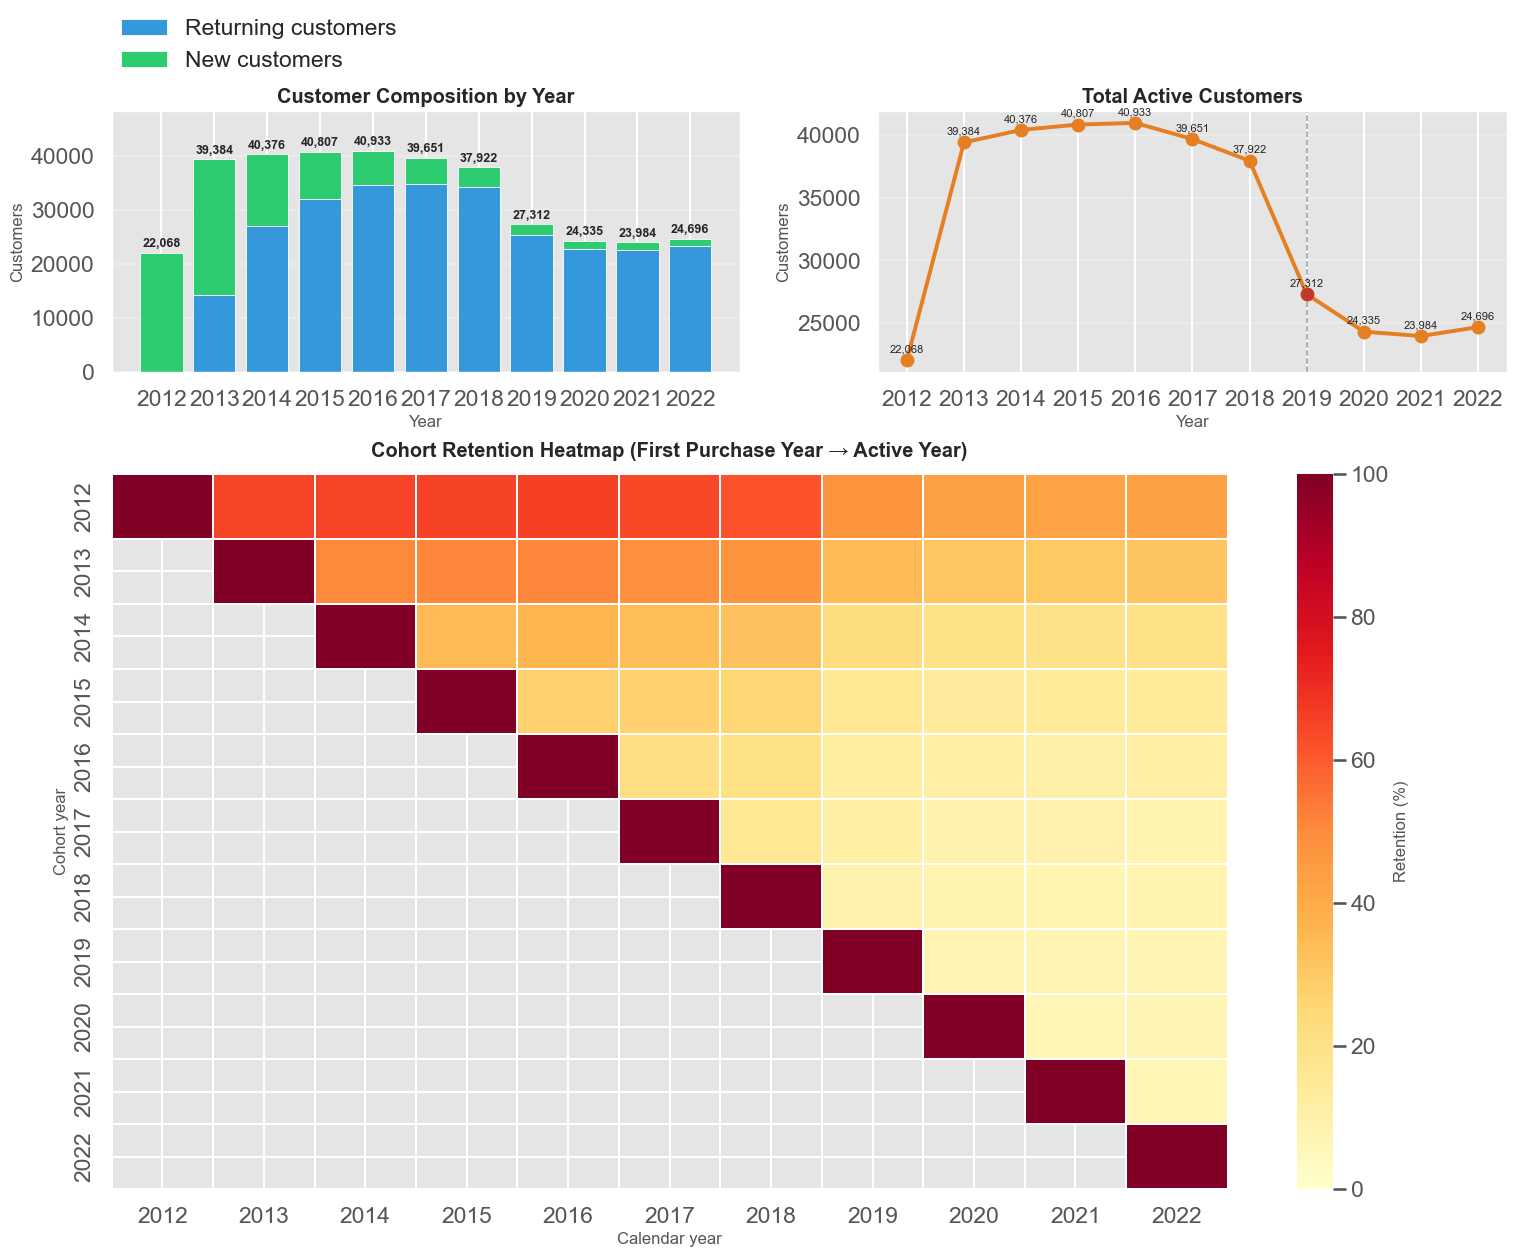

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.style.use('ggplot')

orders_yearly = orders[['customer_id', 'order_date']].dropna().copy()
orders_yearly['year'] = orders_yearly['order_date'].dt.year

# Unique customer-year activity
customer_year = orders_yearly[['customer_id', 'year']].drop_duplicates()

# Active customers and new customers by year
active_customers = customer_year.groupby('year')['customer_id'].nunique().sort_index().reset_index(name='active_customers')
first_purchase_year = customer_year.groupby('customer_id')['year'].min().reset_index(name='first_purchase_year')
customer_year = customer_year.merge(first_purchase_year, on='customer_id', how='left')
customer_year['is_new'] = customer_year['year'] == customer_year['first_purchase_year']

annual_mix = customer_year.groupby('year').agg(
    active_customers=('customer_id', 'nunique'),
    new_customers=('is_new', 'sum')
).reset_index().sort_values('year')
annual_mix['returning_customers'] = annual_mix['active_customers'] - annual_mix['new_customers']
annual_mix['new_share'] = (annual_mix['new_customers'] / annual_mix['active_customers'] * 100).round(1)
annual_mix['returning_share'] = (annual_mix['returning_customers'] / annual_mix['active_customers'] * 100).round(1)

# Focused 2018 → 2019 retention cohort
active_2018 = set(customer_year.loc[customer_year['year'] == 2018, 'customer_id'].unique())
active_2019 = set(customer_year.loc[customer_year['year'] == 2019, 'customer_id'].unique())
returned_2019 = active_2018.intersection(active_2019)
returned_2019_count = len(returned_2019)
churned_2019_count = len(active_2018) - returned_2019_count
retention_2019 = returned_2019_count / len(active_2018) * 100 if active_2018 else np.nan
churn_rate_2019 = 100 - retention_2019 if pd.notna(retention_2019) else np.nan
new_2018_count = int((first_purchase_year['first_purchase_year'] == 2018).sum())
new_2019_count = int((first_purchase_year['first_purchase_year'] == 2019).sum())

# Cohort retention heatmap: cohort year (first purchase) vs calendar year
cohort_base = customer_year[['customer_id', 'year', 'first_purchase_year']].drop_duplicates()
cohort_sizes = cohort_base.drop_duplicates('customer_id').groupby('first_purchase_year')['customer_id'].nunique()
cohort_retention = (
    cohort_base.groupby(['first_purchase_year', 'year'])['customer_id']
    .nunique()
    .div(cohort_sizes, level=0)
    .mul(100)
    .reset_index(name='retention_pct')
)
retention_matrix = cohort_retention.pivot(index='first_purchase_year', columns='year', values='retention_pct').sort_index()
all_years = list(range(int(cohort_base['year'].min()), int(cohort_base['year'].max()) + 1))
retention_matrix = retention_matrix.reindex(columns=all_years)

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, height_ratios=[1.0, 1.0, 1.35], hspace=0.35, wspace=0.22)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1:, :])

# 1) Customer composition stacked bar
x = annual_mix['year'].astype(int).to_list()
new_vals = annual_mix['new_customers'].to_list()
ret_vals = annual_mix['returning_customers'].to_list()
ax1.bar(x, ret_vals, color='#3498db', label='Returning customers', edgecolor='white', linewidth=0.6)
ax1.bar(x, new_vals, bottom=ret_vals, color='#2ecc71', label='New customers', edgecolor='white', linewidth=0.6)
for year, total in zip(x, annual_mix['active_customers'].to_list()):
    ax1.text(year, total + max(annual_mix['active_customers']) * 0.012, f'{total:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_title('Customer Composition by Year', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Customers')
ax1.set_xticks(x)
ax1.margins(y=0.18)
ax1.legend(frameon=False, loc='lower left', bbox_to_anchor=(0, 1.12), ncol=1, borderaxespad=0.)
ax1.grid(True, axis='y', alpha=0.25)

# 2) Total active customers line
ax2.plot(active_customers['year'], active_customers['active_customers'], color='#e67e22', marker='o', linewidth=2.8)
ax2.axvline(2019, color='#7f8c8d', linestyle='--', linewidth=1.1, alpha=0.85)
ax2.scatter([2019], [int(active_customers.loc[active_customers['year'] == 2019, 'active_customers'].iloc[0])], s=85, color='#c0392b', zorder=3)
for _, row in active_customers.iterrows():
    ax2.text(row['year'], row['active_customers'] + max(active_customers['active_customers']) * 0.012, f"{int(row['active_customers']):,}", ha='center', va='bottom', fontsize=8)
ax2.set_title('Total Active Customers', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Customers')
ax2.set_xticks(active_customers['year'].tolist())
ax2.grid(True, axis='y', alpha=0.25)

# 3) Cohort retention heatmap
sns.heatmap(
    retention_matrix,
    ax=ax3,
    cmap='YlOrRd',
    vmin=0,
    vmax=100,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Retention (%)'},
)
ax3.set_title('Cohort Retention Heatmap (First Purchase Year → Active Year)', fontweight='bold', pad=12)
ax3.set_xlabel('Calendar year')
ax3.set_ylabel('Cohort year')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


Ba biểu đồ trên cho thấy bức tranh khách hàng khá rõ ở điểm gãy doanh thu năm 2019.

Trước hết, xét về quy mô khách hàng, biểu đồ stacked bar cho thấy giai đoạn 2013–2018 là thời kỳ tăng trưởng và duy trì ổn định, với tổng số khách hàng hoạt động tăng từ 39,384 (2013) lên đỉnh 40,933 (2016) và vẫn giữ ở mức cao 37,922 (2018). Tuy nhiên, bước sang năm 2019, tổng số khách hàng giảm mạnh xuống còn 27,312, tương đương mức giảm khoảng -27.9% chỉ trong một năm. Đáng chú ý, mức suy giảm này tiếp tục kéo dài khi số lượng khách chỉ còn 24,335 (2020), 23,984 (2021) trước khi nhích nhẹ lên 24,696 (2022), nhưng vẫn thấp hơn đáng kể so với giai đoạn trước 2019.

Quan trọng hơn, sự suy giảm này đến từ cả hai thành phần. Số lượng khách hàng quay lại giảm mạnh từ khoảng ~35,000–36,000 (2016–2018) xuống còn khoảng ~25,000 (2019), trong khi khách hàng mới cũng sụt giảm rõ rệt, từ mức khoảng ~3,700 (2018) xuống dưới 2,000 (2019). Điều này cho thấy doanh nghiệp không chỉ mất khách cũ mà còn không thu hút đủ khách mới để bù đắp, dẫn đến việc quy mô tệp khách hàng bị “co lại” một cách đáng kể.

Biểu đồ line về total active customers củng cố thêm nhận định này khi thể hiện một “cú gãy” rất rõ tại năm 2019. Trước đó, số lượng khách tăng trưởng đều từ 22,068 (2012) lên hơn 40,000 (2014–2016), sau đó giảm nhẹ về 39,651 (2017) và 37,922 (2018). Tuy nhiên, mức giảm từ 37,922 xuống 27,312 (2019) là cú sụt mạnh nhất trong toàn bộ giai đoạn, và từ 2020–2022, đường biểu diễn gần như đi ngang quanh mức ~24,000–25,000, cho thấy doanh nghiệp không thể phục hồi lại quy mô khách hàng ban đầu mà rơi vào trạng thái stagnation.

Đáng chú ý nhất là cohort retention heatmap, cho thấy khả năng giữ chân khách hàng suy giảm rõ rệt qua thời gian. Các cohort giai đoạn đầu (2012–2016) vẫn duy trì được mức retention khoảng ~45–55% trong năm kế tiếp, nhưng xu hướng giảm dần khi đi xa hơn theo thời gian. Đặc biệt, cohort 2018 → 2019 chỉ còn khoảng ~43–44% retention, thấp hơn so với các cohort trước đó, phản ánh mức churn gia tăng rõ rệt đúng vào thời điểm doanh thu sụt giảm. Ngoài ra, các cohort sau 2019 tiếp tục duy trì ở mức thấp hơn (khoảng ~30–40% ở các năm tiếp theo), không cho thấy dấu hiệu cải thiện đáng kể, củng cố nhận định rằng vấn đề giữ chân khách hàng không chỉ là cú sốc nhất thời mà mang tính kéo dài.

Tiếp nối các phân tích về quy mô và khả năng giữ chân khách hàng, phần này tập trung làm rõ một câu hỏi quan trọng hơn: những khách hàng còn lại đang mua sắm như thế nào. Việc doanh nghiệp mất đi một lượng lớn khách hàng có thể giải thích sự sụt giảm về quy mô, tuy nhiên chưa đủ để kết luận toàn bộ nguyên nhân nếu hành vi tiêu dùng của nhóm khách còn lại cũng thay đổi.

Do đó, cần đi sâu vào các chỉ số hành vi như số đơn hàng trên mỗi khách hàng, số lượng sản phẩm trong mỗi đơn, giá trị đơn hàng trung bình (AOV) và tần suất mua. Phân tích này sẽ giúp xác định liệu sự sụt giảm doanh thu chỉ đến từ việc mất khách, hay còn đến từ việc khách hàng hiện tại mua ít hơn, mua thưa hơn, hoặc thay đổi cách chi tiêu. Đây là bước quan trọng để phân biệt giữa vấn đề về quy mô khách hàng và vấn đề về mức độ tiêu dùng, từ đó hoàn thiện bức tranh về nguyên nhân đứt gãy doanh thu.

5.2. CUSTOMER BEHAVIOR & CUSTOMER QUALITY

--- Behavior summary (focus 2018 vs 2019) ---

--- Behavior summary (focus 2018 vs 2019) ---


,Year,Orders,Active Customers,Orders / Customer,Items / Order,AOV,Repeat Customer Rate (%)
6,2018,69510,37922,1.83,4.86,"26,617",43.3
7,2019,41601,27312,1.52,4.87,"27,326",33.3


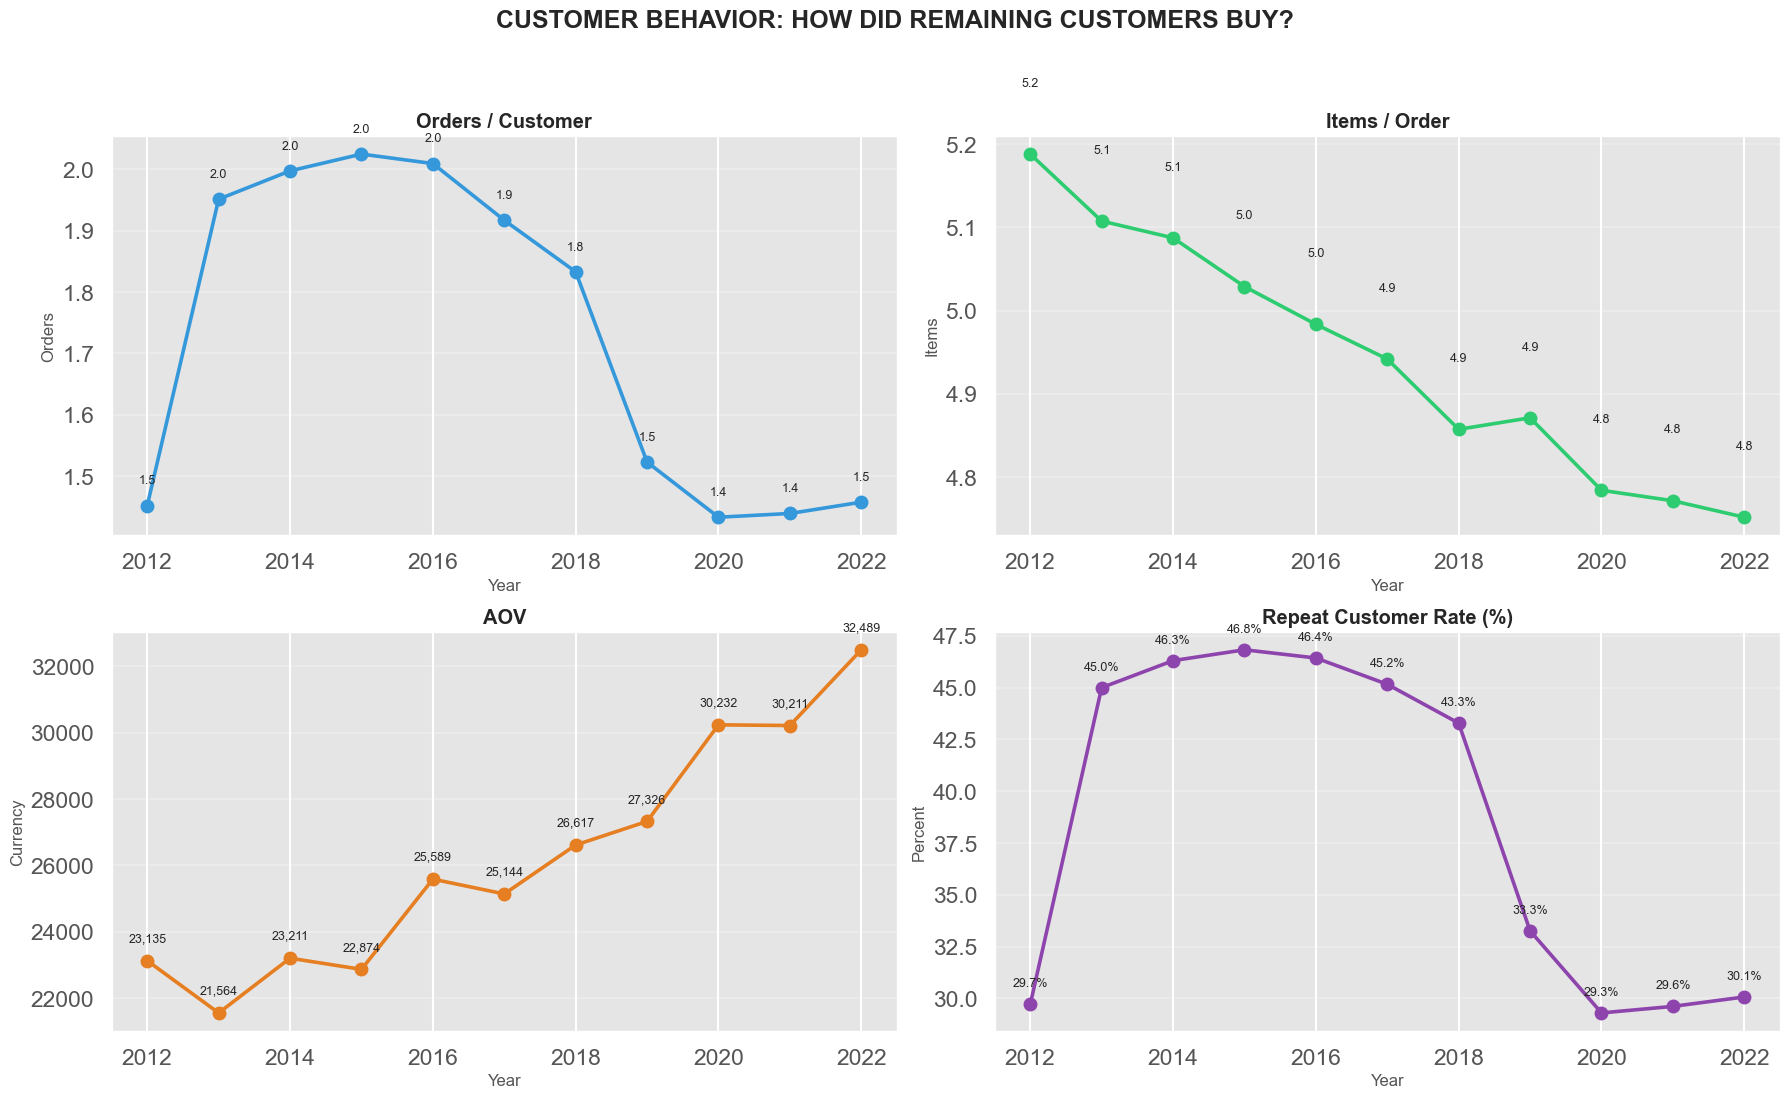


--- Behavior summary table ---


,Year,Orders,Active Customers,Orders / Customer,Items / Order,AOV,Repeat Customer Rate (%)
0,2012,32051,22068,1.45,5.19,"23,135",29.7
1,2013,76849,39384,1.95,5.11,"21,564",45.0
2,2014,80645,40376,2.00,5.09,"23,211",46.3
3,2015,82622,40807,2.02,5.03,"22,874",46.8
4,2016,82247,40933,2.01,4.98,"25,589",46.4
5,2017,76010,39651,1.92,4.94,"25,144",45.2
6,2018,69510,37922,1.83,4.86,"26,617",43.3
7,2019,41601,27312,1.52,4.87,"27,326",33.3
8,2020,34881,24335,1.43,4.78,"30,232",29.3
9,2021,34525,23984,1.44,4.77,"30,211",29.6



--- Customer quality summary (focus 2018 vs 2019) ---


,Year,Revenue / Customer
6,2018,"48,788"
7,2019,"41,623"


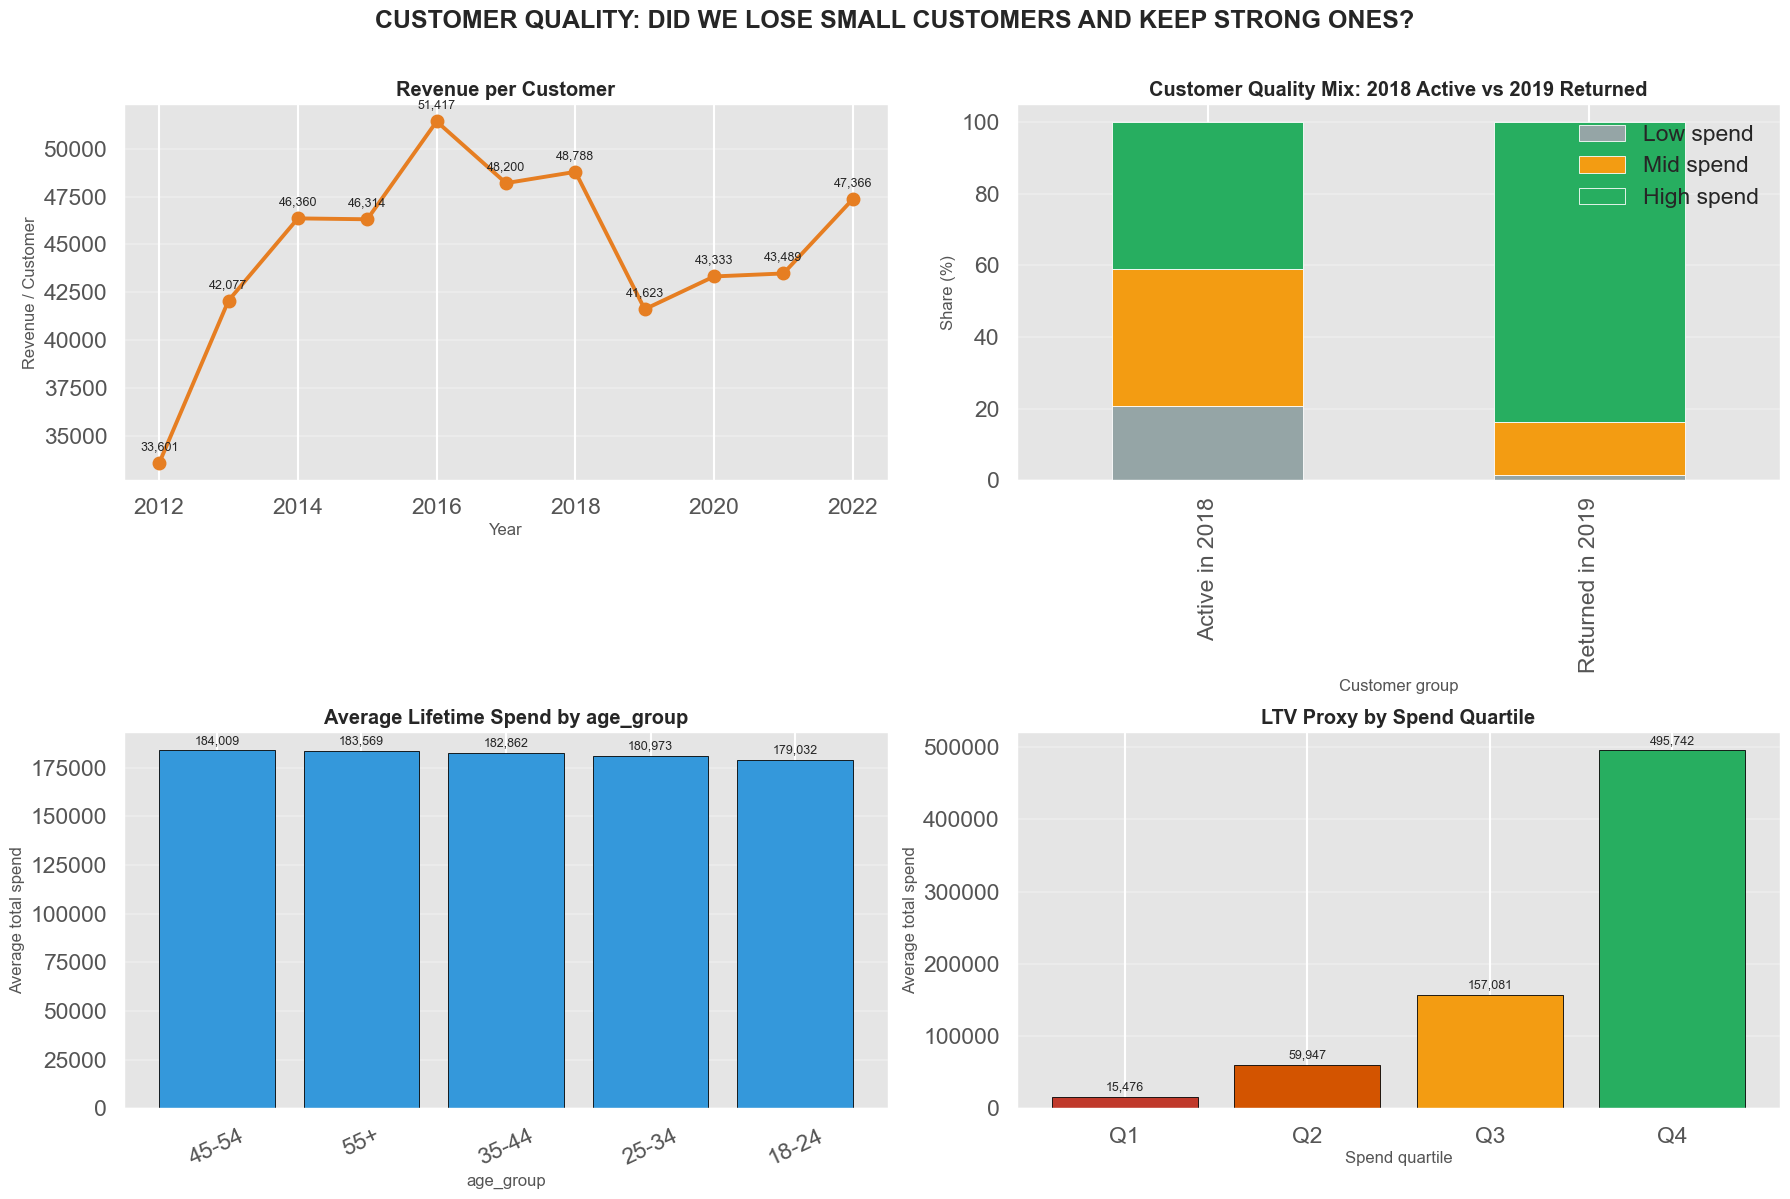


--- Customer quality summary table ---


,Year,Revenue / Customer
0,2012,"33,601"
1,2013,"42,077"
2,2014,"46,360"
3,2015,"46,314"
4,2016,"51,417"
5,2017,"48,200"
6,2018,"48,788"
7,2019,"41,623"
8,2020,"43,333"
9,2021,"43,489"



--- Customer quality mix table (share %) ---


spend_tier,Low spend,Mid spend,High spend
Customer group,,,
Active in 2018,20.7,38.4,40.9
Returned in 2019,1.3,15.0,83.6



--- Average lifetime spend by age_group ---


,age_group,Average Lifetime Spend
0,45-54,"184,009"
1,55+,"183,569"
2,35-44,"182,862"
3,25-34,"180,973"
4,18-24,"179,032"



--- LTV proxy by spend quartile ---


,Spend Quartile,Average Total Spend
0,Q1,"15,476"
1,Q2,"59,947"
2,Q3,"157,081"
3,Q4,"495,742"


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
plt.style.use('ggplot')

print('=' * 80)
print('5.2. CUSTOMER BEHAVIOR & CUSTOMER QUALITY')
print('=' * 80)

# -----------------------------------------------------------------------------
# 1) Behavior: orders/customer, items/order, AOV, purchase frequency
# -----------------------------------------------------------------------------
orders_txn = orders[['order_id', 'customer_id', 'order_date']].dropna().copy()
orders_txn['year'] = orders_txn['order_date'].dt.year
orders_txn = orders_txn.drop_duplicates('order_id')

items_txn = order_items.copy()
if 'order_id' not in items_txn.columns:
    raise ValueError('order_items must contain order_id for the behavior analysis.')

has_quantity = 'quantity' in items_txn.columns
has_unit_price = 'unit_price' in items_txn.columns

if has_quantity:
    items_txn['units'] = pd.to_numeric(items_txn['quantity'], errors='coerce').fillna(0)
else:
    items_txn['units'] = 1

if has_quantity and has_unit_price:
    items_txn['line_value'] = pd.to_numeric(items_txn['quantity'], errors='coerce').fillna(0) * pd.to_numeric(items_txn['unit_price'], errors='coerce').fillna(0)
elif has_unit_price:
    items_txn['line_value'] = pd.to_numeric(items_txn['unit_price'], errors='coerce').fillna(0)
else:
    items_txn['line_value'] = np.nan

order_item_summary = items_txn.groupby('order_id').agg(
    total_units=('units', 'sum'),
    total_value=('line_value', 'sum'),
    line_items=('order_id', 'size')
).reset_index()

behavior_base = orders_txn.merge(order_item_summary, on='order_id', how='left')
behavior_base[['total_units', 'total_value', 'line_items']] = behavior_base[['total_units', 'total_value', 'line_items']].fillna(0)

annual_behavior = behavior_base.groupby('year').agg(
    orders=('order_id', 'nunique'),
    active_customers=('customer_id', 'nunique'),
    total_units=('total_units', 'sum'),
    total_revenue=('total_value', 'sum')
).reset_index().sort_values('year')

annual_behavior['orders_per_customer'] = annual_behavior['orders'] / annual_behavior['active_customers']
annual_behavior['items_per_order'] = annual_behavior['total_units'] / annual_behavior['orders']
annual_behavior['aov'] = annual_behavior['total_revenue'] / annual_behavior['orders']

customer_orders_year = orders_txn.groupby(['year', 'customer_id']).size().reset_index(name='order_count')
repeat_rate_behavior = customer_orders_year.groupby('year')['order_count'].apply(lambda s: (s > 1).mean() * 100).reset_index(name='repeat_customer_rate')
annual_behavior = annual_behavior.merge(repeat_rate_behavior, on='year', how='left')

behavior_focus = annual_behavior.loc[annual_behavior['year'].isin([2018, 2019]), [
    'year', 'orders', 'active_customers', 'orders_per_customer', 'items_per_order', 'aov', 'repeat_customer_rate'
]].copy()
behavior_focus['aov'] = behavior_focus['aov'].round(2)
behavior_focus['orders_per_customer'] = behavior_focus['orders_per_customer'].round(2)
behavior_focus['items_per_order'] = behavior_focus['items_per_order'].round(2)
behavior_focus['repeat_customer_rate'] = behavior_focus['repeat_customer_rate'].round(1)
behavior_focus['aov'] = behavior_focus['aov'].map(lambda x: f'{x:,.0f}')

print('\n--- Behavior summary (focus 2018 vs 2019) ---')
display(behavior_focus.rename(columns={
    'year': 'Year',
    'orders': 'Orders',
    'active_customers': 'Active Customers',
    'orders_per_customer': 'Orders / Customer',
    'items_per_order': 'Items / Order',
    'aov': 'AOV',
    'repeat_customer_rate': 'Repeat Customer Rate (%)'
}))

fig1, axes1 = plt.subplots(2, 2, figsize=(18, 11))
fig1.suptitle('CUSTOMER BEHAVIOR: HOW DID REMAINING CUSTOMERS BUY?', fontsize=18, fontweight='bold', y=0.995)

behavior_lines = [
    ('orders_per_customer', 'Orders / Customer', '#3498db'),
    ('items_per_order', 'Items / Order', '#2ecc71'),
    ('aov', 'AOV', '#e67e22'),
    ('repeat_customer_rate', 'Repeat Customer Rate (%)', '#8e44ad'),
]

for ax, (col, title, color) in zip(axes1.flat, behavior_lines):
    ax.plot(annual_behavior['year'], annual_behavior[col], marker='o', linewidth=2.6, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Year')
    ax.grid(True, axis='y', alpha=0.25)
    for _, row in annual_behavior.iterrows():
        label = f"{row[col]:.1f}"
        if col == 'aov':
            label = f"{row[col]:,.0f}"
        elif col == 'repeat_customer_rate':
            label = f"{row[col]:.1f}%"
        ax.text(row['year'], row[col] + max(annual_behavior[col].max() * 0.015, 0.02), label, ha='center', va='bottom', fontsize=9)

axes1[0, 0].set_ylabel('Orders')
axes1[0, 1].set_ylabel('Items')
axes1[1, 0].set_ylabel('Currency')
axes1[1, 1].set_ylabel('Percent')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

behavior_summary_table = annual_behavior[['year', 'orders', 'active_customers', 'orders_per_customer', 'items_per_order', 'aov', 'repeat_customer_rate']].copy()
behavior_summary_table.columns = ['Year', 'Orders', 'Active Customers', 'Orders / Customer', 'Items / Order', 'AOV', 'Repeat Customer Rate (%)']
behavior_summary_table['Orders / Customer'] = behavior_summary_table['Orders / Customer'].round(2)
behavior_summary_table['Items / Order'] = behavior_summary_table['Items / Order'].round(2)
behavior_summary_table['Repeat Customer Rate (%)'] = behavior_summary_table['Repeat Customer Rate (%)'].round(1)
behavior_summary_table['AOV'] = behavior_summary_table['AOV'].map(lambda x: f'{x:,.0f}')
print('\n--- Behavior summary table ---')
display(behavior_summary_table.reset_index(drop=True))

# -----------------------------------------------------------------------------
# 2) Customer quality: revenue/customer, LTV proxy, and segment mix
# -----------------------------------------------------------------------------
customer_profile_cols = ['customer_id']
for candidate in ['age_group', 'gender']:
    if candidate in customers.columns:
        customer_profile_cols.append(candidate)

customer_profile = customers[customer_profile_cols].drop_duplicates('customer_id').copy()

customer_ltv = behavior_base.groupby('customer_id').agg(
    total_spend=('total_value', 'sum'),
    total_orders=('order_id', 'nunique'),
    first_year=('year', 'min'),
    last_year=('year', 'max')
).reset_index()
customer_ltv = customer_ltv.merge(customer_profile, on='customer_id', how='left')

customer_ltv['spend_tier'] = pd.qcut(
    customer_ltv['total_spend'].rank(method='first'),
    q=3,
    labels=['Low spend', 'Mid spend', 'High spend']
)

active_2018_ids = set(orders_txn.loc[orders_txn['year'] == 2018, 'customer_id'].unique())
active_2019_ids = set(orders_txn.loc[orders_txn['year'] == 2019, 'customer_id'].unique())
retained_2019_ids = active_2018_ids.intersection(active_2019_ids)

quality_mix = customer_ltv.loc[customer_ltv['customer_id'].isin(active_2018_ids.union(retained_2019_ids))].copy()
quality_mix['group'] = np.where(quality_mix['customer_id'].isin(retained_2019_ids), 'Returned in 2019', 'Active in 2018')
quality_mix_pivot = (
    quality_mix.pivot_table(index='group', columns='spend_tier', values='customer_id', aggfunc='count', fill_value=0)
    .reindex(['Active in 2018', 'Returned in 2019'])
)
quality_mix_pct = quality_mix_pivot.div(quality_mix_pivot.sum(axis=1), axis=0) * 100

revenue_per_customer = annual_behavior[['year', 'total_revenue', 'active_customers']].copy()
revenue_per_customer['revenue_per_customer'] = revenue_per_customer['total_revenue'] / revenue_per_customer['active_customers']

quality_focus = revenue_per_customer.loc[revenue_per_customer['year'].isin([2018, 2019]), ['year', 'revenue_per_customer']].copy()
quality_focus['revenue_per_customer'] = quality_focus['revenue_per_customer'].round(2)
quality_focus['revenue_per_customer'] = quality_focus['revenue_per_customer'].map(lambda x: f'{x:,.0f}')

print('\n--- Customer quality summary (focus 2018 vs 2019) ---')
display(quality_focus.rename(columns={'year': 'Year', 'revenue_per_customer': 'Revenue / Customer'}))

fig2, axes2 = plt.subplots(2, 2, figsize=(18, 12))
fig2.suptitle('CUSTOMER QUALITY: DID WE LOSE SMALL CUSTOMERS AND KEEP STRONG ONES?', fontsize=18, fontweight='bold', y=0.995)

# 2.1 Revenue per customer trend
axes2[0, 0].plot(revenue_per_customer['year'], revenue_per_customer['revenue_per_customer'], marker='o', linewidth=2.8, color='#e67e22')
axes2[0, 0].set_title('Revenue per Customer', fontweight='bold')
axes2[0, 0].set_xlabel('Year')
axes2[0, 0].set_ylabel('Revenue / Customer')
axes2[0, 0].grid(True, axis='y', alpha=0.25)
for _, row in revenue_per_customer.iterrows():
    axes2[0, 0].text(row['year'], row['revenue_per_customer'] + revenue_per_customer['revenue_per_customer'].max() * 0.01, f"{row['revenue_per_customer']:,.0f}", ha='center', va='bottom', fontsize=9)

# 2.2 Quality mix by spend tier
quality_mix_pct[['Low spend', 'Mid spend', 'High spend']].plot(
    kind='bar', stacked=True, ax=axes2[0, 1],
    color=['#95a5a6', '#f39c12', '#27ae60'], edgecolor='white', linewidth=0.6
)
axes2[0, 1].set_title('Customer Quality Mix: 2018 Active vs 2019 Returned', fontweight='bold')
axes2[0, 1].set_xlabel('Customer group')
axes2[0, 1].set_ylabel('Share (%)')
axes2[0, 1].legend(frameon=False, loc='upper right')
axes2[0, 1].grid(True, axis='y', alpha=0.25)

# 2.3 Segment split by age_group if available, otherwise gender
segment_col = 'age_group' if 'age_group' in customer_profile.columns else ('gender' if 'gender' in customer_profile.columns else None)
if segment_col is not None:
    segment_table = customer_ltv.dropna(subset=[segment_col]).groupby(segment_col)['total_spend'].mean().sort_values(ascending=False)
    axes2[1, 0].bar(segment_table.index.astype(str), segment_table.values, color='#3498db', edgecolor='black', linewidth=0.6)
    axes2[1, 0].set_title(f'Average Lifetime Spend by {segment_col}', fontweight='bold')
    axes2[1, 0].set_xlabel(segment_col)
    axes2[1, 0].set_ylabel('Average total spend')
    axes2[1, 0].grid(True, axis='y', alpha=0.25)
    axes2[1, 0].tick_params(axis='x', rotation=25)
    for i, v in enumerate(segment_table.values):
        axes2[1, 0].text(i, v + segment_table.max() * 0.01, f"{v:,.0f}", ha='center', va='bottom', fontsize=9)
else:
    axes2[1, 0].axis('off')
    axes2[1, 0].text(0.5, 0.5, 'No usable age_group / gender columns found.', ha='center', va='center', fontsize=12)

# 2.4 LTV proxy distribution summary
ltv_quartile = pd.qcut(customer_ltv['total_spend'].rank(method='first'), q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
ltv_summary = customer_ltv.assign(spend_quartile=ltv_quartile).groupby('spend_quartile')['total_spend'].mean().reset_index()
axes2[1, 1].bar(ltv_summary['spend_quartile'].astype(str), ltv_summary['total_spend'], color=['#c0392b', '#d35400', '#f39c12', '#27ae60'], edgecolor='black', linewidth=0.6)
axes2[1, 1].set_title('LTV Proxy by Spend Quartile', fontweight='bold')
axes2[1, 1].set_xlabel('Spend quartile')
axes2[1, 1].set_ylabel('Average total spend')
axes2[1, 1].grid(True, axis='y', alpha=0.25)
for i, v in enumerate(ltv_summary['total_spend']):
    axes2[1, 1].text(i, v + ltv_summary['total_spend'].max() * 0.01, f"{v:,.0f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

quality_summary_table = revenue_per_customer[['year', 'revenue_per_customer']].copy()
quality_summary_table.columns = ['Year', 'Revenue / Customer']
quality_summary_table['Revenue / Customer'] = quality_summary_table['Revenue / Customer'].map(lambda x: f'{x:,.0f}')
quality_mix_table = quality_mix_pct[['Low spend', 'Mid spend', 'High spend']].round(1).copy()
quality_mix_table.index.name = 'Customer group'
segment_summary_table = None
if segment_col is not None:
    segment_summary_table = customer_ltv.dropna(subset=[segment_col]).groupby(segment_col)['total_spend'].mean().sort_values(ascending=False).reset_index()
    segment_summary_table.columns = [segment_col, 'Average Lifetime Spend']
    segment_summary_table['Average Lifetime Spend'] = segment_summary_table['Average Lifetime Spend'].map(lambda x: f'{x:,.0f}')
ltv_summary_table = ltv_summary.copy()
ltv_summary_table.columns = ['Spend Quartile', 'Average Total Spend']
ltv_summary_table['Average Total Spend'] = ltv_summary_table['Average Total Spend'].map(lambda x: f'{x:,.0f}')
print('\n--- Customer quality summary table ---')
display(quality_summary_table.reset_index(drop=True))
print('\n--- Customer quality mix table (share %) ---')
display(quality_mix_table)
if segment_summary_table is not None:
    print(f'\n--- Average lifetime spend by {segment_col} ---')
    display(segment_summary_table)
print('\n--- LTV proxy by spend quartile ---')
display(ltv_summary_table)


Dựa trên các bảng số liệu về hành vi mua và chất lượng khách hàng, có thể làm rõ hơn vai trò của nhóm khách còn lại sau cú sụt giảm năm 2019:

Trước hết, xét về hành vi tiêu dùng, dữ liệu cho thấy một xu hướng suy yếu khá rõ sau năm 2019. Trong giai đoạn tăng trưởng (2013–2016), mỗi khách hàng trung bình thực hiện khoảng ~2.0 đơn/năm, sau đó giảm dần xuống 1.83 (2018) và rơi mạnh còn 1.52 (2019), tiếp tục duy trì ở mức thấp ~1.43–1.46 trong giai đoạn 2020–2022. Điều này cho thấy khách hàng không chỉ ít đi, mà mỗi người cũng mua ít lần hơn, phản ánh sự suy giảm về tần suất mua.

Tương tự, repeat customer rate giảm mạnh từ mức ~43–46% (2013–2018) xuống còn 33.3% (2019) và chỉ còn khoảng ~29–30% trong các năm sau. Đây là dấu hiệu cho thấy mức độ gắn kết của khách hàng suy giảm đáng kể, không chỉ ở cấp độ giữ chân qua các năm mà cả trong hành vi mua lặp lại trong cùng năm.
Trong khi đó, Items per Order chỉ giảm nhẹ từ khoảng ~5.1 xuống ~4.7, cho thấy quy mô mỗi đơn hàng không thay đổi nhiều. Ngược lại, AOV (giá trị đơn hàng trung bình) lại tăng đều từ khoảng ~23K–25K trước 2019 lên ~27K (2019) và tiếp tục tăng lên ~30K–32K (2020–2022). Điều này cho thấy khách hàng vẫn chi tiêu nhiều tiền hơn trong mỗi lần mua, dù tần suất mua giảm.

Khi kết hợp với các chỉ số về chất lượng khách hàng, bức tranh trở nên rõ ràng hơn. Revenue per customer tăng đều từ 33,601 (2012) lên đỉnh 51,417 (2016), sau đó giảm xuống 41,623 (2019) nhưng vẫn duy trì quanh mức ~43K–47K trong giai đoạn sau. Điều này cho thấy dù tổng số khách giảm, giá trị trung bình mỗi khách vẫn tương đối ổn định, không bị sụp đổ.

Ngoài ra, phân tích theo phân khúc chi tiêu cho thấy sự phân hóa rất mạnh: nhóm khách hàng chi tiêu cao nhất (Q4) có mức chi tiêu trung bình lên tới ~495,742, cao gấp nhiều lần so với các nhóm còn lại. Trong khi đó, sự khác biệt giữa các nhóm tuổi lại không đáng kể (dao động quanh ~179K–184K), cho thấy yếu tố nhân khẩu học không phải là driver chính, mà mức độ chi tiêu (spend behavior) mới là yếu tố phân tách giá trị khách hàng.

Như vậy, sau năm 2019, doanh nghiệp không chỉ mất khách hàng về số lượng, mà nhóm khách còn lại cũng mua ít lần hơn và ít gắn bó hơn. Tuy nhiên, những khách hàng vẫn ở lại có xu hướng chi tiêu nhiều hơn trong mỗi đơn hàng, giúp duy trì giá trị trung bình trên mỗi khách.

Điều này cho thấy doanh thu sau 2019 đang được “chống đỡ” bởi một nhóm khách hàng có giá trị cao, thay vì đến từ tăng trưởng quy mô hoặc tần suất mua. Tuy nhiên, đây là một trạng thái không bền vững, vì nó phụ thuộc vào một tập khách hàng hẹp và không có sự bổ sung từ khách hàng mới. 

Tổng hợp lại, doanh nghiệp rơi vào một vòng xoáy tiêu cực: mất khách hàng trên diện rộng, không có nguồn khách mới thay thế, và mức độ tương tác của khách còn lại cũng suy giảm. Đây là nguyên nhân trực tiếp và quan trọng nhất dẫn đến sự sụt giảm mạnh về số lượng đơn hàng, khiến doanh thu lao dốc từ năm 2019.

### 5.3 Phân tích tỷ lệ chuyển đổi (Conversion rate)

Tiếp sau khi xác định vấn đề cốt lõi nằm ở sự suy giảm tệp khách hàng, một câu hỏi quan trọng cần được làm rõ là: liệu doanh nghiệp có thực sự thiếu người quan tâm, hay đang thất bại trong việc chuyển đổi sự quan tâm đó thành mua hàng. Nói cách khác, doanh thu sụt giảm có thể không chỉ đến từ việc “không có khách”, mà còn đến từ việc có traffic nhưng không biến được thành đơn hàng.


--- Traffic Summary (Sessions & Unique Visitors) ---
 year  sessions  unique_visitors  sessions_growth_pct  visitors_growth_pct
 2013   6801940          5166501                  NaN                  NaN
 2014   7340960          5596248             7.924504             8.317951
 2015   7861938          5962192             7.096865             6.539095
 2016   8403399          6393654             6.887119             7.236634
 2017   8992602          6818372             7.011484             6.642806
 2018   9415085          7143496             4.698117             4.768352
 2019   9990148          7580565             6.107890             6.118419
 2020  10591082          8065367             6.015266             6.395328
 2021  10991725          8367014             3.782834             3.740028
 2022  11063658          8409280             0.654429             0.505150


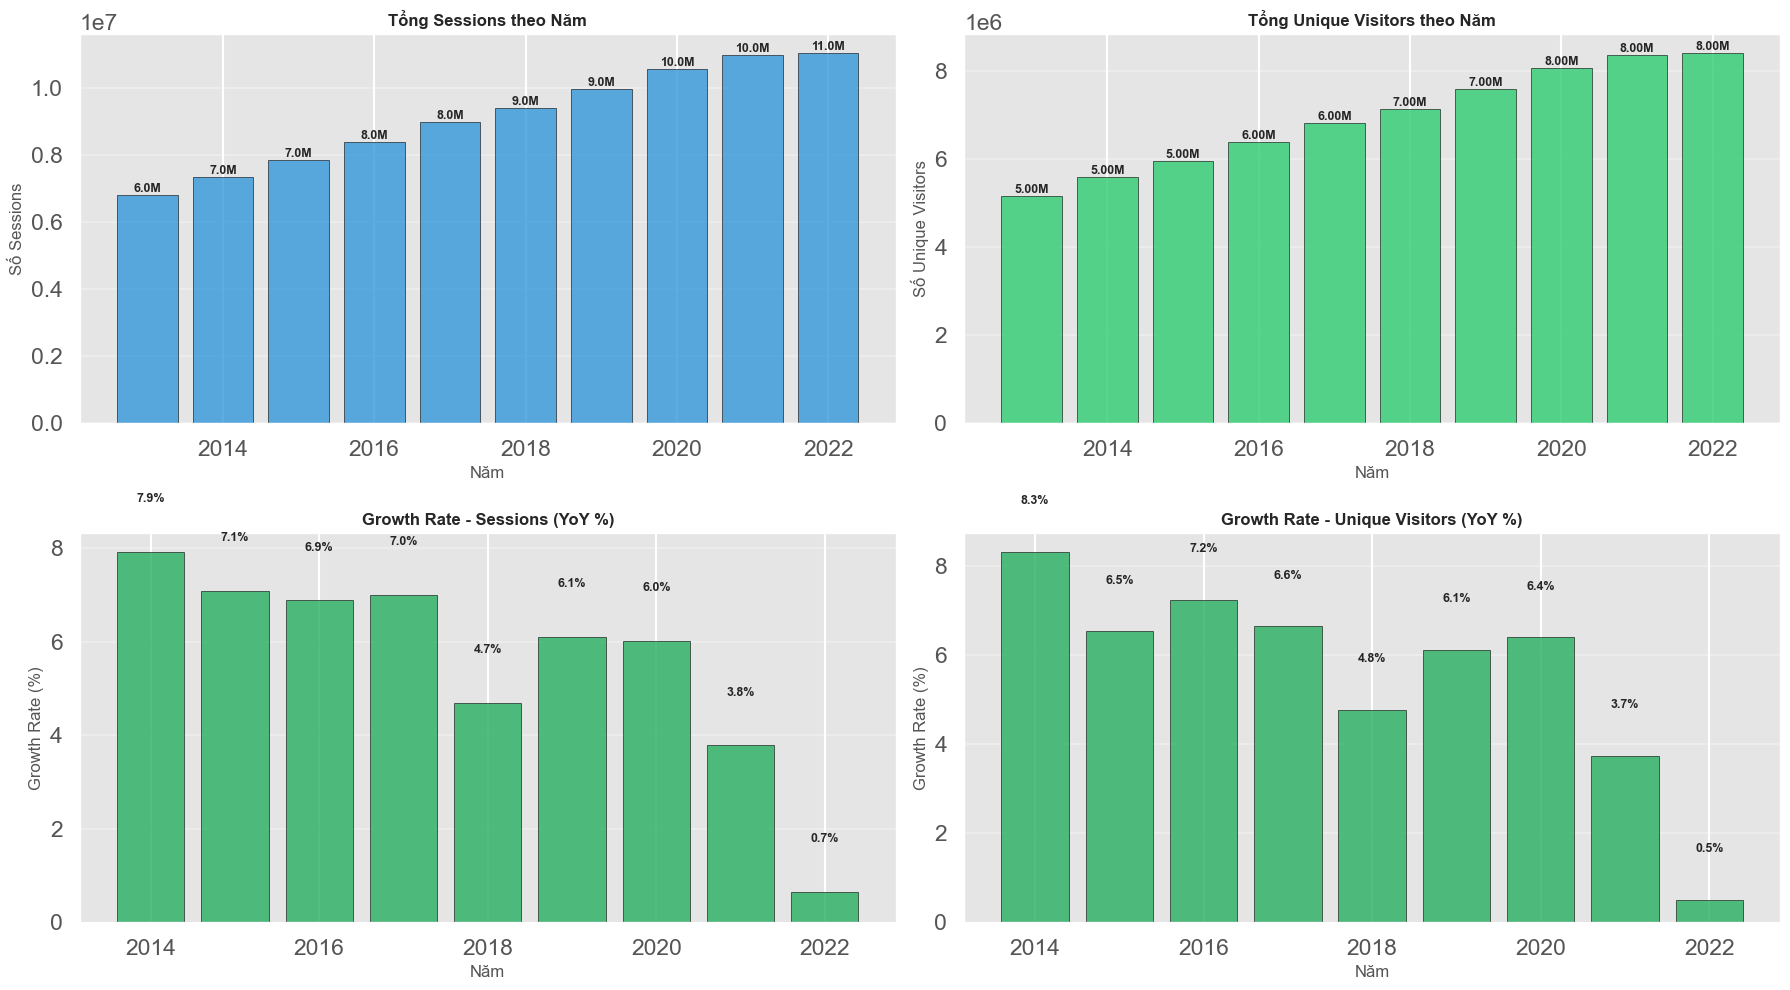

In [57]:


# Chuẩn bị dữ liệu traffic
traffic_year = web_traffic.copy()
traffic_year['year'] = traffic_year['date'].dt.year

# web_traffic có 1 dòng/ngày/nguồn, nên cần group by date trước để sum
traffic_daily = traffic_year.groupby('date').agg({
    'sessions': 'sum',
    'unique_visitors': 'sum'
}).reset_index()
traffic_daily['year'] = traffic_daily['date'].dt.year

# Tính sessions và unique visitors theo năm
traffic_summary = traffic_daily.groupby('year').agg({
    'sessions': 'sum',
    'unique_visitors': 'sum'
}).reset_index()

# Tính growth rate
traffic_summary['sessions_growth_pct'] = traffic_summary['sessions'].pct_change() * 100
traffic_summary['visitors_growth_pct'] = traffic_summary['unique_visitors'].pct_change() * 100

print('\n--- Traffic Summary (Sessions & Unique Visitors) ---')
print(traffic_summary.to_string(index=False))

# Tính metrics chính
avg_sessions_2018 = traffic_summary[traffic_summary['year'] == 2018]['sessions'].values[0]
avg_sessions_2019 = traffic_summary[traffic_summary['year'] == 2019]['sessions'].values[0]
sessions_change_pct = ((avg_sessions_2019 - avg_sessions_2018) / avg_sessions_2018) * 100

avg_visitors_2018 = traffic_summary[traffic_summary['year'] == 2018]['unique_visitors'].values[0]
avg_visitors_2019 = traffic_summary[traffic_summary['year'] == 2019]['unique_visitors'].values[0]
visitors_change_pct = ((avg_visitors_2019 - avg_visitors_2018) / avg_visitors_2018) * 100

# Vẽ biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(18, 10))


# Biểu đồ 1: Sessions theo năm
ax = axes[0, 0]
bars = ax.bar(traffic_summary['year'], traffic_summary['sessions'], 
              color='#3498db', edgecolor='black', linewidth=0.5, alpha=0.8)
ax.set_title('Tổng Sessions theo Năm', fontweight='bold', fontsize=12)
ax.set_xlabel('Năm')
ax.set_ylabel('Số Sessions')
ax.grid(axis='y', alpha=0.3)
for idx, row in traffic_summary.iterrows():
    ax.text(row['year'], row['sessions'], f"{int(row['sessions']/1e6):.1f}M", 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

# Biểu đồ 2: Unique Visitors theo năm
ax = axes[0, 1]
bars = ax.bar(traffic_summary['year'], traffic_summary['unique_visitors'], 
              color='#2ecc71', edgecolor='black', linewidth=0.5, alpha=0.8)
ax.set_title('Tổng Unique Visitors theo Năm', fontweight='bold', fontsize=12)
ax.set_xlabel('Năm')
ax.set_ylabel('Số Unique Visitors')
ax.grid(axis='y', alpha=0.3)
for idx, row in traffic_summary.iterrows():
    ax.text(row['year'], row['unique_visitors'], f"{int(row['unique_visitors']/1e6):.2f}M", 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

# Biểu đồ 3: Growth Rate - Sessions
ax = axes[1, 0]
colors_growth = ['#27ae60' if x > 0 else '#e74c3c' for x in traffic_summary['sessions_growth_pct'].fillna(0)]
ax.bar(traffic_summary['year'][1:], traffic_summary['sessions_growth_pct'][1:], 
       color=colors_growth[1:], edgecolor='black', linewidth=0.5, alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_title('Growth Rate - Sessions (YoY %)', fontweight='bold', fontsize=12)
ax.set_xlabel('Năm')
ax.set_ylabel('Growth Rate (%)')
ax.grid(axis='y', alpha=0.3)
for idx, row in traffic_summary.iterrows():
    if idx > 0:
        growth_val = row['sessions_growth_pct']
        ax.text(row['year'], growth_val + (1 if growth_val > 0 else -3), 
                f"{growth_val:.1f}%", ha='center', va='bottom' if growth_val > 0 else 'top', 
                fontweight='bold', fontsize=9)

# Biểu đồ 4: Growth Rate - Visitors
ax = axes[1, 1]
colors_growth = ['#27ae60' if x > 0 else '#e74c3c' for x in traffic_summary['visitors_growth_pct'].fillna(0)]
ax.bar(traffic_summary['year'][1:], traffic_summary['visitors_growth_pct'][1:], 
       color=colors_growth[1:], edgecolor='black', linewidth=0.5, alpha=0.8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_title('Growth Rate - Unique Visitors (YoY %)', fontweight='bold', fontsize=12)
ax.set_xlabel('Năm')
ax.set_ylabel('Growth Rate (%)')
ax.grid(axis='y', alpha=0.3)
for idx, row in traffic_summary.iterrows():
    if idx > 0:
        growth_val = row['visitors_growth_pct']
        ax.text(row['year'], growth_val + (1 if growth_val > 0 else -3), 
                f"{growth_val:.1f}%", ha='center', va='bottom' if growth_val > 0 else 'top', 
                fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()



Trước hết, xét về lưu lượng truy cập, cả số lượng sessions và unique visitors đều tăng trưởng ổn định trong suốt giai đoạn 2013–2022. Sessions tăng từ khoảng 6.8 triệu (2013) lên hơn 11 triệu (2022), tương đương mức tăng hơn 60%, trong khi lượng khách truy cập duy nhất cũng tăng từ ~5.1 triệu lên ~8.4 triệu. Đáng chú ý, năm 2019 – thời điểm doanh thu sụt giảm – traffic vẫn tiếp tục tăng trưởng hơn 6%, cho thấy doanh nghiệp không gặp vấn đề về thu hút người dùng.


PHÂN TÍCH KHẢ NĂNG CHUYỂN ĐỔI (CONVERSION)


,Year,Sessions,Unique Visitors,Orders,Buying Customers,Conversion Rate (%),Orders / 1K Sessions,Customers / 1K Visitors
0,2013,6801940,5166501,76849,39384,1.130,11.30,7.62
1,2014,7340960,5596248,80645,40376,1.099,10.99,7.21
2,2015,7861938,5962192,82622,40807,1.051,10.51,6.84
3,2016,8403399,6393654,82247,40933,0.979,9.79,6.40
4,2017,8992602,6818372,76010,39651,0.845,8.45,5.82
5,2018,9415085,7143496,69510,37922,0.738,7.38,5.31
6,2019,9990148,7580565,41601,27312,0.416,4.16,3.60
7,2020,10591082,8065367,34881,24335,0.329,3.29,3.02
8,2021,10991725,8367014,34525,23984,0.314,3.14,2.87
9,2022,11063658,8409280,36004,24696,0.325,3.25,2.94


,Signup Year,Signups,Same-Year Purchases,Ever Purchases,Signup → Purchase Rate (%),Ever Purchase Rate (%)
0,2012,957,157,674,16.41,70.43
1,2013,2989,651,2251,21.78,75.31
2,2014,5034,533,3739,10.59,74.27
3,2015,7133,514,5218,7.21,73.15
4,2016,9202,520,6794,5.65,73.83
5,2017,11078,434,8261,3.92,74.57
6,2018,13011,388,9666,2.98,74.29
7,2019,15058,225,11111,1.49,73.79
8,2020,17211,235,12730,1.37,73.96
9,2021,19154,231,14150,1.21,73.87


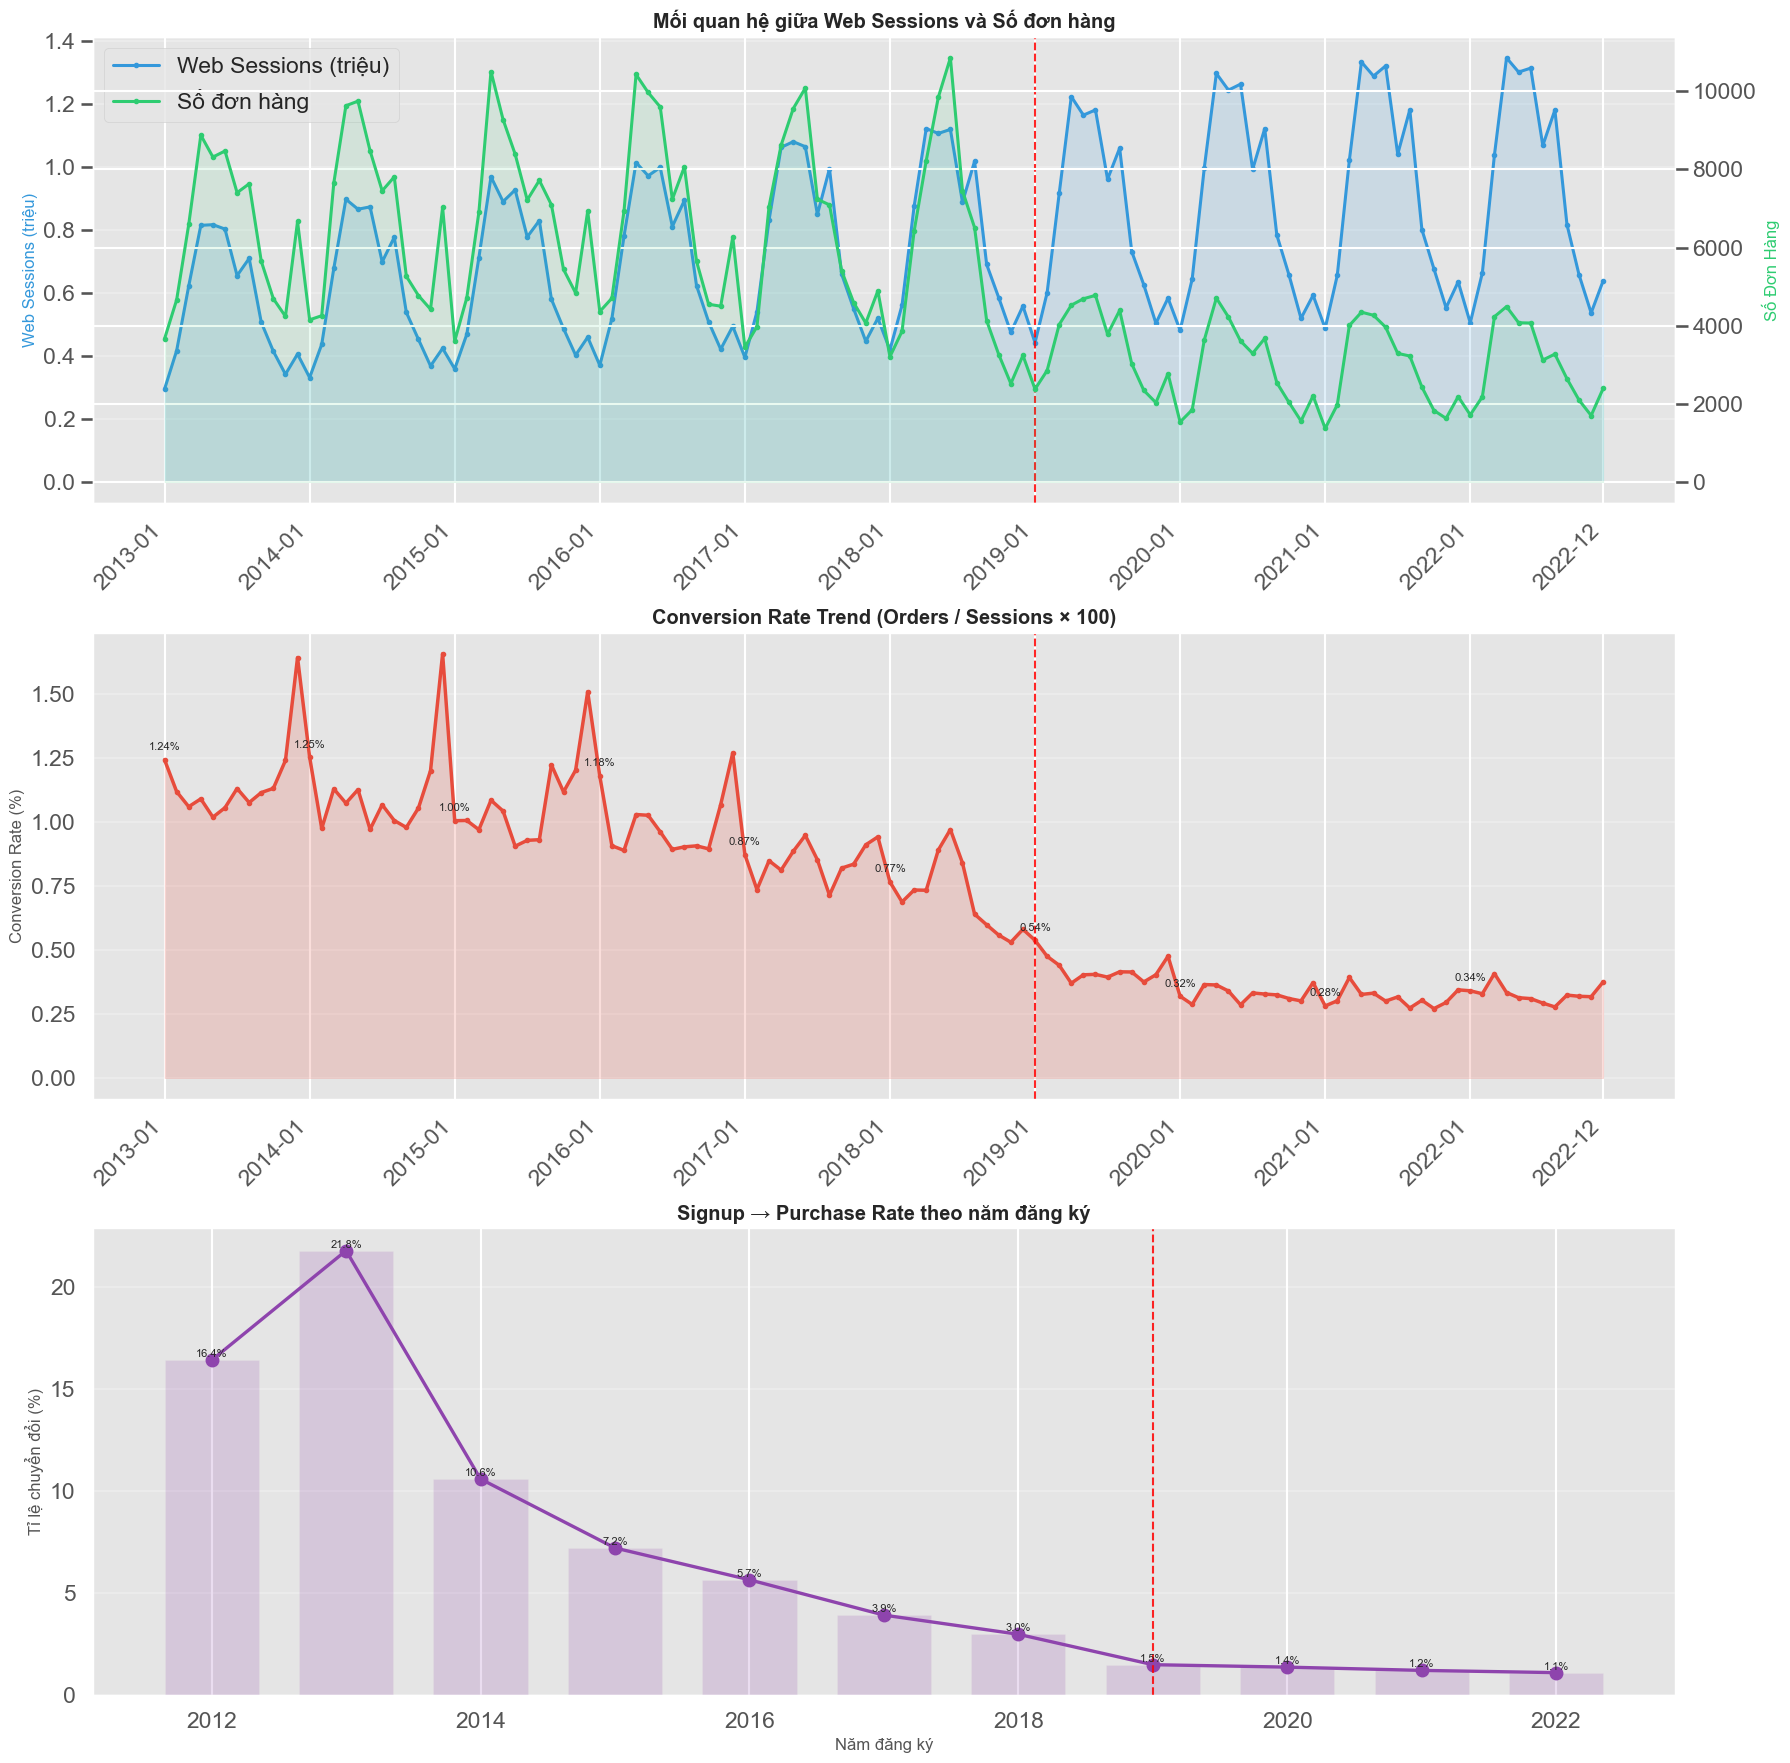

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print('\n' + '=' * 100)
print('PHÂN TÍCH KHẢ NĂNG CHUYỂN ĐỔI (CONVERSION)')
print('=' * 100)

# ----------------------------------------------------------------------
# 1) Bảng tổng hợp chuyển đổi theo năm
# ----------------------------------------------------------------------
traffic_yearly = web_traffic.copy()
traffic_yearly['year'] = traffic_yearly['date'].dt.year
traffic_yearly = traffic_yearly.groupby('year').agg({
    'sessions': 'sum',
    'unique_visitors': 'sum'
}).reset_index().sort_values('year')

orders_yearly_conv = orders[['order_id', 'customer_id', 'order_date']].dropna().copy()
orders_yearly_conv['year'] = orders_yearly_conv['order_date'].dt.year
orders_yearly_conv = orders_yearly_conv.groupby('year').agg({
    'order_id': 'nunique',
    'customer_id': 'nunique'
}).reset_index()
orders_yearly_conv.columns = ['year', 'orders', 'buying_customers']

conversion_yearly_summary = traffic_yearly.merge(orders_yearly_conv, on='year', how='inner').sort_values('year')
conversion_yearly_summary['conversion_rate_pct'] = (conversion_yearly_summary['orders'] / conversion_yearly_summary['sessions'] * 100).round(3)
conversion_yearly_summary['orders_per_1k_sessions'] = (conversion_yearly_summary['orders'] / conversion_yearly_summary['sessions'] * 1000).round(2)
conversion_yearly_summary['customers_per_1k_visitors'] = (conversion_yearly_summary['buying_customers'] / conversion_yearly_summary['unique_visitors'] * 1000).round(2)
conversion_yearly_summary['sessions'] = conversion_yearly_summary['sessions'].astype(int)
conversion_yearly_summary['unique_visitors'] = conversion_yearly_summary['unique_visitors'].astype(int)
conversion_yearly_summary['orders'] = conversion_yearly_summary['orders'].astype(int)
conversion_yearly_summary['buying_customers'] = conversion_yearly_summary['buying_customers'].astype(int)

# ----------------------------------------------------------------------
# 2) Signup → Purchase rate (annual cohort)
# ----------------------------------------------------------------------
signup_base = customers[['customer_id', 'signup_date']].dropna().drop_duplicates('customer_id').copy()
signup_base['signup_year'] = signup_base['signup_date'].dt.year

first_orders = orders[['customer_id', 'order_date']].dropna().copy()
first_orders = first_orders.groupby('customer_id')['order_date'].min().reset_index(name='first_order_date')

signup_purchase = signup_base.merge(first_orders, on='customer_id', how='left')
signup_purchase['ever_purchase'] = signup_purchase['first_order_date'].notna()
signup_purchase['same_year_purchase'] = signup_purchase['ever_purchase'] & (
    signup_purchase['first_order_date'].dt.year == signup_purchase['signup_year']
)

signup_summary = signup_purchase.groupby('signup_year').agg(
    signups=('customer_id', 'nunique'),
    same_year_purchases=('same_year_purchase', 'sum'),
    ever_purchases=('ever_purchase', 'sum')
).reset_index().sort_values('signup_year')
signup_summary['signup_to_purchase_rate_pct'] = (signup_summary['same_year_purchases'] / signup_summary['signups'] * 100).round(2)
signup_summary['ever_purchase_rate_pct'] = (signup_summary['ever_purchases'] / signup_summary['signups'] * 100).round(2)

# ----------------------------------------------------------------------
# 3) Hiển thị bảng tổng hợp toàn bộ giai đoạn
# ----------------------------------------------------------------------
display(
    conversion_yearly_summary.rename(columns={
        'year': 'Year',
        'sessions': 'Sessions',
        'unique_visitors': 'Unique Visitors',
        'orders': 'Orders',
        'buying_customers': 'Buying Customers',
        'conversion_rate_pct': 'Conversion Rate (%)',
        'orders_per_1k_sessions': 'Orders / 1K Sessions',
        'customers_per_1k_visitors': 'Customers / 1K Visitors',
    })
)

display(
    signup_summary.rename(columns={
        'signup_year': 'Signup Year',
        'signups': 'Signups',
        'same_year_purchases': 'Same-Year Purchases',
        'ever_purchases': 'Ever Purchases',
        'signup_to_purchase_rate_pct': 'Signup → Purchase Rate (%)',
        'ever_purchase_rate_pct': 'Ever Purchase Rate (%)',
    })
)

# ----------------------------------------------------------------------
# 4) Plot: 2 charts from screenshot + 1 extra chart
# ----------------------------------------------------------------------
traffic_monthly = web_traffic.copy()
traffic_monthly['month'] = traffic_monthly['date'].dt.to_period('M').dt.to_timestamp()
traffic_monthly = traffic_monthly.groupby('month').agg({
    'sessions': 'sum',
    'unique_visitors': 'sum'
}).reset_index()

orders_monthly = orders[['order_id', 'order_date', 'customer_id']].dropna().copy()
orders_monthly['month'] = orders_monthly['order_date'].dt.to_period('M').dt.to_timestamp()
orders_monthly = orders_monthly.groupby('month').agg({
    'order_id': 'nunique',
    'customer_id': 'nunique'
}).reset_index()
orders_monthly.columns = ['month', 'orders', 'active_customers']

conversion_monthly = traffic_monthly.merge(orders_monthly, on='month', how='inner').sort_values('month')
conversion_monthly['conversion_rate_pct'] = (conversion_monthly['orders'] / conversion_monthly['sessions']) * 100
conversion_monthly['month_index'] = range(len(conversion_monthly))

break_month = pd.Timestamp('2019-01-01')
if break_month in set(conversion_monthly['month']):
    break_idx = int(conversion_monthly.loc[conversion_monthly['month'] == break_month, 'month_index'].iloc[0])
else:
    break_idx = int(conversion_monthly.loc[conversion_monthly['month'] >= break_month, 'month_index'].min())

monthly_2018 = conversion_monthly[conversion_monthly['month'].dt.year == 2018]
monthly_2019 = conversion_monthly[conversion_monthly['month'].dt.year == 2019]

conv_2018 = monthly_2018['conversion_rate_pct'].mean()
conv_2019 = monthly_2019['conversion_rate_pct'].mean()
conv_change_pct = ((conv_2019 - conv_2018) / conv_2018) * 100 if pd.notna(conv_2018) and conv_2018 != 0 else np.nan

orders_2018 = monthly_2018['orders'].mean()
orders_2019 = monthly_2019['orders'].mean()
orders_change_pct = ((orders_2019 - orders_2018) / orders_2018) * 100 if pd.notna(orders_2018) and orders_2018 != 0 else np.nan

sessions_2018 = monthly_2018['sessions'].mean()
sessions_2019 = monthly_2019['sessions'].mean()
sessions_change_pct = ((sessions_2019 - sessions_2018) / sessions_2018) * 100 if pd.notna(sessions_2018) and sessions_2018 != 0 else np.nan

fig, axes = plt.subplots(3, 1, figsize=(18, 18), sharex=False)


# Chart 1: Traffic vs Orders
ax = axes[0]
ax2 = ax.twinx()
ax.plot(conversion_monthly['month_index'], conversion_monthly['sessions'] / 1e6, color='#3498db', linewidth=2.2, marker='o', markersize=3, label='Web Sessions (triệu)')
ax2.plot(conversion_monthly['month_index'], conversion_monthly['orders'], color='#2ecc71', linewidth=2.2, marker='o', markersize=3, label='Số đơn hàng')
ax.fill_between(conversion_monthly['month_index'], conversion_monthly['sessions'] / 1e6, color='#3498db', alpha=0.15)
ax2.fill_between(conversion_monthly['month_index'], conversion_monthly['orders'], color='#2ecc71', alpha=0.10)
ax.set_title('Mối quan hệ giữa Web Sessions và Số đơn hàng', fontweight='bold')
ax.set_ylabel('Web Sessions (triệu)', color='#3498db')
ax2.set_ylabel('Số Đơn Hàng', color='#2ecc71')
ax.grid(axis='y', alpha=0.25)
ax.axvline(break_idx, color='red', linestyle='--', linewidth=1.5, alpha=0.85)

xticks = list(range(0, len(conversion_monthly), 12))
if conversion_monthly['month_index'].iloc[-1] not in xticks:
    xticks.append(int(conversion_monthly['month_index'].iloc[-1]))
ax.set_xticks(xticks)
ax.set_xticklabels([conversion_monthly.loc[conversion_monthly['month_index'] == x, 'month'].iloc[0].strftime('%Y-%m') for x in xticks], rotation=45, ha='right')
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

# Chart 2: Conversion rate trend
ax = axes[1]
ax.plot(conversion_monthly['month_index'], conversion_monthly['conversion_rate_pct'], color='#e74c3c', linewidth=2.5, marker='o', markersize=3)
ax.fill_between(conversion_monthly['month_index'], conversion_monthly['conversion_rate_pct'], color='#e74c3c', alpha=0.18)
ax.axvline(break_idx, color='red', linestyle='--', linewidth=1.5, alpha=0.85)
ax.set_title('Conversion Rate Trend (Orders / Sessions × 100)', fontweight='bold')
ax.set_ylabel('Conversion Rate (%)')
ax.grid(axis='y', alpha=0.25)
ax.set_xticks(xticks)
ax.set_xticklabels([conversion_monthly.loc[conversion_monthly['month_index'] == x, 'month'].iloc[0].strftime('%Y-%m') for x in xticks], rotation=45, ha='right')
for idx, row in conversion_monthly.iloc[::12].iterrows():
    ax.text(row['month_index'], row['conversion_rate_pct'] + 0.03, f"{row['conversion_rate_pct']:.2f}%", ha='center', va='bottom', fontsize=8)

# Chart 3: Signup → Purchase rate
ax = axes[2]
ax.plot(signup_summary['signup_year'], signup_summary['signup_to_purchase_rate_pct'], color='#8e44ad', linewidth=2.4, marker='o')
ax.bar(signup_summary['signup_year'], signup_summary['signup_to_purchase_rate_pct'], color='#8e44ad', alpha=0.18, width=0.7)
ax.axvline(2019, color='red', linestyle='--', linewidth=1.5, alpha=0.85)
ax.set_title('Signup → Purchase Rate theo năm đăng ký', fontweight='bold')
ax.set_xlabel('Năm đăng ký')
ax.set_ylabel('Tỉ lệ chuyển đổi (%)')
ax.grid(axis='y', alpha=0.25)
for _, row in signup_summary.iterrows():
    ax.text(row['signup_year'], row['signup_to_purchase_rate_pct'] + 0.05, f"{row['signup_to_purchase_rate_pct']:.1f}%", ha='center', va='bottom', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()


Tuy nhiên, khi chuyển sang hiệu quả chuyển đổi, bức tranh hoàn toàn đảo ngược. Conversion rate giảm liên tục từ 1.13% (2013) xuống chỉ còn 0.416% (2019), tức giảm hơn 60% trong vòng 6 năm, và tiếp tục giảm xuống ~0.31–0.33% trong giai đoạn 2020–2022. Tương tự, số đơn hàng trên mỗi 1,000 sessions giảm mạnh từ 11.3 xuống chỉ còn ~3.2, và số khách mua trên mỗi 1,000 visitors cũng giảm từ 7.62 xuống ~2.9. Điều này cho thấy lượng traffic tăng thêm không chuyển hóa thành hành vi mua hàng, phản ánh sự suy yếu nghiêm trọng của funnel từ “truy cập → mua hàng”.

Phân tích sâu hơn về hành vi đăng ký và mua hàng, số lượng người đăng ký mới tăng rất mạnh từ 957 (2012) lên hơn 21,000 (2022). Tuy nhiên, tỷ lệ chuyển đổi từ signup sang mua hàng trong cùng năm lại giảm mạnh từ ~16–22% xuống chỉ còn ~1–1.5% sau năm 2019. Đây là một tín hiệu cực kỳ quan trọng: doanh nghiệp vẫn thu hút được người dùng mới, nhưng không thể chuyển họ thành khách hàng thực sự. Trong khi đó, tỷ lệ “ever purchase” (~74%) vẫn ổn định, cho thấy vấn đề không nằm ở việc khách không bao giờ mua, mà là họ không mua ngay hoặc không bị thuyết phục đủ sớm.


----------------------------------------------------------------------------------------------------
Mid-Funnel Engagement Summary by Year (Full Period 2013-2022)
----------------------------------------------------------------------------------------------------


,Year,Sessions,Unique Visitors,Page Views,Bounce Rate (%),Avg Session Duration (min),Page Views/Session
0,2013,6801940,5166501,29403658,0.46,3.43,4.32
1,2014,7340960,5596248,31947207,0.45,3.53,4.35
2,2015,7861938,5962192,34175895,0.44,3.62,4.35
3,2016,8403399,6393654,36322275,0.44,3.42,4.32
4,2017,8992602,6818372,38785941,0.44,3.48,4.31
5,2018,9415085,7143496,41461837,0.45,3.45,4.40
6,2019,9990148,7580565,42927110,0.45,3.46,4.30
7,2020,10591082,8065367,46146457,0.45,3.53,4.36
8,2021,10991725,8367014,47760867,0.45,3.49,4.35
9,2022,11063658,8409280,47731553,0.45,3.54,4.31


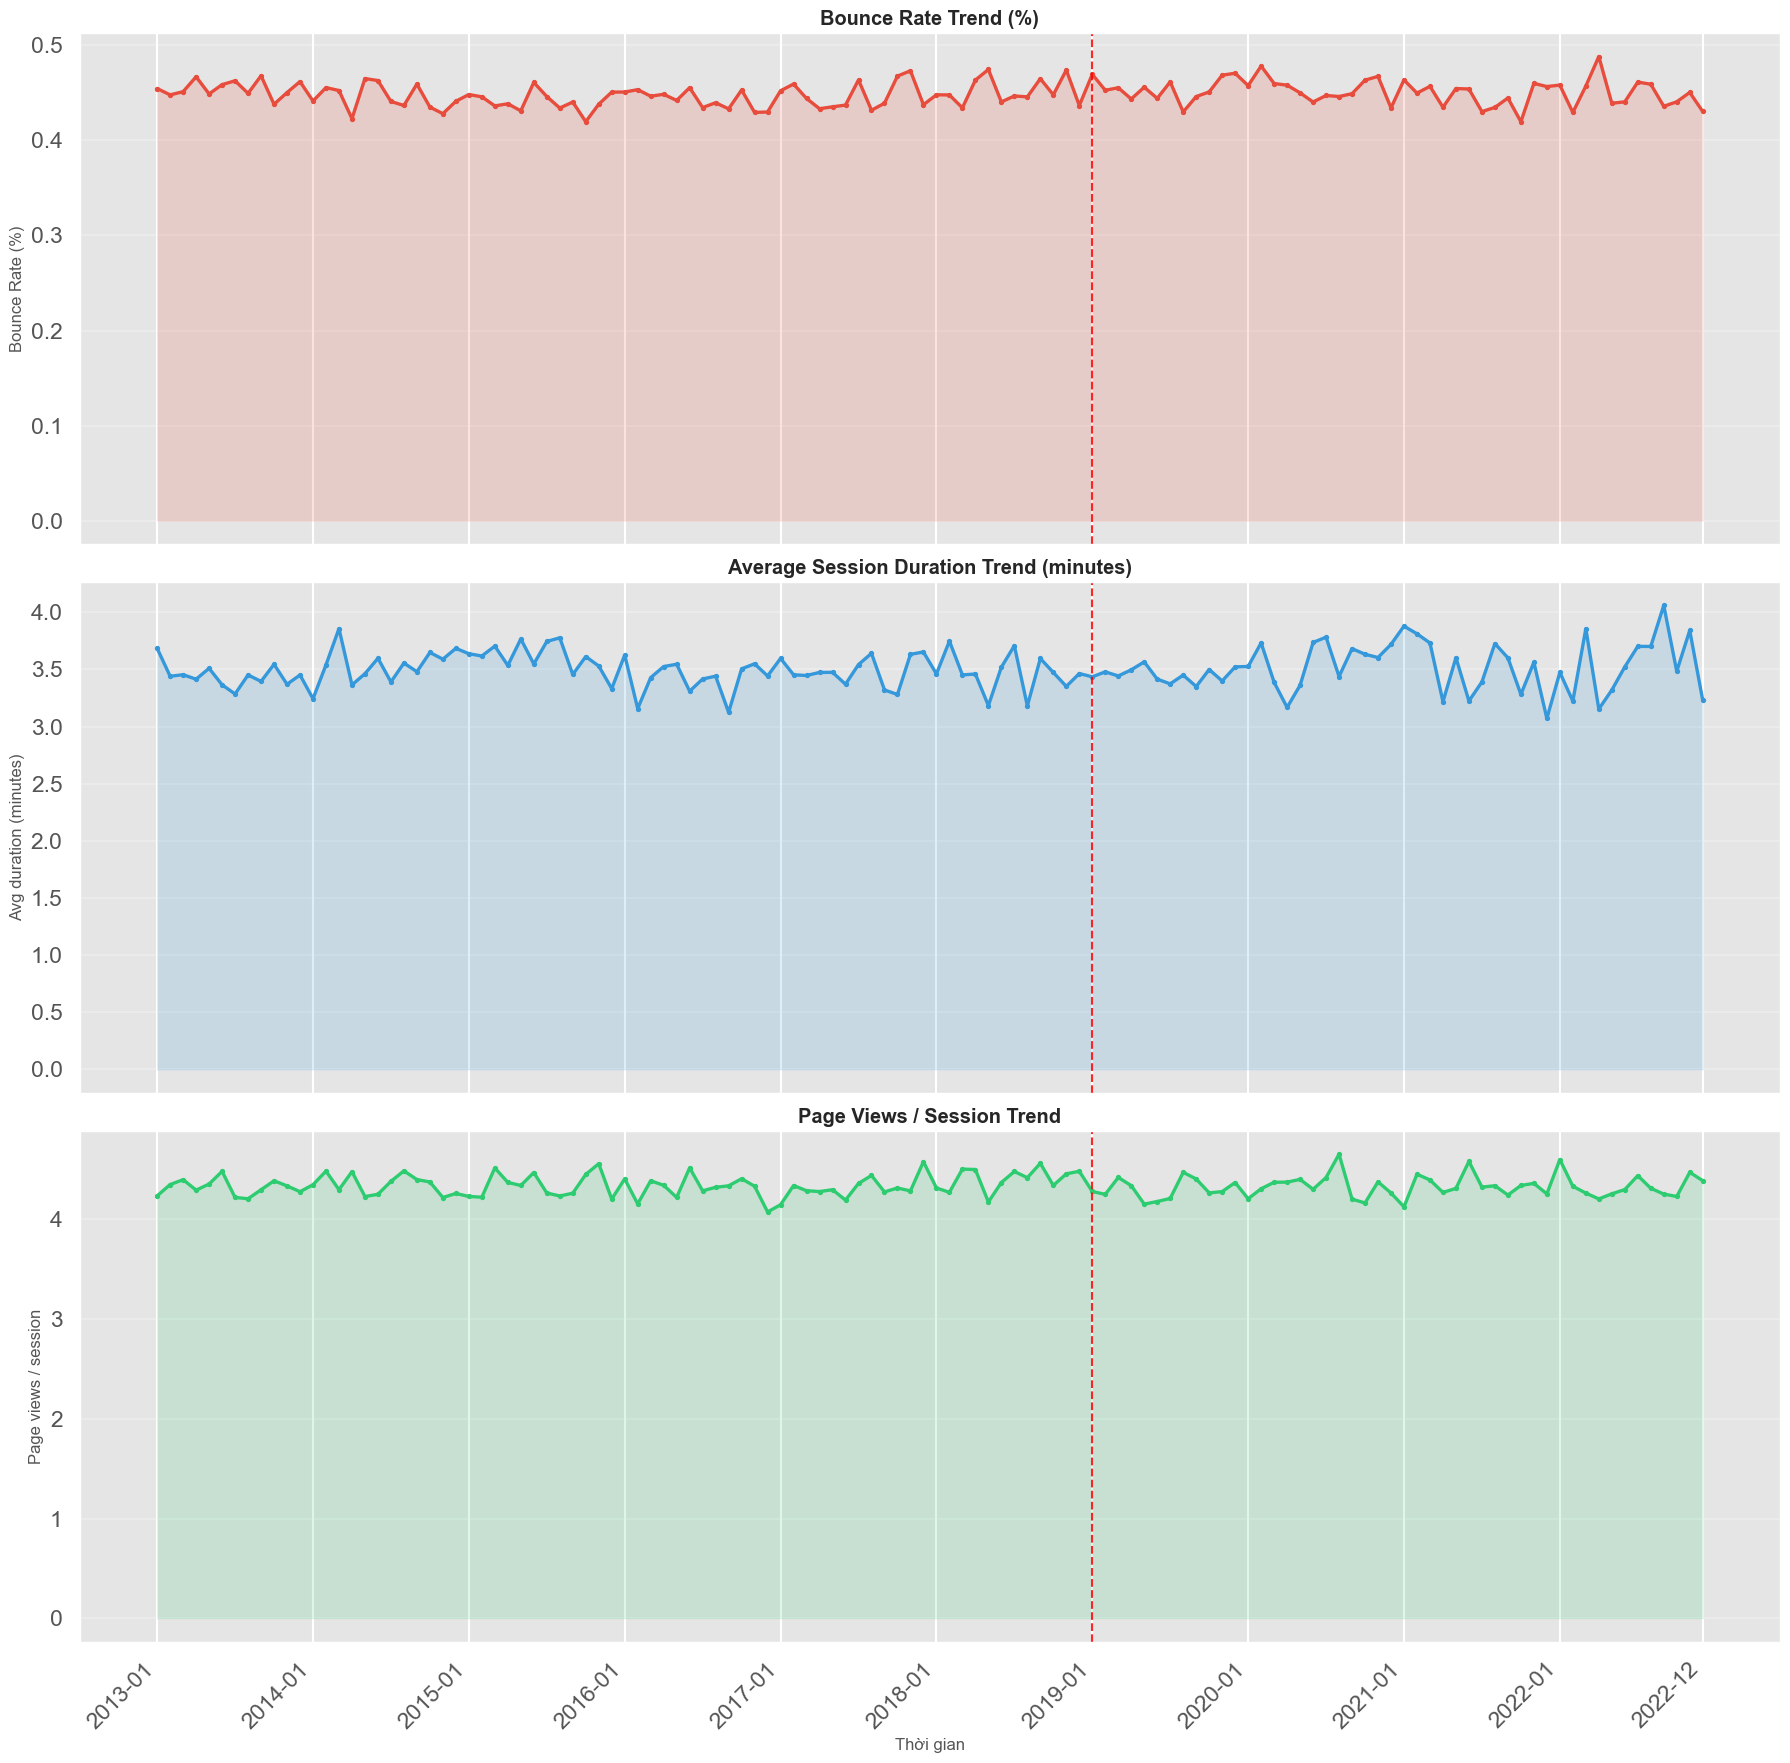

In [60]:

traffic_mid = web_traffic.copy()
traffic_mid['month'] = traffic_mid['date'].dt.to_period('M').dt.to_timestamp()

# Weighted aggregation theo tháng để phản ánh chính xác hơn
monthly_mid = traffic_mid.groupby('month').apply(
    lambda g: pd.Series({
        'sessions': g['sessions'].sum(),
        'unique_visitors': g['unique_visitors'].sum(),
        'page_views': g['page_views'].sum(),
        'bounce_rate': np.average(g['bounce_rate'], weights=g['sessions']) if g['sessions'].sum() > 0 else np.nan,
        'avg_session_duration_sec': np.average(g['avg_session_duration_sec'], weights=g['sessions']) if g['sessions'].sum() > 0 else np.nan,
    })
).reset_index()

monthly_mid['page_views_per_session'] = monthly_mid['page_views'] / monthly_mid['sessions']
monthly_mid['month_index'] = range(len(monthly_mid))
monthly_mid['year'] = monthly_mid['month'].dt.year

# Calculate annual mid-funnel summary (weighted by sessions)
annual_mid_summary = monthly_mid.groupby('year').apply(
    lambda g: pd.Series({
        'sessions': g['sessions'].sum(),
        'unique_visitors': g['unique_visitors'].sum(),
        'page_views': g['page_views'].sum(),
        'bounce_rate_pct': np.average(g['bounce_rate'], weights=g['sessions']) * 100 if g['sessions'].sum() > 0 else np.nan,
        'avg_session_duration_min': np.average(g['avg_session_duration_sec'], weights=g['sessions']) / 60 if g['sessions'].sum() > 0 else np.nan,
        'page_views_per_session': np.average(g['page_views_per_session'], weights=g['sessions']) if g['sessions'].sum() > 0 else np.nan,
    })
).reset_index()

# Display full-period mid-funnel summary table
print('\n' + '-' * 100)
print('Mid-Funnel Engagement Summary by Year (Full Period 2013-2022)')
print('-' * 100)
display_table = annual_mid_summary.copy()
display_table.columns = ['Year', 'Sessions', 'Unique Visitors', 'Page Views', 'Bounce Rate (%)', 'Avg Session Duration (min)', 'Page Views/Session']
display_table['Year'] = display_table['Year'].astype(int)
display_table['Sessions'] = display_table['Sessions'].astype(int)
display_table['Unique Visitors'] = display_table['Unique Visitors'].astype(int)
display_table['Page Views'] = display_table['Page Views'].astype(int)
display_table['Bounce Rate (%)'] = display_table['Bounce Rate (%)'].round(2)
display_table['Avg Session Duration (min)'] = display_table['Avg Session Duration (min)'].round(2)
display_table['Page Views/Session'] = display_table['Page Views/Session'].round(2)
display(display_table)

break_month = pd.Timestamp('2019-01-01')
if break_month in set(monthly_mid['month']):
    break_idx = int(monthly_mid.loc[monthly_mid['month'] == break_month, 'month_index'].iloc[0])
else:
    break_idx = int(monthly_mid.loc[monthly_mid['month'] >= break_month, 'month_index'].min())

# ----------------------------------------------------------------------
# Tóm tắt 2018 vs 2019
# ----------------------------------------------------------------------
mid_2018 = monthly_mid[monthly_mid['year'] == 2018]
mid_2019 = monthly_mid[monthly_mid['year'] == 2019]

bounce_2018 = mid_2018['bounce_rate'].mean()
bounce_2019 = mid_2019['bounce_rate'].mean()
bounce_change_pct = ((bounce_2019 - bounce_2018) / bounce_2018) * 100 if pd.notna(bounce_2018) and bounce_2018 != 0 else np.nan

duration_2018 = mid_2018['avg_session_duration_sec'].mean()
duration_2019 = mid_2019['avg_session_duration_sec'].mean()
duration_change_pct = ((duration_2019 - duration_2018) / duration_2018) * 100 if pd.notna(duration_2018) and duration_2018 != 0 else np.nan

pps_2018 = mid_2018['page_views_per_session'].mean()
pps_2019 = mid_2019['page_views_per_session'].mean()
pps_change_pct = ((pps_2019 - pps_2018) / pps_2018) * 100 if pd.notna(pps_2018) and pps_2018 != 0 else np.nan



# ----------------------------------------------------------------------
# Vẽ biểu đồ
# ----------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(18, 18), sharex=True)

# 1) Bounce rate
ax = axes[0]
ax.plot(monthly_mid['month_index'], monthly_mid['bounce_rate'] * 100, color='#e74c3c', linewidth=2.4, marker='o', markersize=2.8)
ax.fill_between(monthly_mid['month_index'], monthly_mid['bounce_rate'] * 100, color='#e74c3c', alpha=0.16)
ax.axvline(break_idx, color='red', linestyle='--', linewidth=1.5, alpha=0.85)
ax.set_title('Bounce Rate Trend (%)', fontweight='bold')
ax.set_ylabel('Bounce Rate (%)')
ax.grid(axis='y', alpha=0.25)

# 2) Avg session duration
ax = axes[1]
ax.plot(monthly_mid['month_index'], monthly_mid['avg_session_duration_sec'] / 60, color='#3498db', linewidth=2.4, marker='o', markersize=2.8)
ax.fill_between(monthly_mid['month_index'], monthly_mid['avg_session_duration_sec'] / 60, color='#3498db', alpha=0.16)
ax.axvline(break_idx, color='red', linestyle='--', linewidth=1.5, alpha=0.85)
ax.set_title('Average Session Duration Trend (minutes)', fontweight='bold')
ax.set_ylabel('Avg duration (minutes)')
ax.grid(axis='y', alpha=0.25)

# 3) Page views / session
ax = axes[2]
ax.plot(monthly_mid['month_index'], monthly_mid['page_views_per_session'], color='#2ecc71', linewidth=2.4, marker='o', markersize=2.8)
ax.fill_between(monthly_mid['month_index'], monthly_mid['page_views_per_session'], color='#2ecc71', alpha=0.16)
ax.axvline(break_idx, color='red', linestyle='--', linewidth=1.5, alpha=0.85)
ax.set_title('Page Views / Session Trend', fontweight='bold')
ax.set_ylabel('Page views / session')
ax.set_xlabel('Thời gian')
ax.grid(axis='y', alpha=0.25)

# X ticks mỗi 12 tháng
xticks = list(range(0, len(monthly_mid), 12))
if monthly_mid['month_index'].iloc[-1] not in xticks:
    xticks.append(int(monthly_mid['month_index'].iloc[-1]))
labels = [monthly_mid.loc[monthly_mid['month_index'] == x, 'month'].iloc[0].strftime('%Y-%m') for x in xticks]
axes[2].set_xticks(xticks)
axes[2].set_xticklabels(labels, rotation=45, ha='right')
axes[0].set_xticks(xticks)
axes[1].set_xticks(xticks)

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()




Cuối cùng, các chỉ số về chất lượng traffic như bounce rate (~45%), thời gian phiên (~3.4–3.5 phút) và số trang xem mỗi phiên (~4.3) gần như không thay đổi theo thời gian, kể cả tại năm 2019. Điều này cho thấy hành vi duyệt web của người dùng không xấu đi, và traffic mang về vẫn có chất lượng tương đương trước đó.

Dựa trên các chỉ số về traffic, chuyển đổi và hành vi người dùng, có thể thấy một nghịch lý rất rõ ràng: nhu cầu (traffic) vẫn tăng trưởng đều, nhưng khả năng chuyển đổi thành doanh thu lại suy giảm nghiêm trọng — và đây chính là một trong những nguyên nhân cốt lõi của cú sụt giảm năm 2019.

Tổng hợp lại, có thể rút ra một kết luận quan trọng: vấn đề không nằm ở việc thiếu nhu cầu, mà nằm ở việc không chuyển hóa được nhu cầu thành doanh thu. Nói cách khác, doanh nghiệp vẫn “kéo được người vào”, nhưng không “bán được hàng” — phản ánh sự đứt gãy trong funnel chuyển đổi, đặc biệt ở giai đoạn từ quan tâm đến quyết định mua. Đây là một nguyên nhân mang tính hệ thống, đã diễn ra liên tục trong nhiều năm và trở nên nghiêm trọng vào năm 2019. Đây là xu hướng giảm 10 năm liên tục, không phải cú sốc đột ngột — nghĩa là dấu hiệu đã xuất hiện từ rất sớm nhưng không được xử lý.

#### 5.4 Phân tích cơ cấu sản phẩm (Product)

Tiếp theo, sau khi đã xác định doanh nghiệp không gặp vấn đề về chất lượng dịch vụ cũng như đã làm rõ hai yếu tố quan trọng là mất khách hàng và suy giảm hiệu quả chuyển đổi, phần này sẽ tập trung vào yếu tố thứ ba: cơ cấu danh mục sản phẩm. Mục tiêu là kiểm tra liệu sự sụt giảm doanh thu có bắt nguồn từ việc các dòng sản phẩm chủ lực suy yếu mà không có danh mục nào đủ sức thay thế hay không.


5.4.1 PRODUCT MIX STRUCTURE: QUY MÔ & CƠ CẤU DANH MỤC

----------------------------------------------------------------------------------------------------
Bảng 1 - Revenue by Category by Year (Full Period)
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
Bảng 1 - Revenue by Category by Year (Full Period)
----------------------------------------------------------------------------------------------------


category,year,Casual,GenZ,Outdoor,Streetwear
0,2012,11728538,9510543,162172120,558086547
1,2013,29035897,26837811,328124850,1273170859
2,2014,31996441,29478556,355553779,1454817107
3,2015,39310583,38053113,339356806,1473213326
4,2016,45987758,39338506,324900890,1694413523
5,2017,52189593,38679259,296978970,1523316503
6,2018,70642098,57863083,207343077,1514274198
7,2019,43640563,25785923,148423120,918951836
8,2020,36698992,22018663,121226276,874568229
9,2021,45303640,26622965,105160247,865952968



----------------------------------------------------------------------------------------------------
Bảng 2 - Category Revenue Share (%) by Year (Full Period)
----------------------------------------------------------------------------------------------------


category,year,Casual,GenZ,Outdoor,Streetwear
0,2012,1.58,1.28,21.87,75.26
1,2013,1.75,1.62,19.80,76.83
2,2014,1.71,1.57,18.99,77.72
3,2015,2.08,2.01,17.96,77.95
4,2016,2.19,1.87,15.44,80.51
5,2017,2.73,2.02,15.54,79.71
6,2018,3.82,3.13,11.21,81.85
7,2019,3.84,2.27,13.06,80.84
8,2020,3.48,2.09,11.50,82.94
9,2021,4.34,2.55,10.08,83.02



----------------------------------------------------------------------------------------------------
Bảng 3 - Segment Revenue Share (%) by Year (Full Period)
----------------------------------------------------------------------------------------------------


segment,year,Activewear,All-weather,Balanced,Everyday,Performance,Premium,Standard,Trendy
0,2012,18.36,1.58,26.33,36.72,10.63,3.51,1.58,1.28
1,2013,16.69,1.75,23.96,37.95,13.30,3.11,1.62,1.62
2,2014,16.28,1.70,23.94,37.91,14.54,2.72,1.32,1.57
3,2015,14.98,2.02,25.61,35.18,15.78,3.04,1.39,2.01
4,2016,11.80,2.13,26.87,36.06,16.44,3.70,1.13,1.87
5,2017,12.60,2.60,29.47,32.18,16.79,3.06,1.26,2.02
6,2018,9.63,3.27,30.01,33.31,17.13,2.13,1.39,3.13
7,2019,10.93,3.39,36.45,28.59,14.26,2.57,1.54,2.27
8,2020,8.80,3.13,42.78,26.47,12.12,3.04,1.56,2.09
9,2021,8.16,3.99,46.22,24.38,10.56,2.29,1.87,2.55



----------------------------------------------------------------------------------------------------
Bảng 4 - Concentration Indicators (Top-1, Top-2, HHI)
----------------------------------------------------------------------------------------------------


,year,top1_category,top1_share_pct,top2_share_pct,hhi
0,2012,Streetwear,75.26,97.13,6146.0
1,2013,Streetwear,76.83,96.63,6301.0
2,2014,Streetwear,77.72,96.71,6406.0
3,2015,Streetwear,77.95,95.91,6407.0
4,2016,Streetwear,80.51,95.95,6729.0
5,2017,Streetwear,79.71,95.25,6607.0
6,2018,Streetwear,81.85,93.06,6849.0
7,2019,Streetwear,80.84,93.90,6726.0
8,2020,Streetwear,82.94,94.44,7028.0
9,2021,Streetwear,83.02,93.10,7019.0


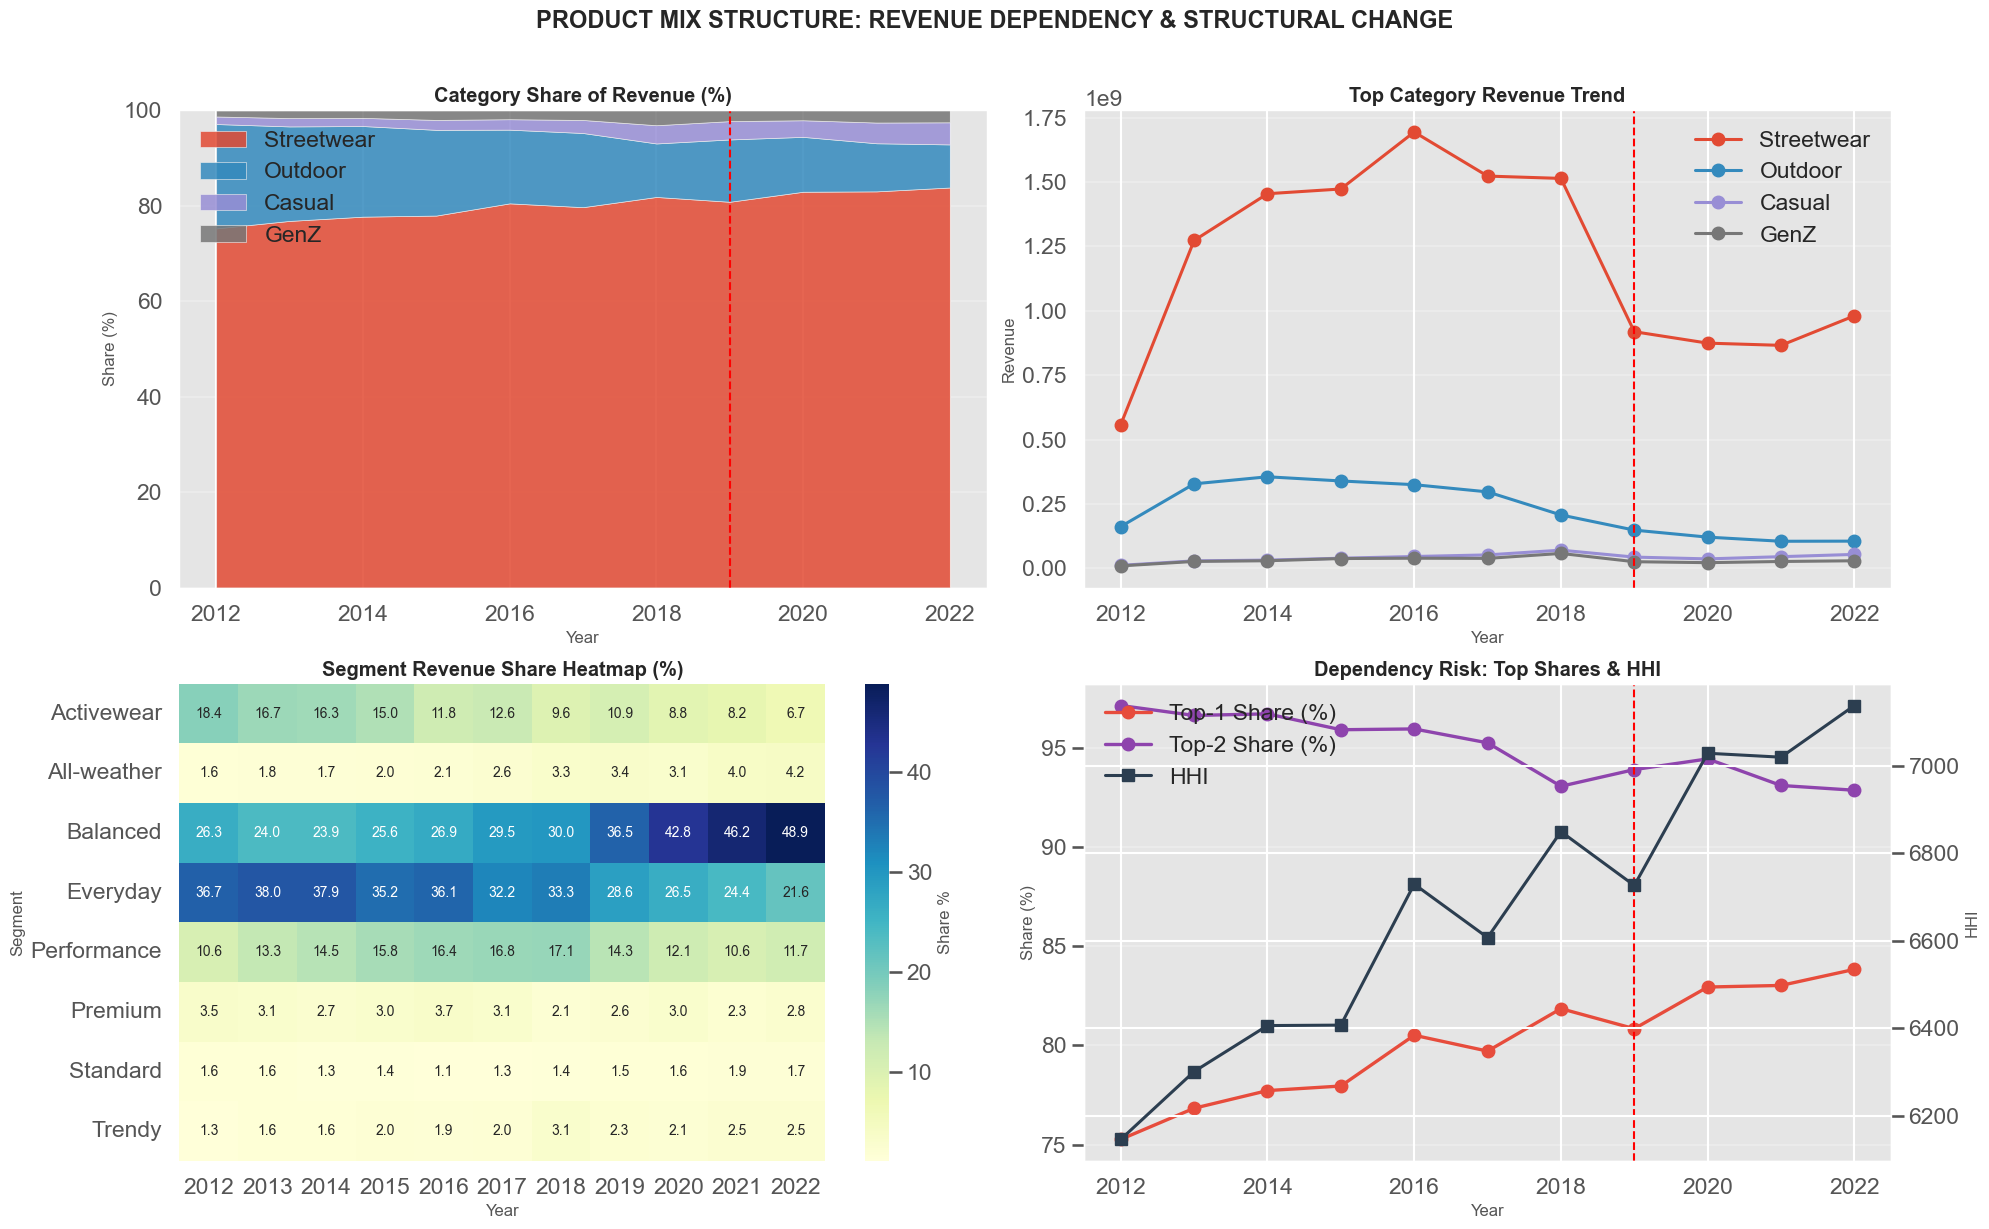

In [64]:
print('\n' + '=' * 100)
print('5.4.1 PRODUCT MIX STRUCTURE: QUY MÔ & CƠ CẤU DANH MỤC')
print('=' * 100)

# ----------------------------------------------------------------------
# 1) Chuẩn bị dữ liệu doanh thu theo order-item
# ----------------------------------------------------------------------
mix_items = order_items.copy()
mix_orders = orders[['order_id', 'order_date']].dropna(subset=['order_id', 'order_date']).copy()
mix_orders['year'] = mix_orders['order_date'].dt.year

if 'quantity' in mix_items.columns:
    qty = pd.to_numeric(mix_items['quantity'], errors='coerce').fillna(0)
else:
    qty = pd.Series(1, index=mix_items.index)

if 'unit_price' in mix_items.columns:
    price = pd.to_numeric(mix_items['unit_price'], errors='coerce').fillna(0)
    line_revenue = qty * price if 'quantity' in mix_items.columns else price
elif 'price' in mix_items.columns:
    price = pd.to_numeric(mix_items['price'], errors='coerce').fillna(0)
    line_revenue = qty * price if 'quantity' in mix_items.columns else price
else:
    line_revenue = pd.Series(np.nan, index=mix_items.index)

mix_items['line_revenue'] = line_revenue

mix_base = mix_items.merge(mix_orders[['order_id', 'year']], on='order_id', how='inner')

# Merge product attributes (category/segment) if available
if 'product_id' in mix_base.columns and 'product_id' in products.columns:
    product_cols = ['product_id'] + [c for c in ['category', 'segment'] if c in products.columns]
    mix_base = mix_base.merge(products[product_cols].drop_duplicates('product_id'), on='product_id', how='left')

# Fallback column names if category/segment differ
category_col = 'category' if 'category' in mix_base.columns else None
segment_col = 'segment' if 'segment' in mix_base.columns else None

if category_col is None:
    for c in ['product_category', 'cat', 'group']:
        if c in mix_base.columns:
            category_col = c
            break

if segment_col is None:
    for c in ['product_segment', 'sub_category', 'subsegment', 'segment_name']:
        if c in mix_base.columns:
            segment_col = c
            break

if category_col is None:
    mix_base['category_fallback'] = 'All Products'
    category_col = 'category_fallback'

if segment_col is None:
    mix_base['segment_fallback'] = 'Unknown Segment'
    segment_col = 'segment_fallback'

mix_base[category_col] = mix_base[category_col].fillna('Unknown Category')
mix_base[segment_col] = mix_base[segment_col].fillna('Unknown Segment')

# Nếu line_revenue thiếu hoàn toàn thì fallback theo sales table
if mix_base['line_revenue'].isna().all() or np.isclose(mix_base['line_revenue'].fillna(0).sum(), 0):
    if {'order_id', 'sales_amount'}.issubset(sales.columns):
        sales_tmp = sales[['order_id', 'sales_amount']].copy()
        sales_tmp['sales_amount'] = pd.to_numeric(sales_tmp['sales_amount'], errors='coerce').fillna(0)
        mix_base = mix_base.drop(columns=['line_revenue']).merge(sales_tmp, on='order_id', how='left')
        mix_base['line_revenue'] = mix_base['sales_amount'].fillna(0)
    elif {'order_id', 'revenue'}.issubset(sales.columns):
        sales_tmp = sales[['order_id', 'revenue']].copy()
        sales_tmp['revenue'] = pd.to_numeric(sales_tmp['revenue'], errors='coerce').fillna(0)
        mix_base = mix_base.drop(columns=['line_revenue']).merge(sales_tmp, on='order_id', how='left')
        mix_base['line_revenue'] = mix_base['revenue'].fillna(0)
    else:
        raise ValueError('Không tìm thấy cột doanh thu phù hợp để tính Product Mix (cần unit_price/price hoặc sales_amount/revenue).')

# ----------------------------------------------------------------------
# 2) Tổng hợp doanh thu theo Category / Segment theo năm
# ----------------------------------------------------------------------
annual_category = (
    mix_base.groupby(['year', category_col], as_index=False)['line_revenue']
    .sum()
    .rename(columns={category_col: 'category', 'line_revenue': 'revenue'})
)
annual_segment = (
    mix_base.groupby(['year', segment_col], as_index=False)['line_revenue']
    .sum()
    .rename(columns={segment_col: 'segment', 'line_revenue': 'revenue'})
)

annual_total = annual_category.groupby('year', as_index=False)['revenue'].sum().rename(columns={'revenue': 'total_revenue'})
annual_category = annual_category.merge(annual_total, on='year', how='left')
annual_category['share_pct'] = (annual_category['revenue'] / annual_category['total_revenue'] * 100).round(2)

annual_segment = annual_segment.merge(annual_total, on='year', how='left')
annual_segment['share_pct'] = (annual_segment['revenue'] / annual_segment['total_revenue'] * 100).round(2)

# Bảng pivot để quan sát đầy đủ toàn kỳ
category_revenue_pivot = annual_category.pivot(index='year', columns='category', values='revenue').fillna(0)
category_share_pivot = annual_category.pivot(index='year', columns='category', values='share_pct').fillna(0)
segment_share_pivot = annual_segment.pivot(index='year', columns='segment', values='share_pct').fillna(0)

# Chỉ số tập trung danh mục: Top1, Top2, HHI
concentration_rows = []
for year, g in annual_category.groupby('year'):
    g_sorted = g.sort_values('share_pct', ascending=False).reset_index(drop=True)
    top1_cat = g_sorted.loc[0, 'category'] if len(g_sorted) > 0 else None
    top1_share = g_sorted.loc[0, 'share_pct'] if len(g_sorted) > 0 else np.nan
    top2_share = g_sorted['share_pct'].head(2).sum()
    hhi = ((g_sorted['share_pct'] / 100) ** 2).sum() * 10000
    concentration_rows.append({
        'year': int(year),
        'top1_category': top1_cat,
        'top1_share_pct': round(float(top1_share), 2),
        'top2_share_pct': round(float(top2_share), 2),
        'hhi': round(float(hhi), 0)
    })

concentration = pd.DataFrame(concentration_rows).sort_values('year').reset_index(drop=True)

# ----------------------------------------------------------------------
# 3) Hiển thị bảng tổng hợp (full-period)
# ----------------------------------------------------------------------
print('\n' + '-' * 100)
print('Bảng 1 - Revenue by Category by Year (Full Period)')
print('-' * 100)
display(category_revenue_pivot.round(0).astype(int).reset_index())

print('\n' + '-' * 100)
print('Bảng 2 - Category Revenue Share (%) by Year (Full Period)')
print('-' * 100)
display(category_share_pivot.round(2).reset_index())

print('\n' + '-' * 100)
print('Bảng 3 - Segment Revenue Share (%) by Year (Full Period)')
print('-' * 100)
display(segment_share_pivot.round(2).reset_index())

print('\n' + '-' * 100)
print('Bảng 4 - Concentration Indicators (Top-1, Top-2, HHI)')
print('-' * 100)
display(concentration)

# ----------------------------------------------------------------------
# 4) Vẽ biểu đồ Product Mix
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('PRODUCT MIX STRUCTURE: REVENUE DEPENDENCY & STRUCTURAL CHANGE', fontsize=17, fontweight='bold', y=1.02)

years = sorted(category_share_pivot.index.tolist())
break_year = 2019

# (1) Category share stacked area
ax = axes[0, 0]
stack_df = category_share_pivot.copy()
stack_df = stack_df[stack_df.mean().sort_values(ascending=False).index]
ax.stackplot(stack_df.index, [stack_df[c].values for c in stack_df.columns], labels=stack_df.columns, alpha=0.85)
ax.axvline(break_year, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Category Share of Revenue (%)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Share (%)')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.25)
if stack_df.shape[1] <= 8:
    ax.legend(loc='upper left', frameon=False)

# (2) Top categories revenue trend
ax = axes[0, 1]
top_cats = category_revenue_pivot.sum().sort_values(ascending=False).head(5).index.tolist()
for cat in top_cats:
    ax.plot(category_revenue_pivot.index, category_revenue_pivot[cat], marker='o', linewidth=2.2, label=cat)
ax.axvline(break_year, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Top Category Revenue Trend', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Revenue')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)

# (3) Segment share heatmap (top segments)
ax = axes[1, 0]
seg_heat = segment_share_pivot.copy()
if seg_heat.shape[1] > 8:
    top_seg = seg_heat.mean().sort_values(ascending=False).head(8).index
    seg_heat = seg_heat[top_seg]
sns.heatmap(seg_heat.T, cmap='YlGnBu', annot=True, fmt='.1f', cbar_kws={'label': 'Share %'}, ax=ax)
ax.set_title('Segment Revenue Share Heatmap (%)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Segment')

# (4) Concentration risk trend
ax = axes[1, 1]
ax.plot(concentration['year'], concentration['top1_share_pct'], marker='o', linewidth=2.4, color='#e74c3c', label='Top-1 Share (%)')
ax.plot(concentration['year'], concentration['top2_share_pct'], marker='o', linewidth=2.4, color='#8e44ad', label='Top-2 Share (%)')
ax2 = ax.twinx()
ax2.plot(concentration['year'], concentration['hhi'], marker='s', linewidth=2.2, color='#2c3e50', label='HHI')
ax.axvline(break_year, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Dependency Risk: Top Shares & HHI', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Share (%)')
ax2.set_ylabel('HHI')
ax.grid(axis='y', alpha=0.25)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=False)

plt.tight_layout()
plt.show()




5.4.2 SALES EFFICIENCY BY CATEGORY: UNITS / SELL-THROUGH / REVENUE-PRODUCT

----------------------------------------------------------------------------------------------------
Bảng 1 - Units Sold by Category by Year (Full Period)
----------------------------------------------------------------------------------------------------


category,year,Casual,GenZ,Outdoor,Streetwear
0,2012,813,1757,25125,20729
1,2013,2032,4481,53268,54398
2,2014,2241,4656,52219,58311
3,2015,2864,5517,48977,62747
4,2016,3414,5291,42569,66692
5,2017,3688,5151,36528,63503
6,2018,4914,7553,25304,59750
7,2019,2872,3382,17447,34784
8,2020,2415,3161,13297,29558
9,2021,2810,3662,11494,30141



----------------------------------------------------------------------------------------------------
Bảng 2 - Sell-through Rate (%) by Category by Year (Full Period)
----------------------------------------------------------------------------------------------------


category,year,Casual,GenZ,Outdoor,Streetwear
0,2012,19.62,16.43,28.24,18.15
1,2013,18.28,15.87,19.14,16.82
2,2014,14.66,12.11,13.24,13.60
3,2015,14.08,11.36,10.62,11.83
4,2016,12.75,9.38,8.29,10.77
5,2017,11.19,8.66,6.57,9.25
6,2018,11.31,9.82,4.41,8.13
7,2019,6.28,4.46,3.10,4.83
8,2020,5.28,4.04,2.34,3.98
9,2021,6.03,4.52,2.13,4.17



----------------------------------------------------------------------------------------------------
Bảng 3 - Revenue per Product by Category by Year (Full Period)
----------------------------------------------------------------------------------------------------


category,year,Casual,GenZ,Outdoor,Streetwear
0,2012,617291.49,432297.42,794961.37,1972037.27
1,2013,1451794.87,813267.00,1420453.90,3546436.93
2,2014,1454383.69,818848.78,1451239.91,3921339.91
3,2015,1572423.31,845624.73,1315336.46,4069650.07
4,2016,1703250.31,874189.02,1177177.14,4629545.14
5,2017,1630924.77,840853.46,1076010.76,4162066.95
6,2018,1471710.38,1071538.57,788376.72,3995446.43
7,2019,692707.34,373709.03,573062.24,2457090.47
8,2020,591919.22,328636.75,437639.98,2208505.63
9,2021,612211.36,374971.33,406024.12,2197850.17


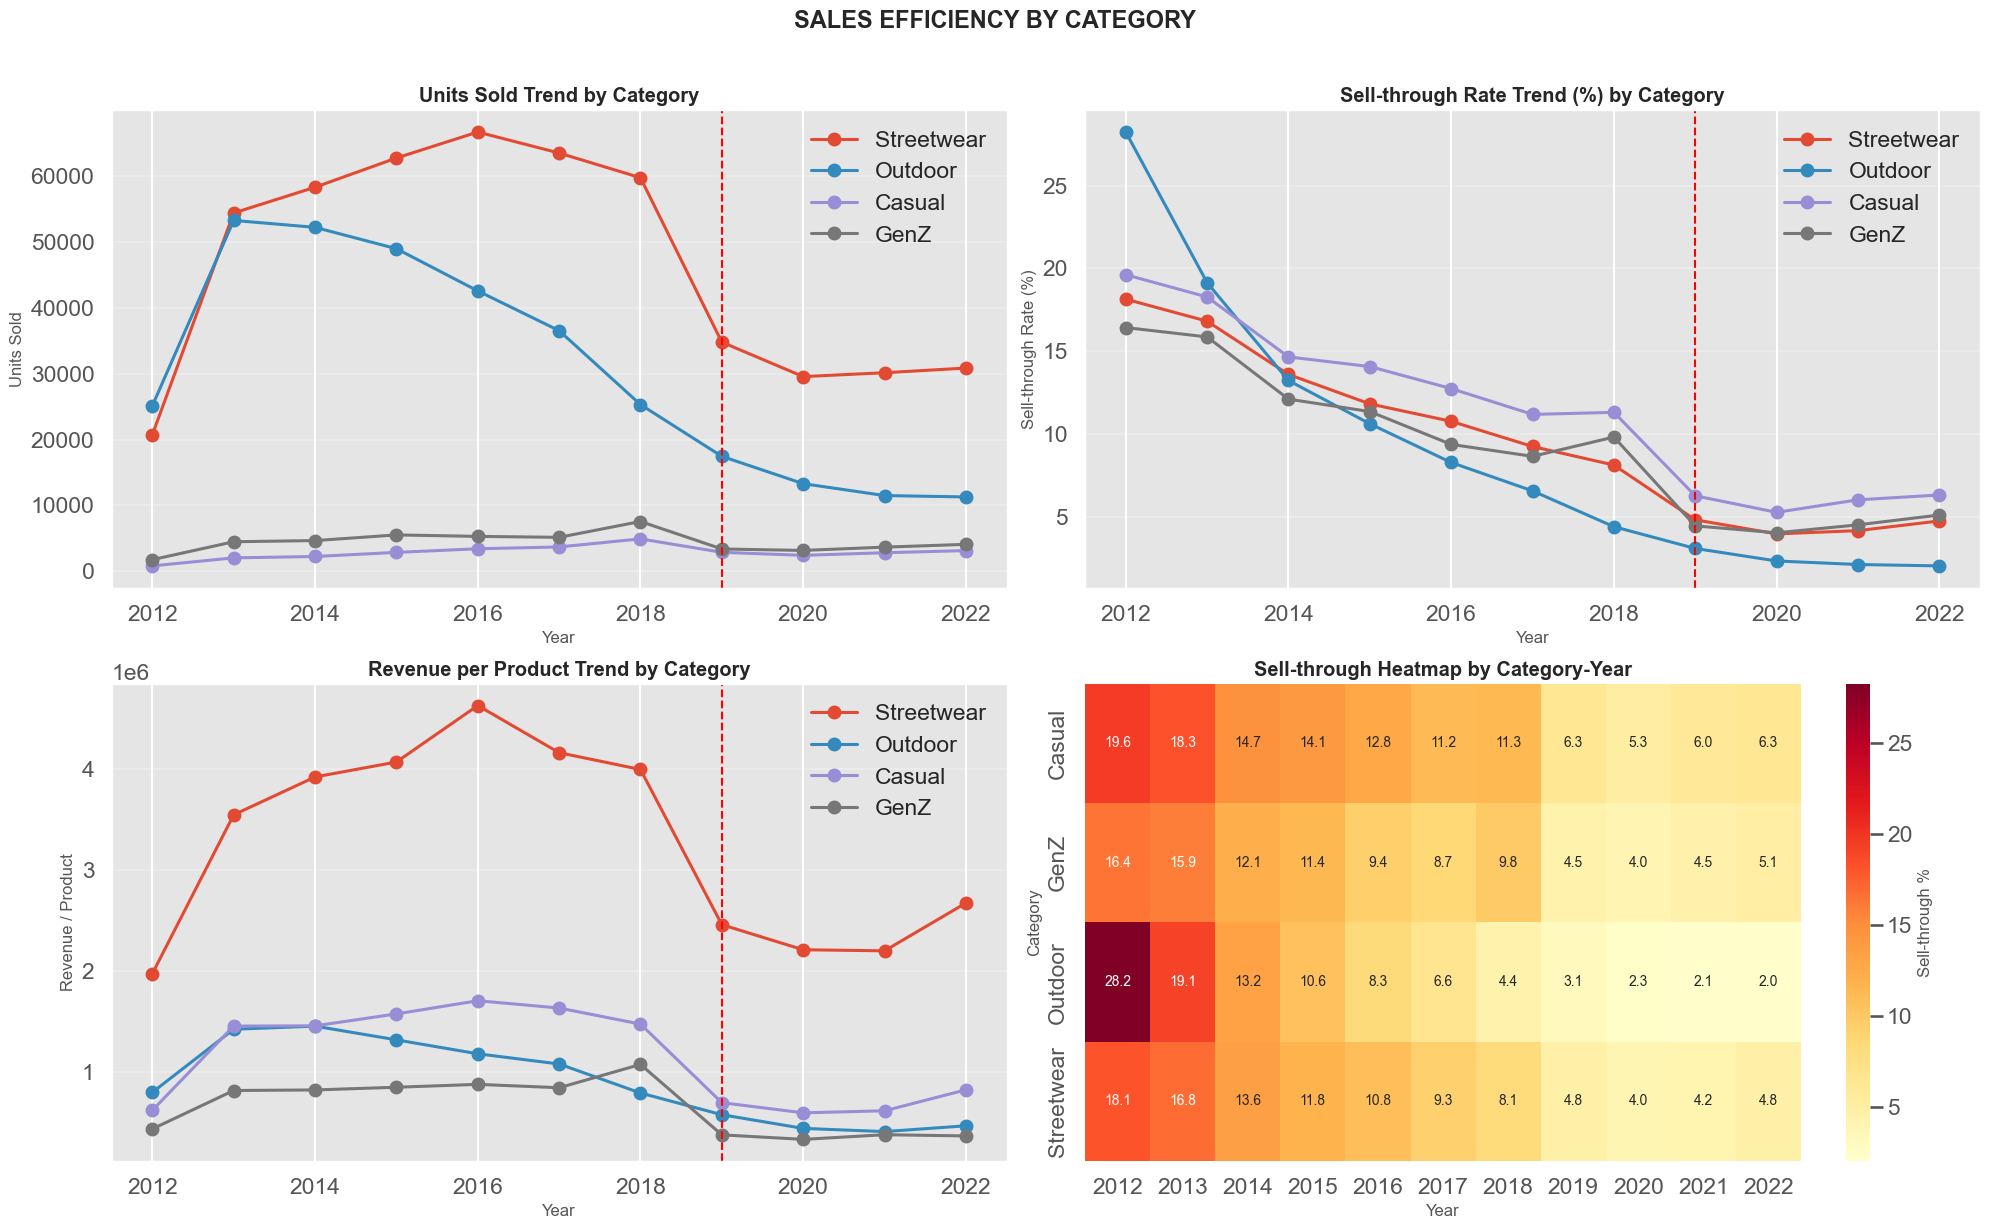

In [65]:
print('\n' + '=' * 100)
print('5.4.2 SALES EFFICIENCY BY CATEGORY: UNITS / SELL-THROUGH / REVENUE-PRODUCT')
print('=' * 100)

# ----------------------------------------------------------------------
# 1) Chuẩn bị dữ liệu inventory cho hiệu quả bán hàng
# ----------------------------------------------------------------------
inv = inventory.copy()

if 'year' not in inv.columns:
    if 'snapshot_date' in inv.columns:
        inv['snapshot_date'] = pd.to_datetime(inv['snapshot_date'], errors='coerce')
        inv['year'] = inv['snapshot_date'].dt.year
    else:
        raise ValueError('Không có cột year hoặc snapshot_date trong inventory để phân tích theo năm.')

inv['year'] = pd.to_numeric(inv['year'], errors='coerce')
inv = inv.dropna(subset=['year']).copy()
inv['year'] = inv['year'].astype(int)

category_col_inv = 'category' if 'category' in inv.columns else None
if category_col_inv is None:
    for c in ['product_category', 'cat', 'group']:
        if c in inv.columns:
            category_col_inv = c
            break

if category_col_inv is None:
    inv['category_fallback'] = 'All Products'
    category_col_inv = 'category_fallback'

inv[category_col_inv] = inv[category_col_inv].fillna('Unknown Category')

if 'units_sold' in inv.columns:
    inv['units_sold_num'] = pd.to_numeric(inv['units_sold'], errors='coerce').fillna(0)
else:
    inv['units_sold_num'] = 0

if 'stock_on_hand' in inv.columns:
    inv['stock_on_hand_num'] = pd.to_numeric(inv['stock_on_hand'], errors='coerce').fillna(0)
else:
    inv['stock_on_hand_num'] = np.nan

# Sell-through dùng cột có sẵn nếu có, nếu không fallback từ units_sold/(units_sold+stock_on_hand)
if 'sell_through_rate' in inv.columns:
    inv['sell_through_rate_num'] = pd.to_numeric(inv['sell_through_rate'], errors='coerce')
    # Chuẩn hóa về dạng 0-1 nếu dữ liệu đang ở %
    if inv['sell_through_rate_num'].dropna().max() > 1.5:
        inv['sell_through_rate_num'] = inv['sell_through_rate_num'] / 100.0
else:
    inv['sell_through_rate_num'] = np.nan

inv['sell_through_proxy'] = inv['units_sold_num'] / (inv['units_sold_num'] + inv['stock_on_hand_num'])
inv.loc[~np.isfinite(inv['sell_through_proxy']), 'sell_through_proxy'] = np.nan

inv['sell_through_final'] = inv['sell_through_rate_num']
inv.loc[inv['sell_through_final'].isna(), 'sell_through_final'] = inv.loc[inv['sell_through_final'].isna(), 'sell_through_proxy']

inv['efficiency_weight'] = inv['units_sold_num'] + inv['stock_on_hand_num'].fillna(0)
inv.loc[inv['efficiency_weight'] <= 0, 'efficiency_weight'] = inv.loc[inv['efficiency_weight'] <= 0, 'units_sold_num']
inv.loc[inv['efficiency_weight'] <= 0, 'efficiency_weight'] = 1

# ----------------------------------------------------------------------
# 2) Revenue / product theo category-năm
# ----------------------------------------------------------------------
if 'mix_base' in globals() and {'year', 'line_revenue'}.issubset(mix_base.columns):
    rev_base = mix_base.copy()
else:
    rev_items = order_items.copy()
    rev_orders = orders[['order_id', 'order_date']].dropna(subset=['order_id', 'order_date']).copy()
    rev_orders['year'] = rev_orders['order_date'].dt.year

    if 'quantity' in rev_items.columns:
        rev_qty = pd.to_numeric(rev_items['quantity'], errors='coerce').fillna(0)
    else:
        rev_qty = pd.Series(1, index=rev_items.index)

    if 'unit_price' in rev_items.columns:
        rev_price = pd.to_numeric(rev_items['unit_price'], errors='coerce').fillna(0)
        rev_items['line_revenue'] = rev_qty * rev_price if 'quantity' in rev_items.columns else rev_price
    elif 'price' in rev_items.columns:
        rev_price = pd.to_numeric(rev_items['price'], errors='coerce').fillna(0)
        rev_items['line_revenue'] = rev_qty * rev_price if 'quantity' in rev_items.columns else rev_price
    else:
        rev_items['line_revenue'] = np.nan

    rev_base = rev_items.merge(rev_orders[['order_id', 'year']], on='order_id', how='inner')

    if 'product_id' in rev_base.columns and 'product_id' in products.columns:
        prod_cols = ['product_id'] + [c for c in ['category'] if c in products.columns]
        rev_base = rev_base.merge(products[prod_cols].drop_duplicates('product_id'), on='product_id', how='left')

if 'category' not in rev_base.columns:
    rev_base['category'] = 'Unknown Category'
rev_base['category'] = rev_base['category'].fillna('Unknown Category')

annual_revenue_category = rev_base.groupby(['year', 'category'], as_index=False).agg(
    revenue=('line_revenue', 'sum'),
    sold_products=('product_id', 'nunique') if 'product_id' in rev_base.columns else ('order_id', 'nunique')
)
annual_revenue_category['revenue_per_product'] = annual_revenue_category['revenue'] / annual_revenue_category['sold_products'].replace(0, np.nan)

# ----------------------------------------------------------------------
# 3) Ghép KPI theo category-năm
# ----------------------------------------------------------------------
annual_sales_eff = inv.groupby(['year', category_col_inv], as_index=False).agg(
    units_sold=('units_sold_num', 'sum'),
    stock_on_hand=('stock_on_hand_num', 'sum'),
    avg_sell_through=('sell_through_final', lambda s: np.nan),
    weighted_st=('sell_through_final', lambda s: np.nan),
    total_weight=('efficiency_weight', 'sum')
)

# Tính weighted sell-through đúng cách sau groupby
weighted_st_rows = (
    inv.dropna(subset=['sell_through_final'])
      .groupby(['year', category_col_inv])
      .apply(lambda g: np.average(g['sell_through_final'], weights=g['efficiency_weight']) if g['efficiency_weight'].sum() > 0 else np.nan)
      .reset_index(name='sell_through_rate')
)

annual_sales_eff = annual_sales_eff.drop(columns=['avg_sell_through', 'weighted_st'])
annual_sales_eff = annual_sales_eff.merge(weighted_st_rows, on=['year', category_col_inv], how='left')
annual_sales_eff = annual_sales_eff.rename(columns={category_col_inv: 'category'})
annual_sales_eff['sell_through_rate_pct'] = annual_sales_eff['sell_through_rate'] * 100

annual_sales_eff = annual_sales_eff.merge(
    annual_revenue_category[['year', 'category', 'revenue', 'sold_products', 'revenue_per_product']],
    on=['year', 'category'], how='left'
)

# ----------------------------------------------------------------------
# 4) Bảng full-period theo yêu cầu
# ----------------------------------------------------------------------
units_pivot = annual_sales_eff.pivot(index='year', columns='category', values='units_sold').fillna(0)
st_pivot = annual_sales_eff.pivot(index='year', columns='category', values='sell_through_rate_pct').fillna(np.nan)
rpp_pivot = annual_sales_eff.pivot(index='year', columns='category', values='revenue_per_product').fillna(np.nan)

print('\n' + '-' * 100)
print('Bảng 1 - Units Sold by Category by Year (Full Period)')
print('-' * 100)
display(units_pivot.round(0).astype(int).reset_index())

print('\n' + '-' * 100)
print('Bảng 2 - Sell-through Rate (%) by Category by Year (Full Period)')
print('-' * 100)
display(st_pivot.round(2).reset_index())

print('\n' + '-' * 100)
print('Bảng 3 - Revenue per Product by Category by Year (Full Period)')
print('-' * 100)
display(rpp_pivot.round(2).reset_index())

# ----------------------------------------------------------------------
# 5) Vẽ biểu đồ
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('SALES EFFICIENCY BY CATEGORY', fontsize=17, fontweight='bold', y=1.02)

break_year = 2019
top_categories = annual_sales_eff.groupby('category')['revenue'].sum().sort_values(ascending=False).head(5).index.tolist()

# (1) Units sold trend theo top category
ax = axes[0, 0]
for cat in top_categories:
    s = annual_sales_eff[annual_sales_eff['category'] == cat].sort_values('year')
    ax.plot(s['year'], s['units_sold'], marker='o', linewidth=2.2, label=cat)
ax.axvline(break_year, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Units Sold Trend by Category', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Units Sold')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)

# (2) Sell-through trend theo top category
ax = axes[0, 1]
for cat in top_categories:
    s = annual_sales_eff[annual_sales_eff['category'] == cat].sort_values('year')
    ax.plot(s['year'], s['sell_through_rate_pct'], marker='o', linewidth=2.2, label=cat)
ax.axvline(break_year, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Sell-through Rate Trend (%) by Category', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Sell-through Rate (%)')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)

# (3) Revenue / product trend theo top category
ax = axes[1, 0]
for cat in top_categories:
    s = annual_sales_eff[annual_sales_eff['category'] == cat].sort_values('year')
    ax.plot(s['year'], s['revenue_per_product'], marker='o', linewidth=2.2, label=cat)
ax.axvline(break_year, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Revenue per Product Trend by Category', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Revenue / Product')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)

# (4) Heatmap sell-through để nhìn dấu hiệu bão hòa
ax = axes[1, 1]
st_heat = st_pivot.copy()
if st_heat.shape[1] > 8:
    st_heat = st_heat[st_heat.mean().sort_values(ascending=False).head(8).index]
sns.heatmap(st_heat.T, cmap='YlOrRd', annot=True, fmt='.1f', cbar_kws={'label': 'Sell-through %'}, ax=ax)
ax.set_title('Sell-through Heatmap by Category-Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Category')

plt.tight_layout()
plt.show()




5.4.3 INVENTORY HEALTH: DAYS OF SUPPLY / OVERSTOCK / SOLD VS RECEIVED

----------------------------------------------------------------------------------------------------
Bảng 1 - Inventory Health by Year (Overall)
----------------------------------------------------------------------------------------------------


,year,units_sold,units_received,stock_on_hand,avg_days_of_supply,overstock_rate_pct,sold_received_ratio,inventory_pressure_index,avg_sell_through_proxy_pct
0,2012,48424,56967,169617,161.11,56.91,0.85,3.50,23.68
1,2013,114179,134205,526903,232.44,66.09,0.85,4.61,20.65
2,2014,117427,138286,759428,458.89,74.03,0.85,6.47,17.68
3,2015,120105,141169,940437,699.50,77.91,0.85,7.83,16.08
4,2016,117966,138689,1097919,721.29,77.85,0.85,9.31,15.38
5,2017,108870,127908,1225517,831.45,78.75,0.85,11.26,14.70
6,2018,97521,114201,1330975,899.60,79.28,0.85,13.65,13.77
7,2019,58485,67780,1346798,1257.43,81.77,0.86,23.03,11.85
8,2020,48431,55728,1386188,1409.53,82.04,0.87,28.62,11.32
9,2021,48107,55413,1341086,1385.39,76.40,0.87,27.88,13.43



----------------------------------------------------------------------------------------------------
Bảng 2 - Days of Supply by Category-Year
----------------------------------------------------------------------------------------------------


category,year,Casual,GenZ,Outdoor,Streetwear
0,2012,158.66,267.56,118.38,184.05
1,2013,170.61,269.17,224.29,239.03
2,2014,271.54,328.84,533.30,430.92
3,2015,311.46,372.76,911.06,612.36
4,2016,319.17,629.71,904.03,628.17
5,2017,299.57,651.45,775.29,942.78
6,2018,431.43,654.08,1127.58,841.94
7,2019,565.29,810.18,1683.49,1176.13
8,2020,689.85,856.27,1860.29,1353.49
9,2021,551.22,909.57,1804.08,1391.26



----------------------------------------------------------------------------------------------------
Bảng 3 - Overstock Rate (%) by Category-Year
----------------------------------------------------------------------------------------------------


category,year,Casual,GenZ,Outdoor,Streetwear
0,2012,62.38,78.50,46.44,62.44
1,2013,70.35,66.67,67.08,65.05
2,2014,81.46,65.83,79.76,70.21
3,2015,79.65,67.57,82.51,75.66
4,2016,82.77,68.08,81.99,75.65
5,2017,76.89,75.84,83.37,75.86
6,2018,68.65,69.44,85.35,78.02
7,2019,70.54,73.30,83.95,83.78
8,2020,75.96,74.64,86.71,81.57
9,2021,67.20,72.20,83.36,74.89



----------------------------------------------------------------------------------------------------
Bảng 4 - Units Sold / Units Received Ratio by Category-Year
----------------------------------------------------------------------------------------------------


category,year,Casual,GenZ,Outdoor,Streetwear
0,2012,0.870,0.857,0.847,0.853
1,2013,0.869,0.857,0.848,0.853
2,2014,0.869,0.855,0.848,0.849
3,2015,0.864,0.864,0.849,0.850
4,2016,0.860,0.862,0.853,0.848
5,2017,0.855,0.856,0.853,0.849
6,2018,0.866,0.856,0.855,0.852
7,2019,0.889,0.878,0.863,0.859
8,2020,0.894,0.887,0.870,0.865
9,2021,0.891,0.878,0.875,0.862


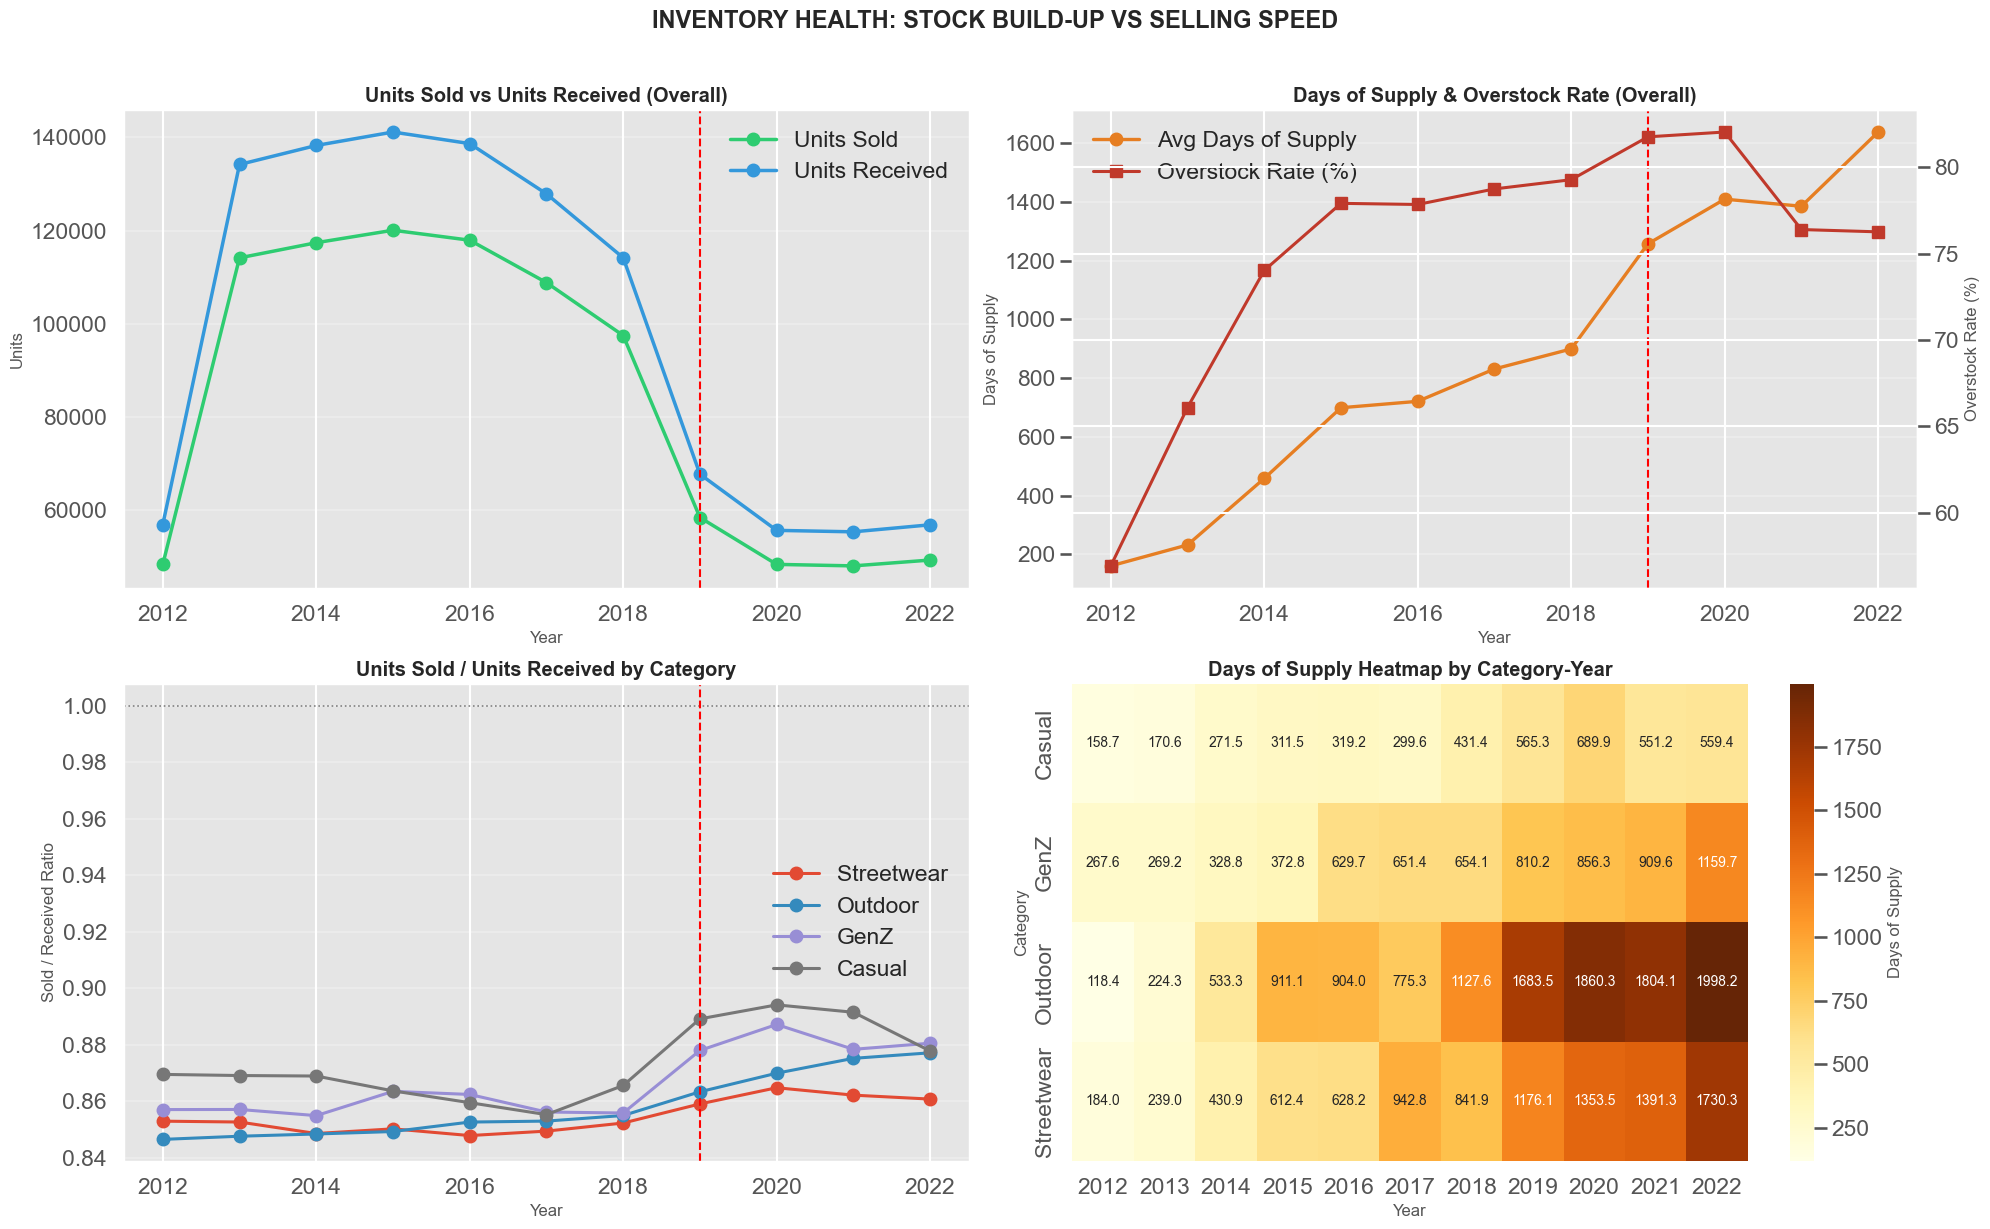

In [66]:
print('\n' + '=' * 100)
print('5.4.3 INVENTORY HEALTH: DAYS OF SUPPLY / OVERSTOCK / SOLD VS RECEIVED')
print('=' * 100)

# ----------------------------------------------------------------------
# 1) Chuẩn bị dữ liệu inventory
# ----------------------------------------------------------------------
inv_health = inventory.copy()

if 'year' not in inv_health.columns:
    if 'snapshot_date' in inv_health.columns:
        inv_health['snapshot_date'] = pd.to_datetime(inv_health['snapshot_date'], errors='coerce')
        inv_health['year'] = inv_health['snapshot_date'].dt.year
    else:
        raise ValueError('Inventory không có cột year hoặc snapshot_date để phân tích theo năm.')

inv_health['year'] = pd.to_numeric(inv_health['year'], errors='coerce')
inv_health = inv_health.dropna(subset=['year']).copy()
inv_health['year'] = inv_health['year'].astype(int)

cat_col = 'category' if 'category' in inv_health.columns else None
if cat_col is None:
    for c in ['product_category', 'cat', 'group']:
        if c in inv_health.columns:
            cat_col = c
            break
if cat_col is None:
    inv_health['category_fallback'] = 'All Products'
    cat_col = 'category_fallback'

inv_health[cat_col] = inv_health[cat_col].fillna('Unknown Category')

for col in ['days_of_supply', 'units_sold', 'units_received', 'stock_on_hand']:
    if col in inv_health.columns:
        inv_health[col + '_num'] = pd.to_numeric(inv_health[col], errors='coerce')
    else:
        inv_health[col + '_num'] = np.nan

# overstock flag: chuẩn hóa về nhị phân
if 'overstock_flag' in inv_health.columns:
    over_col = inv_health['overstock_flag']
    if over_col.dtype == bool:
        inv_health['overstock_bin'] = over_col.astype(int)
    else:
        inv_health['overstock_bin'] = (
            over_col.astype(str).str.strip().str.lower().isin(['1', 'true', 'yes', 'y'])
        ).astype(int)
else:
    inv_health['overstock_bin'] = np.nan

# Sell-through proxy để đánh giá tồn đọng
inv_health['sell_through_proxy'] = inv_health['units_sold_num'] / (inv_health['units_sold_num'] + inv_health['stock_on_hand_num'])
inv_health.loc[~np.isfinite(inv_health['sell_through_proxy']), 'sell_through_proxy'] = np.nan

# ----------------------------------------------------------------------
# 2) Tổng hợp theo năm (overall) và theo category-năm
# ----------------------------------------------------------------------
inventory_yearly = inv_health.groupby('year', as_index=False).agg(
    units_sold=('units_sold_num', 'sum'),
    units_received=('units_received_num', 'sum'),
    stock_on_hand=('stock_on_hand_num', 'sum'),
    avg_days_of_supply=('days_of_supply_num', 'mean'),
    median_days_of_supply=('days_of_supply_num', 'median'),
    overstock_rate=('overstock_bin', 'mean'),
    avg_sell_through_proxy=('sell_through_proxy', 'mean')
).sort_values('year')

inventory_yearly['sold_received_ratio'] = inventory_yearly['units_sold'] / inventory_yearly['units_received'].replace(0, np.nan)
inventory_yearly['inventory_pressure_index'] = inventory_yearly['stock_on_hand'] / inventory_yearly['units_sold'].replace(0, np.nan)
inventory_yearly['overstock_rate_pct'] = inventory_yearly['overstock_rate'] * 100
inventory_yearly['avg_sell_through_proxy_pct'] = inventory_yearly['avg_sell_through_proxy'] * 100

inventory_cat_year = inv_health.groupby(['year', cat_col], as_index=False).agg(
    units_sold=('units_sold_num', 'sum'),
    units_received=('units_received_num', 'sum'),
    avg_days_of_supply=('days_of_supply_num', 'mean'),
    overstock_rate=('overstock_bin', 'mean'),
    avg_sell_through_proxy=('sell_through_proxy', 'mean')
).rename(columns={cat_col: 'category'})

inventory_cat_year['sold_received_ratio'] = inventory_cat_year['units_sold'] / inventory_cat_year['units_received'].replace(0, np.nan)
inventory_cat_year['overstock_rate_pct'] = inventory_cat_year['overstock_rate'] * 100
inventory_cat_year['avg_sell_through_proxy_pct'] = inventory_cat_year['avg_sell_through_proxy'] * 100

# ----------------------------------------------------------------------
# 3) Bảng full-period
# ----------------------------------------------------------------------
dos_pivot = inventory_cat_year.pivot(index='year', columns='category', values='avg_days_of_supply')
ovs_pivot = inventory_cat_year.pivot(index='year', columns='category', values='overstock_rate_pct')
sr_ratio_pivot = inventory_cat_year.pivot(index='year', columns='category', values='sold_received_ratio')

print('\n' + '-' * 100)
print('Bảng 1 - Inventory Health by Year (Overall)')
print('-' * 100)
display(inventory_yearly[['year', 'units_sold', 'units_received', 'stock_on_hand', 'avg_days_of_supply', 'overstock_rate_pct', 'sold_received_ratio', 'inventory_pressure_index', 'avg_sell_through_proxy_pct']].round(2))

print('\n' + '-' * 100)
print('Bảng 2 - Days of Supply by Category-Year')
print('-' * 100)
display(dos_pivot.round(2).reset_index())

print('\n' + '-' * 100)
print('Bảng 3 - Overstock Rate (%) by Category-Year')
print('-' * 100)
display(ovs_pivot.round(2).reset_index())

print('\n' + '-' * 100)
print('Bảng 4 - Units Sold / Units Received Ratio by Category-Year')
print('-' * 100)
display(sr_ratio_pivot.round(3).reset_index())

# ----------------------------------------------------------------------
# 4) Vẽ biểu đồ Inventory Health
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('INVENTORY HEALTH: STOCK BUILD-UP VS SELLING SPEED', fontsize=17, fontweight='bold', y=1.02)

break_year = 2019

# (1) Units sold vs units received (overall)
ax = axes[0, 0]
ax.plot(inventory_yearly['year'], inventory_yearly['units_sold'], marker='o', linewidth=2.5, label='Units Sold', color='#2ecc71')
ax.plot(inventory_yearly['year'], inventory_yearly['units_received'], marker='o', linewidth=2.5, label='Units Received', color='#3498db')
ax.axvline(break_year, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Units Sold vs Units Received (Overall)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Units')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)

# (2) Days of supply & overstock (overall)
ax = axes[0, 1]
ax.plot(inventory_yearly['year'], inventory_yearly['avg_days_of_supply'], marker='o', linewidth=2.4, color='#e67e22', label='Avg Days of Supply')
ax2 = ax.twinx()
ax2.plot(inventory_yearly['year'], inventory_yearly['overstock_rate_pct'], marker='s', linewidth=2.2, color='#c0392b', label='Overstock Rate (%)')
ax.axvline(break_year, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Days of Supply & Overstock Rate (Overall)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Days of Supply')
ax2.set_ylabel('Overstock Rate (%)')
ax.grid(axis='y', alpha=0.25)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=False)

# (3) Sold/Received ratio by top categories
ax = axes[1, 0]
top_cat_by_units = inventory_cat_year.groupby('category')['units_sold'].sum().sort_values(ascending=False).head(5).index.tolist()
for cat in top_cat_by_units:
    s = inventory_cat_year[inventory_cat_year['category'] == cat].sort_values('year')
    ax.plot(s['year'], s['sold_received_ratio'], marker='o', linewidth=2.2, label=cat)
ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.2)
ax.axvline(break_year, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Units Sold / Units Received by Category', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Sold / Received Ratio')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)

# (4) Days of supply heatmap theo category-year
ax = axes[1, 1]
dos_heat = dos_pivot.copy()
if dos_heat.shape[1] > 8:
    dos_heat = dos_heat[dos_heat.mean().sort_values(ascending=False).head(8).index]
sns.heatmap(dos_heat.T, cmap='YlOrBr', annot=True, fmt='.1f', cbar_kws={'label': 'Days of Supply'}, ax=ax)
ax.set_title('Days of Supply Heatmap by Category-Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Category')

plt.tight_layout()
plt.show()



Từ các phân tích về doanh thu, sản lượng, tồn kho và cơ cấu danh mục, có thể thấy cú sụt giảm doanh thu sau năm 2019 không chỉ đến từ phía khách hàng hay hiệu quả chuyển đổi, mà còn bắt nguồn từ một vấn đề mang tính cấu trúc: sự mất cân bằng trong danh mục sản phẩm, kéo theo áp lực tồn kho ngày càng gia tăng.

Xét về cơ cấu doanh thu, doanh nghiệp phụ thuộc gần như tuyệt đối vào Streetwear. Ngay từ năm 2012, danh mục này đã chiếm 75.26% doanh thu, và tiếp tục tăng lên 83.83% vào năm 2022. Trong khi đó, Outdoor – từng là trụ cột thứ hai với 21.87% doanh thu năm 2012 – suy giảm liên tục và chỉ còn 9.03% vào năm 2022. Sự dịch chuyển này cho thấy doanh nghiệp đã đánh mất một chân trụ quan trọng nhưng không xây dựng được danh mục thay thế tương xứng. Các nhóm như Casual và GenZ dù có tăng trưởng nhưng tổng đóng góp vẫn dưới 10%, không đủ để bù đắp khoảng trống mà Outdoor để lại.

Xu hướng này càng rõ nét khi nhìn vào sản lượng tiêu thụ. Outdoor giảm mạnh từ 25,125 units (2012) xuống còn 11,282 units (2022) (~ -55%), trong khi Streetwear – danh mục chủ lực – cũng bắt đầu suy yếu sau năm 2018, với sản lượng giảm từ khoảng 59,750 xuống còn 30,854 units. Điều này cho thấy vấn đề không chỉ nằm ở cơ cấu danh mục, mà còn phản ánh sự suy giảm nhu cầu thực tế trên các dòng sản phẩm cốt lõi.

Một tín hiệu cảnh báo rõ ràng hơn nằm ở sell-through rate. Tỷ lệ bán được của tất cả các danh mục đều giảm mạnh theo thời gian:

- Streetwear: từ 18.15% (2012) xuống 4.76% (2022)
- Outdoor: từ 28.24% xuống khoảng 2%

Điều này cho thấy doanh nghiệp không gặp vấn đề thiếu nguồn cung, mà ngược lại, đang đối mặt với tình trạng cầu không theo kịp cung — hàng hóa ngày càng khó tiêu thụ.

Áp lực này được phản ánh trực tiếp qua các chỉ số tồn kho. Days of Supply tăng từ khoảng 161 ngày (2012) lên tới 1,638 ngày (2022), tức gấp hơn 10 lần. Riêng Streetwear tăng từ 184 ngày lên 1,730 ngày, cho thấy lượng hàng tồn tích tụ ngày càng lớn. Đồng thời, Inventory Pressure Index tăng mạnh từ 3.5 lên 25.9, trong khi overstock rate duy trì ở mức rất cao (75%–85%) trong nhiều năm liên tiếp.

Những con số này chỉ ra một thực tế rõ ràng: nguồn vốn của doanh nghiệp đang bị “chôn” trong tồn kho, làm giảm khả năng xoay vòng và hạn chế đầu tư vào các sản phẩm mới – yếu tố then chốt để kích thích nhu cầu trở lại.

Việc phụ thuộc quá mức vào một ngành hàng chủ lực trong khi các danh mục khác suy yếu đã khiến doanh nghiệp mất khả năng thích ứng khi nhu cầu thị trường thay đổi. Khi Streetwear bắt đầu bão hòa, doanh nghiệp không còn trụ cột tăng trưởng thay thế, dẫn đến tồn kho gia tăng, dòng tiền bị tắc nghẽn và hiệu quả kinh doanh suy giảm kéo dài.

#### 5.4 Kết luận

Tổng hợp các phân tích về khách hàng, hành vi mua, hiệu quả chuyển đổi và danh mục sản phẩm cho thấy sự sụt giảm doanh thu từ năm 2019 không phải là kết quả của một biến động đơn lẻ, mà là hệ quả của ba vòng xoáy tiêu cực xảy ra đồng thời và cộng hưởng lẫn nhau.

Trước hết, ở tầng đầu của phễu, doanh nghiệp gặp vấn đề nghiêm trọng trong việc chuyển đổi nhu cầu thành doanh thu. Mặc dù lượng người quan tâm vẫn tăng đều qua các năm, nhưng tỷ lệ chuyển đổi từ người đăng ký sang khách hàng thực sự giảm mạnh, từ mức hai chữ số xuống gần như không đáng kể vào giai đoạn sau. Điều này cho thấy doanh nghiệp vẫn thu hút được sự chú ý của thị trường, nhưng không còn đủ sức thuyết phục người dùng thực hiện hành vi mua hàng, phản ánh vấn đề ở product-market fit, trải nghiệm mua sắm hoặc định vị giá trị.

Thứ hai, ở tầng khách hàng, dữ liệu cho thấy một sự suy giảm rõ rệt trong khả năng giữ chân. Tỷ lệ khách quay lại giảm mạnh, đặc biệt cú sốc năm 2019 khi hơn một nửa khách hàng năm trước không tiếp tục mua hàng. Trong khi đó, các chỉ số về chất lượng dịch vụ như thời gian giao hàng, tỷ lệ hoàn trả hay đánh giá khách hàng gần như không thay đổi đáng kể. Điều này cho thấy nguyên nhân không nằm ở trải nghiệm vận hành, mà ở chỗ khách hàng không còn đủ động lực để quay lại, nhiều khả năng do sản phẩm không còn phù hợp hoặc thiếu sự mới mẻ.

Cuối cùng, ở tầng sản phẩm, doanh nghiệp bộc lộ một điểm yếu mang tính cấu trúc. Việc phụ thuộc quá lớn vào một danh mục chủ lực trong khi các danh mục khác suy giảm đã khiến hệ thống mất đi khả năng chống chịu khi nhu cầu thị trường thay đổi. Khi danh mục chính bắt đầu bão hòa, doanh nghiệp không có trụ cột thay thế, dẫn đến tồn kho gia tăng, vòng quay vốn chậm lại và hạn chế khả năng đổi mới sản phẩm.

Ba yếu tố này không tồn tại độc lập mà tạo thành một vòng lặp tiêu cực: sản phẩm kém hấp dẫn làm giảm chuyển đổi, chuyển đổi thấp khiến khách hàng không quay lại, và việc mất khách tiếp tục làm suy yếu hiệu quả của danh mục sản phẩm. Kết quả là doanh nghiệp rơi vào trạng thái suy giảm kéo dài và không thể phục hồi sau cú sụt giảm năm 2019.

Tóm lại, vấn đề cốt lõi không nằm ở việc “bán có hiệu quả hay không”, mà nằm ở chỗ doanh nghiệp không còn bán được đủ nhiều, do mất cân bằng đồng thời ở cả ba trụ cột: thu hút – chuyển đổi – duy trì khách hàng, gắn chặt với chiến lược sản phẩm chưa thích ứng với sự thay đổi của thị trường.

### 6. Vì sao không có sự phục hồi?

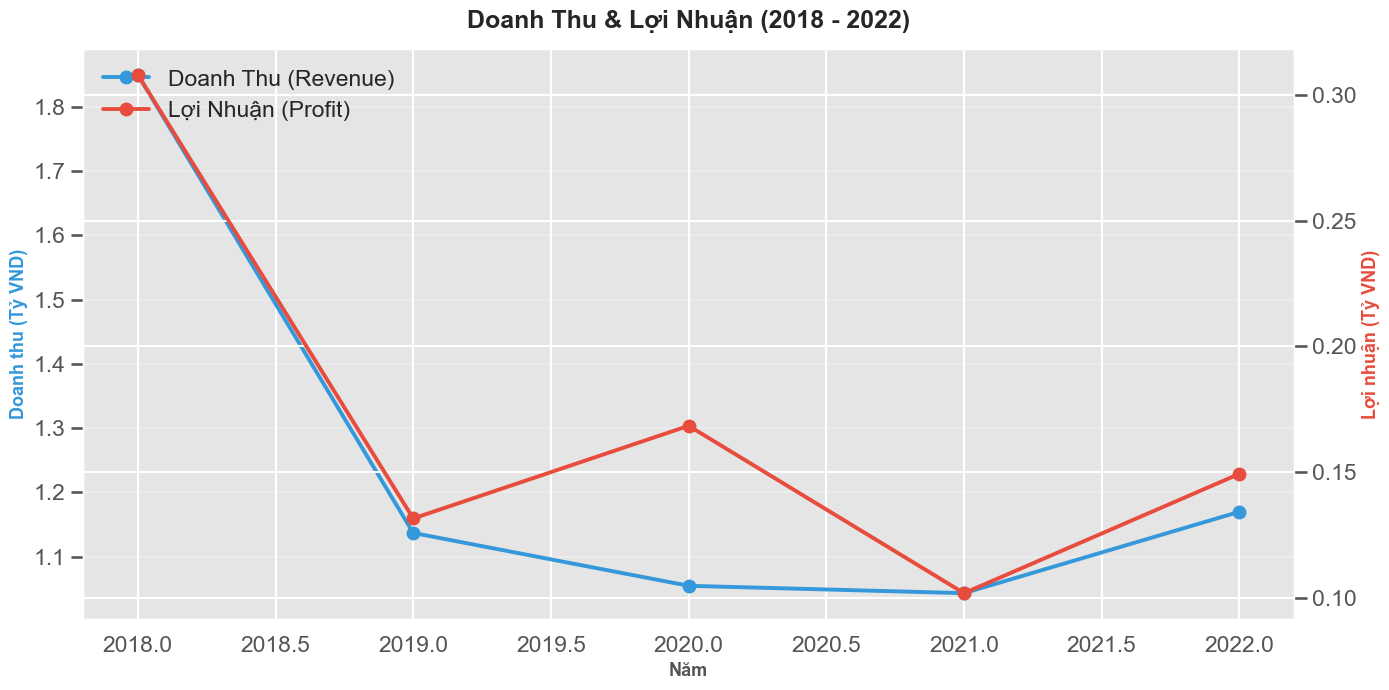

In [67]:
# Biểu đồ doanh thu & lợi nhuận rút gọn giai đoạn 2018 - 2022
recent_summary = growth_summary[growth_summary['Year'].between(2018, 2022)].copy()

fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

ax1.plot(
    recent_summary['Year'],
    recent_summary['Revenue'] / 1e9,
    marker='o',
    linewidth=2.8,
    color='#3498db',
    label='Doanh Thu (Revenue)'
)
ax2.plot(
    recent_summary['Year'],
    recent_summary['Profit'] / 1e9,
    marker='o',
    linewidth=2.8,
    color='#e74c3c',
    label='Lợi Nhuận (Profit)'
)

ax1.set_title('Doanh Thu & Lợi Nhuận (2018 - 2022)', fontsize=18, fontweight='bold', pad=15)
ax1.set_xlabel('Năm', fontsize=13, fontweight='bold')
ax1.set_ylabel('Doanh thu (Tỷ VND)', fontsize=13, fontweight='bold', color='#3498db')
ax2.set_ylabel('Lợi nhuận (Tỷ VND)', fontsize=13, fontweight='bold', color='#e74c3c')
ax1.grid(axis='y', alpha=0.25)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

Sau khi nhìn lại bức tranh doanh thu, có thể thấy rằng sau cú sụt giảm mạnh vào năm 2019, doanh nghiệp không hề có dấu hiệu phục hồi mà bước vào trạng thái tăng trưởng trì trệ kéo dài. Doanh thu các năm sau đó chỉ dao động quanh mức thấp của năm 2019, không thể quay lại quỹ đạo trước đây. Điều này cho thấy vấn đề không nằm ở một cú sốc ngắn hạn, mà là sự tồn tại của các nguyên nhân mang tính cấu trúc.